# Análisis de Datos - Machine Learning

Este notebook contiene el análisis completo de datos con modelos de machine learning.

## Pasos del análisis:
1. Carga de datos
2. Conversión a JSON y conteo por cuenta
3. Análisis Exploratorio de Datos (EDA)
4. Filtrado de datos (Tarifa NBO y Rentabilizacion)
5. Preparación de datos
6. Entrenamiento de modelos (Regresión Logística, Random Forest, XGBoost)
7. Validación cruzada
8. Grid Search para árboles de decisión
9. Comparación y selección del mejor modelo


## Paso 1: Importación de librerías


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import warnings
import json
import pickle
from datetime import datetime
import os

warnings.filterwarnings('ignore')

print("✓ Librerías importadas correctamente")

# Crear carpeta para graficas de correcciones (23 Febrero)
graficas_dir = os.path.join('resultados', 'graficas23Febrero')
os.makedirs(graficas_dir, exist_ok=True)
print(f"\u2713 Carpeta de graficas creada: {graficas_dir}")

✓ Librerías importadas correctamente
✓ Carpeta de graficas creada: resultados/graficas23Febrero


## Paso 2: Carga de datos


In [2]:
archivo = "Total_Mes_Act_Datos completos CORREGIDO.csv"
output_dir = 'resultados'
os.makedirs(output_dir, exist_ok=True)

print("Cargando datos...")
try:
    df = pd.read_csv(
        archivo, 
        low_memory=False,
        encoding='utf-8',
        on_bad_lines='skip',
        sep=';',
        quotechar='"'
    )
    print(f"✓ Datos cargados: {df.shape[0]} filas, {df.shape[1]} columnas")
except Exception as e:
    print(f"Error: {e}")
    print("Intentando con encoding alternativo...")
    df = pd.read_csv(
        archivo,
        low_memory=False,
        encoding='latin-1',
        on_bad_lines='skip',
        sep=';',
        quotechar='"'
    )
    print(f"✓ Datos cargados: {df.shape[0]} filas, {df.shape[1]} columnas")

df.head()

Cargando datos...


✓ Datos cargados: 1048575 filas, 36 columnas


,Msh Divisional,Msh Aliado,Msh Canal,Total Marcaciones,MESES_ANTIGUEDAD,MESES_ANTIGUEDAD_INSTALACION,MOVIMIENTO_RENTA,Msh Fecha,Msh Hora,Msh Proceso,...,MSH_TIPO_CLIENTE,MSH_TIPO_SERVICIO,MSH_USUARIO,MSH_ZONA,OPERA,PROCESOS 2,Rentabilizo,SIN TARIFA,TARIFA,TARIFA_NBO
0,REGION ORIENTE,Cav Acacias,CAV,1,11,0,IGUAL,5/09/2025,103103,INFORMACION GENERAL,...,2.0,RE,C38515697,META,R5-OPERA7,INFORMACION GENERAL,NaN,0,BP11,NaN
1,REGION NOROCCIDENTE,COS,SWAT,1,66,3,IGUAL,10/10/2025,111532,NOVEDADES TECNICAS,...,1.0,RE,C46199337,MEDELLIN NORTE,R2-OPERA10,NOVEDADES TECNICAS,NaN,0,QNN2,QNN2
2,REGION NOROCCIDENTE,NaN,SWAT,1,64,0,IGUAL,4/08/2025,145052,NOVEDAD ADMINISTRATIVA,...,1.0,RE,C46334029,MEDELLIN NORTE,R2-OPERA10,NOVEDAD ADMINISTRATIVA,NaN,0,QNN2,QNN2
3,REGION NOROCCIDENTE,ALMACONTACT,SWAT,1,65,2,IGUAL,16/09/2025,92400,INFORMACION GENERAL,...,1.0,RE,C46103531,MEDELLIN NORTE,R2-OPERA10,INFORMACION GENERAL,NaN,0,QNN2,QNN2
4,REGION NOROCCIDENTE,ATENTO,SWAT,1,58,0,IGUAL,5/10/2025,110248,INFORMACION GENERAL,...,2.0,RE,C45080846,CALDAS,R2-OPERA5,INFORMACION GENERAL,NaN,0,SRF1,SRF1


## Paso 3: Conversión a JSON y Conteo por Cuenta


In [3]:
print("Convirtiendo datos a JSON (muestra de 100,000 registros)...")
max_rows_json = min(100000, len(df))
df_muestra = df.head(max_rows_json)

ruta_json = os.path.join(output_dir, 'datos_completos.json')
df_muestra.to_json(
    ruta_json,
    orient='records',
    date_format='iso',
    indent=2,
    force_ascii=False
)
print(f"✓ Archivo JSON guardado en '{ruta_json}'")
print(f"Total de registros convertidos: {len(df_muestra)}")


Convirtiendo datos a JSON (muestra de 100,000 registros)...


✓ Archivo JSON guardado en 'resultados/datos_completos.json'
Total de registros convertidos: 100000


In [4]:
columna_cuenta = None

for col in df.columns:
    if 'cuenta' in col.lower():
        columna_cuenta = col
        break

if columna_cuenta is None:
    posibles = [col for col in df.columns if 'cuent' in col.lower() or 'account' in col.lower()]
    if posibles:
        columna_cuenta = posibles[0]

if columna_cuenta:
    print(f"Columna seleccionada: {columna_cuenta}")
    conteo = df[columna_cuenta].value_counts().reset_index()
    conteo.columns = ['Cuenta', 'Frecuencia']
    conteo = conteo.sort_values('Frecuencia', ascending=False)
    
    print(f"\nTotal de cuentas únicas: {len(conteo)}")
    print(f"\nTop 10 cuentas más frecuentes:")
    display(conteo.head(10))
    
    archivo_csv = os.path.join(output_dir, 'conteo_por_cuenta.csv')
    conteo.to_csv(archivo_csv, index=False, encoding='utf-8')
    print(f"\n✓ Conteo guardado en '{archivo_csv}'")
else:
    print("No se encontró columna 'cuenta'")


No se encontró columna 'cuenta'


## Paso 4: Análisis Exploratorio de Datos (EDA)


In [5]:
print("Información del dataset:")
print(f"Dimensiones: {df.shape}")
print(f"\nColumnas: {len(df.columns)}")
print(f"\nTipos de datos:")
print(df.dtypes.value_counts())

print(f"\nValores faltantes:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Valores_Faltantes': missing,
    'Porcentaje': missing_pct
})
missing_df = missing_df[missing_df['Valores_Faltantes'] > 0].sort_values('Porcentaje', ascending=False)

if len(missing_df) > 0:
    display(missing_df.head(20))
else:
    print("No hay valores faltantes")

print("\n" + "=" * 80)
print("RESUMEN DE HALLAZGOS EDA Y DECISIONES")
print("=" * 80)
print("""
Hallazgos clave del analisis exploratorio:
1. Identificadores detectados: Msh Cuenta, MSH_CEDULA, MSH_LOGIN_ID
   -> NO deben usarse como features (sin poder predictivo real).
2. 'SIN TARIFA' codifica directamente si existe TARIFA_NBO (componente del target)
   -> Fuga de datos directa. Eliminacion obligatoria.
3. 'MSH_TIPO_CLIENTE' mostro 93.47% de importancia en modelos previos
   -> Sospecha de proxy del target. Requiere analisis de ablacion.
4. 'MOVIMIENTO_RENTA' podria contener informacion post-resultado
   -> Posible fuga temporal. Incluir en ablacion.
5. Solo se usa split aleatorio 80/20 sin validacion temporal
   -> Se implementara validacion temporal con 'Msh Fecha (copia)'.

Decisiones tomadas:
- ELIMINAR: identificadores, SIN TARIFA, Msh Hora (copia), fechas
- ANALIZAR POR ABLACION: MSH_TIPO_CLIENTE, MOVIMIENTO_RENTA
- IMPLEMENTAR: validacion temporal ademas de aleatoria
""")

Información del dataset:
Dimensiones: (1048575, 36)

Columnas: 36

Tipos de datos:
object     29
int64       5
float64     2
Name: count, dtype: int64

Valores faltantes:


,Valores_Faltantes,Porcentaje
Rentabilizo,827229,78.890780
MSH_JEFE,547882,52.250149
MSH_LOGIN_ID,395206,37.689817
MSH_GRUPO,392439,37.425935
MSH_OPERACION,384821,36.699425
MSH_ESTADO,384821,36.699425
OPERA,318265,30.352145
Msh Aliado,246255,23.484729
MSH_PROCESO_SRV,115943,11.057197
PROCESOS 2,114711,10.939704



RESUMEN DE HALLAZGOS EDA Y DECISIONES

Hallazgos clave del analisis exploratorio:
1. Identificadores detectados: Msh Cuenta, MSH_CEDULA, MSH_LOGIN_ID
   -> NO deben usarse como features (sin poder predictivo real).
2. 'SIN TARIFA' codifica directamente si existe TARIFA_NBO (componente del target)
   -> Fuga de datos directa. Eliminacion obligatoria.
3. 'MSH_TIPO_CLIENTE' mostro 93.47% de importancia en modelos previos
   -> Sospecha de proxy del target. Requiere analisis de ablacion.
4. 'MOVIMIENTO_RENTA' podria contener informacion post-resultado
   -> Posible fuga temporal. Incluir en ablacion.
5. Solo se usa split aleatorio 80/20 sin validacion temporal
   -> Se implementara validacion temporal con 'Msh Fecha (copia)'.

Decisiones tomadas:
- ELIMINAR: identificadores, SIN TARIFA, Msh Hora (copia), fechas
- ANALIZAR POR ABLACION: MSH_TIPO_CLIENTE, MOVIMIENTO_RENTA
- IMPLEMENTAR: validacion temporal ademas de aleatoria



## Paso 4.1: EDA con Decisiones Concretas

Analisis detallado de cada variable con decision justificada sobre su inclusion o exclusion en el modelo. Se identifican variables con riesgo de fuga de datos (data leakage), identificadores sin poder predictivo, y variables sospechosas que requieren analisis de ablacion.

PASO 4.1: EDA CON DECISIONES CONCRETAS


Variable objetivo construida: 201,314 positivos (19.2%), 847,261 negativos (80.8%)

Clasificacion de 36 columnas:
  Identificadores (eliminar):          ['MSH_LOGIN_ID']
  Fuga directa (eliminar):             ['SIN TARIFA']
  Target (no usar como feature):       ['TARIFA_NBO', 'Rentabilizo']
  Fecha (reservar para val. temporal): []
  Duplicadas (eliminar):               []
  Sospechosas (ablacion):              ['MSH_TIPO_CLIENTE', 'MOVIMIENTO_RENTA']
  Variables validas:                   30 columnas



✓ Grafica guardada: fuga_sin_tarifa_vs_target.png


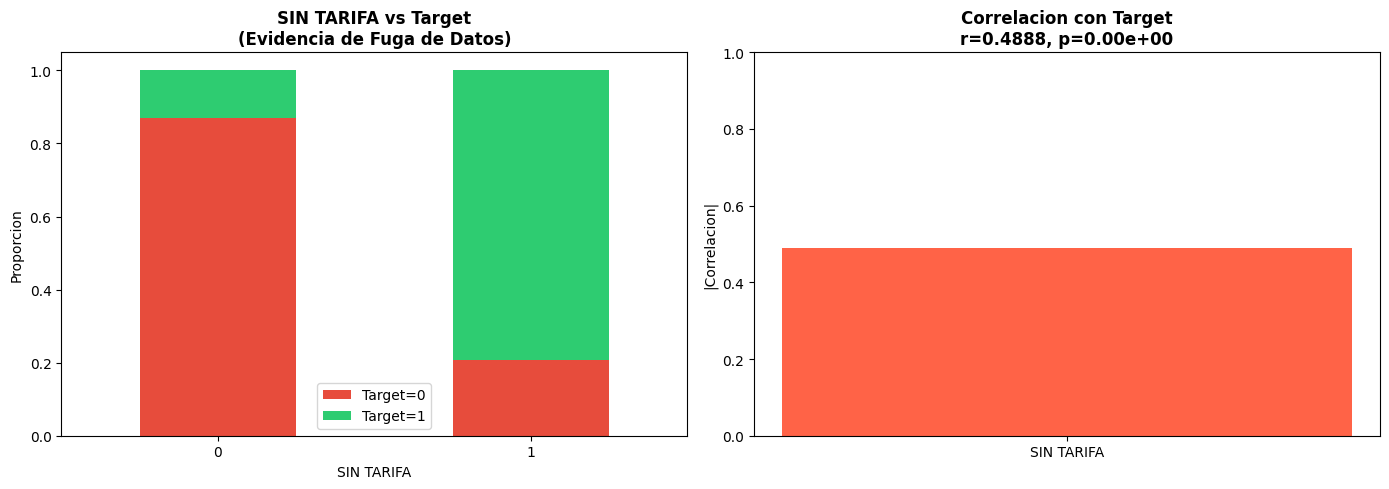

✓ Grafica guardada: sospecha_tipo_cliente_vs_target.png


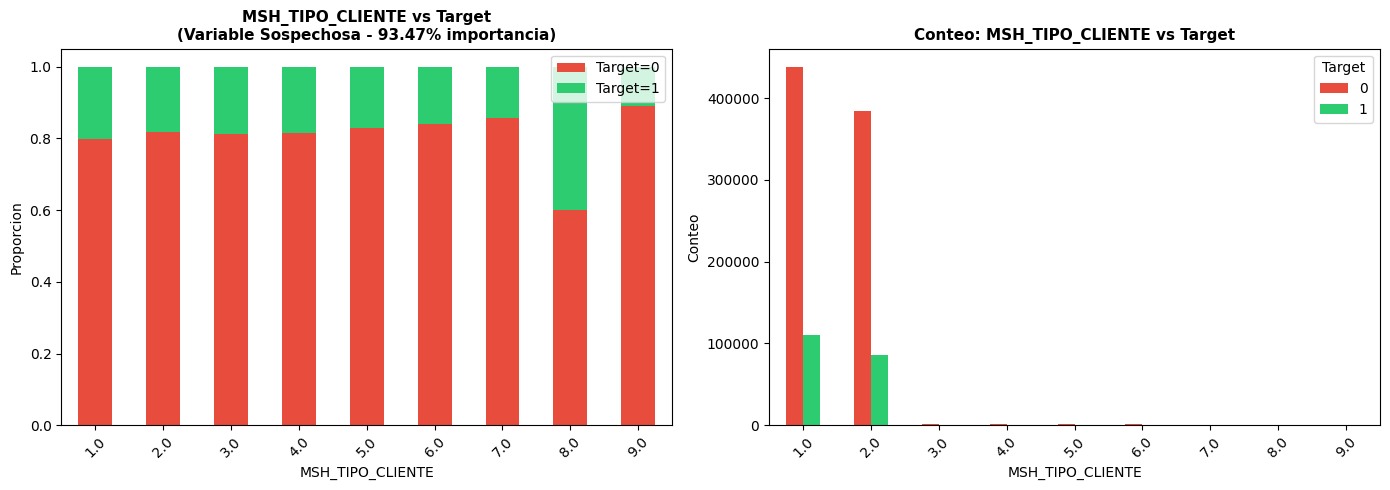

✓ Grafica guardada: correlacion_variables_target.png


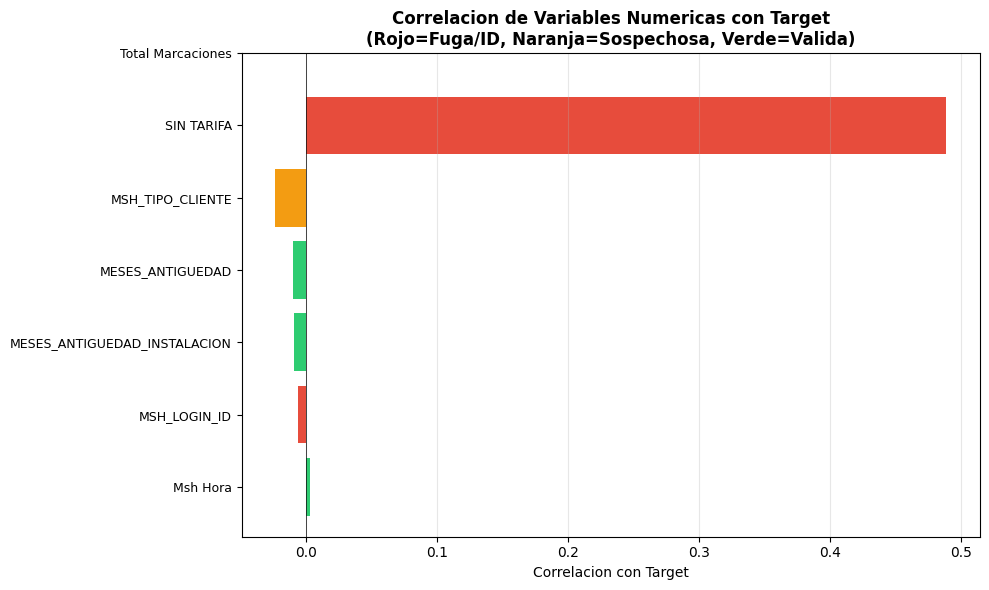

✓ Grafica guardada: decision_variables_tabla.png


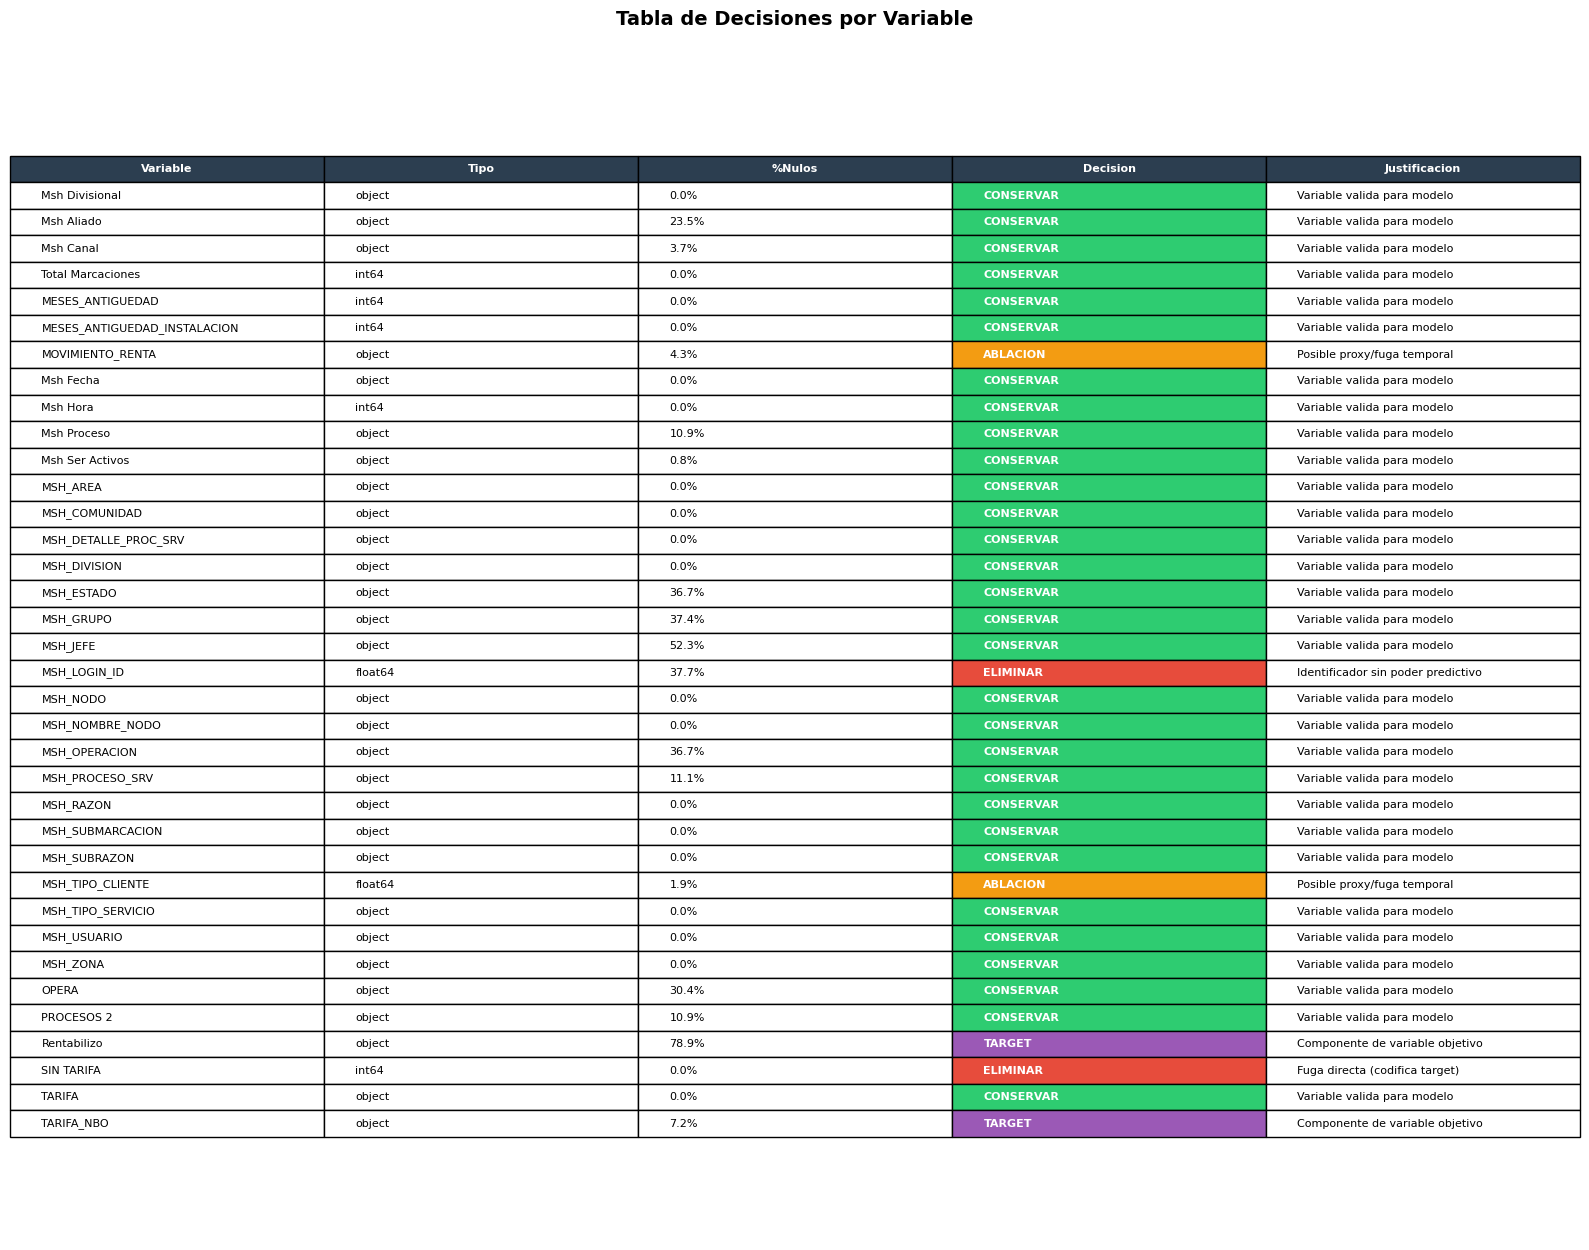


✓ Paso 4.1 completado


In [6]:
print('=' * 80)
print('PASO 4.1: EDA CON DECISIONES CONCRETAS')
print('=' * 80)

graficas_dir = os.path.join('resultados', 'graficas23Febrero')
os.makedirs(graficas_dir, exist_ok=True)

# Construir variable objetivo temporal para analisis
col_tarifa_eda = 'TARIFA_NBO'
col_rent_eda = 'Rentabilizo'

if col_tarifa_eda in df.columns and col_rent_eda in df.columns:
    target_eda = np.where(
        (df[col_tarifa_eda].notna()) & (df[col_rent_eda].notna()), 1, 0
    )
    print(f'Variable objetivo construida: {sum(target_eda==1):,} positivos ({sum(target_eda==1)/len(target_eda)*100:.1f}%), '
          f'{sum(target_eda==0):,} negativos ({sum(target_eda==0)/len(target_eda)*100:.1f}%)')
else:
    print('ERROR: No se encontraron TARIFA_NBO y/o Rentabilizo')
    target_eda = None

# Clasificacion de columnas
identificadores = [c for c in ['Msh Cuenta', 'MSH_CEDULA', 'MSH_LOGIN_ID'] if c in df.columns]
fuga_directa = [c for c in ['SIN TARIFA'] if c in df.columns]
target_cols = [c for c in ['TARIFA_NBO', 'Rentabilizo'] if c in df.columns]
fecha_cols = [c for c in ['Msh Fecha (copia)'] if c in df.columns]
duplicadas = [c for c in ['Msh Hora (copia)'] if c in df.columns]
sospechosas = [c for c in ['MSH_TIPO_CLIENTE', 'MOVIMIENTO_RENTA'] if c in df.columns]
todas_excluidas = identificadores + fuga_directa + target_cols + fecha_cols + duplicadas

validas = [c for c in df.columns if c not in todas_excluidas + sospechosas]

print(f'\nClasificacion de {len(df.columns)} columnas:')
print(f'  Identificadores (eliminar):          {identificadores}')
print(f'  Fuga directa (eliminar):             {fuga_directa}')
print(f'  Target (no usar como feature):       {target_cols}')
print(f'  Fecha (reservar para val. temporal): {fecha_cols}')
print(f'  Duplicadas (eliminar):               {duplicadas}')
print(f'  Sospechosas (ablacion):              {sospechosas}')
print(f'  Variables validas:                   {len(validas)} columnas')

if target_eda is not None:
    # ---- Grafica 1: SIN TARIFA vs Target (evidencia de fuga) ----
    if 'SIN TARIFA' in df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Distribucion de SIN TARIFA por target
        df_fuga = pd.DataFrame({'SIN TARIFA': df['SIN TARIFA'], 'Target': target_eda})
        ct = pd.crosstab(df_fuga['SIN TARIFA'], df_fuga['Target'], normalize='index')

        ct.plot(kind='bar', stacked=True, ax=axes[0], color=['#e74c3c', '#2ecc71'])
        axes[0].set_title('SIN TARIFA vs Target\n(Evidencia de Fuga de Datos)',
                         fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Proporcion')
        axes[0].set_xlabel('SIN TARIFA')
        axes[0].legend(['Target=0', 'Target=1'])
        axes[0].tick_params(axis='x', rotation=0)

        # Correlacion puntual
        from scipy import stats
        corr_sin_tarifa = np.nan
        try:
            sin_tarifa_num = pd.to_numeric(df['SIN TARIFA'], errors='coerce')
            mask = sin_tarifa_num.notna()
            if mask.sum() > 10:
                corr_sin_tarifa, p_val = stats.pointbiserialr(target_eda[mask], sin_tarifa_num[mask])
                axes[1].bar(['SIN TARIFA'], [abs(corr_sin_tarifa)], color='tomato')
                axes[1].set_title(f'Correlacion con Target\nr={corr_sin_tarifa:.4f}, p={p_val:.2e}',
                                 fontsize=12, fontweight='bold')
                axes[1].set_ylabel('|Correlacion|')
                axes[1].set_ylim(0, 1)
            else:
                # Si no es numerica, mostrar tabla cruzada
                ct_counts = pd.crosstab(df_fuga['SIN TARIFA'], df_fuga['Target'])
                ct_counts.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'])
                axes[1].set_title('Conteo: SIN TARIFA vs Target', fontsize=12, fontweight='bold')
                axes[1].set_ylabel('Conteo')
        except Exception as e:
            ct_counts = pd.crosstab(df_fuga['SIN TARIFA'], df_fuga['Target'])
            ct_counts.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'])
            axes[1].set_title('Conteo: SIN TARIFA vs Target', fontsize=12, fontweight='bold')

        plt.tight_layout()
        plt.savefig(os.path.join(graficas_dir, 'fuga_sin_tarifa_vs_target.png'), dpi=300, bbox_inches='tight')
        print(f'\n\u2713 Grafica guardada: fuga_sin_tarifa_vs_target.png')
        plt.show()
        plt.close()

    # ---- Grafica 2: MSH_TIPO_CLIENTE vs Target (sospecha) ----
    if 'MSH_TIPO_CLIENTE' in df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        df_tipo = pd.DataFrame({'MSH_TIPO_CLIENTE': df['MSH_TIPO_CLIENTE'], 'Target': target_eda})
        ct_tipo = pd.crosstab(df_tipo['MSH_TIPO_CLIENTE'], df_tipo['Target'], normalize='index')

        ct_tipo.plot(kind='bar', stacked=True, ax=axes[0], color=['#e74c3c', '#2ecc71'])
        axes[0].set_title('MSH_TIPO_CLIENTE vs Target\n(Variable Sospechosa - 93.47% importancia)',
                         fontsize=11, fontweight='bold')
        axes[0].set_ylabel('Proporcion')
        axes[0].set_xlabel('MSH_TIPO_CLIENTE')
        axes[0].legend(['Target=0', 'Target=1'])
        axes[0].tick_params(axis='x', rotation=45)

        ct_tipo_counts = pd.crosstab(df_tipo['MSH_TIPO_CLIENTE'], df_tipo['Target'])
        ct_tipo_counts.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'])
        axes[1].set_title('Conteo: MSH_TIPO_CLIENTE vs Target', fontsize=11, fontweight='bold')
        axes[1].set_ylabel('Conteo')
        axes[1].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.savefig(os.path.join(graficas_dir, 'sospecha_tipo_cliente_vs_target.png'), dpi=300, bbox_inches='tight')
        print(f'\u2713 Grafica guardada: sospecha_tipo_cliente_vs_target.png')
        plt.show()
        plt.close()

    # ---- Grafica 3: Correlacion de variables numericas con target ----
    cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
    cols_numericas_filtradas = [c for c in cols_numericas if c not in target_cols]

    if len(cols_numericas_filtradas) > 0:
        correlaciones = {}
        for col in cols_numericas_filtradas:
            mask = df[col].notna()
            if mask.sum() > 10:
                try:
                    corr, _ = stats.pointbiserialr(target_eda[mask], df[col][mask])
                    correlaciones[col] = corr
                except:
                    pass

        if correlaciones:
            df_corr = pd.DataFrame.from_dict(correlaciones, orient='index', columns=['Correlacion'])
            df_corr['Abs_Corr'] = df_corr['Correlacion'].abs()
            df_corr = df_corr.sort_values('Abs_Corr', ascending=True)

            fig, ax = plt.subplots(figsize=(10, max(6, len(df_corr) * 0.4)))
            colores = ['#e74c3c' if c in identificadores + fuga_directa else
                       '#f39c12' if c in sospechosas else '#2ecc71'
                       for c in df_corr.index]
            ax.barh(range(len(df_corr)), df_corr['Correlacion'].values, color=colores)
            ax.set_yticks(range(len(df_corr)))
            ax.set_yticklabels(df_corr.index, fontsize=9)
            ax.set_xlabel('Correlacion con Target')
            ax.set_title('Correlacion de Variables Numericas con Target\n'
                        '(Rojo=Fuga/ID, Naranja=Sospechosa, Verde=Valida)',
                        fontsize=12, fontweight='bold')
            ax.axvline(x=0, color='black', linewidth=0.5)
            ax.grid(axis='x', alpha=0.3)
            plt.tight_layout()
            plt.savefig(os.path.join(graficas_dir, 'correlacion_variables_target.png'), dpi=300, bbox_inches='tight')
            print(f'\u2713 Grafica guardada: correlacion_variables_target.png')
            plt.show()
            plt.close()

    # ---- Grafica 4: Tabla resumen de decisiones ----
    decisiones = []
    for col in df.columns:
        n_nulos = df[col].isnull().sum()
        pct_nulos = n_nulos / len(df) * 100
        tipo = str(df[col].dtype)

        if col in identificadores:
            decision = 'ELIMINAR'
            justificacion = 'Identificador sin poder predictivo'
            color = '#e74c3c'
        elif col in fuga_directa:
            decision = 'ELIMINAR'
            justificacion = 'Fuga directa (codifica target)'
            color = '#e74c3c'
        elif col in target_cols:
            decision = 'TARGET'
            justificacion = 'Componente de variable objetivo'
            color = '#9b59b6'
        elif col in fecha_cols:
            decision = 'RESERVAR'
            justificacion = 'Para validacion temporal'
            color = '#3498db'
        elif col in duplicadas:
            decision = 'ELIMINAR'
            justificacion = 'Duplicado de otra columna'
            color = '#e74c3c'
        elif col in sospechosas:
            decision = 'ABLACION'
            justificacion = 'Posible proxy/fuga temporal'
            color = '#f39c12'
        else:
            decision = 'CONSERVAR'
            justificacion = 'Variable valida para modelo'
            color = '#2ecc71'

        decisiones.append({
            'Variable': col, 'Tipo': tipo, '%Nulos': f'{pct_nulos:.1f}%',
            'Decision': decision, 'Justificacion': justificacion, 'color': color
        })

    df_decisiones = pd.DataFrame(decisiones)

    # Crear tabla visual
    fig, ax = plt.subplots(figsize=(16, max(8, len(df_decisiones) * 0.35)))
    ax.axis('off')
    ax.set_title('Tabla de Decisiones por Variable', fontsize=14, fontweight='bold', pad=20)

    cols_tabla = ['Variable', 'Tipo', '%Nulos', 'Decision', 'Justificacion']
    tabla = ax.table(
        cellText=df_decisiones[cols_tabla].values,
        colLabels=cols_tabla,
        loc='center',
        cellLoc='left'
    )
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(8)
    tabla.scale(1, 1.3)

    # Colorear celdas de Decision
    for i, row in df_decisiones.iterrows():
        tabla[i + 1, 3].set_facecolor(row['color'])
        tabla[i + 1, 3].set_text_props(color='white', fontweight='bold')

    # Header
    for j in range(len(cols_tabla)):
        tabla[0, j].set_facecolor('#2c3e50')
        tabla[0, j].set_text_props(color='white', fontweight='bold')

    plt.tight_layout()
    plt.savefig(os.path.join(graficas_dir, 'decision_variables_tabla.png'), dpi=300, bbox_inches='tight')
    print(f'\u2713 Grafica guardada: decision_variables_tabla.png')
    plt.show()
    plt.close()

print('\n\u2713 Paso 4.1 completado')

## Paso 5: Identificación y Filtrado de Datos


In [7]:
columna_tarifa = None
columna_target = None

for col in df.columns:
    if 'tarifa' in col.lower() and 'nbo' in col.lower():
        columna_tarifa = col
        break

if columna_tarifa is None:
    posibles = [col for col in df.columns if 'tarifa' in col.lower() or 'nbo' in col.lower()]
    if posibles:
        columna_tarifa = posibles[0]

for col in df.columns:
    if 'rentabilizacion' in col.lower() or 'rentabiliz' in col.lower():
        columna_target = col
        break

if columna_target is None:
    posibles = [col for col in df.columns if 'rent' in col.lower()]
    if posibles:
        columna_target = posibles[0]

print(f"Columna Tarifa NBO: {columna_tarifa}")
print(f"Columna Rentabilizacion: {columna_target}")

if columna_tarifa and columna_target:
    df_filtrado = df[df[columna_tarifa].notna()].copy()
    print(f"\nFilas después de filtrar por {columna_tarifa}: {len(df_filtrado)}")
    
    df_filtrado = df_filtrado[df_filtrado[columna_target].notna()].copy()
    print(f"Filas después de filtrar por {columna_target}: {len(df_filtrado)}")
    
    print(f"\nDistribución de la variable objetivo ({columna_target}):")
    display(df_filtrado[columna_target].value_counts())
else:
    print("\nError: No se encontraron las columnas necesarias")
    df_filtrado = None


Columna Tarifa NBO: TARIFA_NBO
Columna Rentabilizacion: Rentabilizo



Filas después de filtrar por TARIFA_NBO: 972845
Filas después de filtrar por Rentabilizo: 201314

Distribución de la variable objetivo (Rentabilizo):


Rentabilizo
SI    201314
Name: count, dtype: int64

## Paso 5.1: Documentacion de Variables Eliminadas

Registro formal de todas las variables excluidas del modelo con su justificacion tecnica.
Se incluyen variables sospechosas que seran evaluadas por ablacion en el Paso 14.1.

In [8]:
print('=' * 80)
print('PASO 5.1: DOCUMENTACION DE VARIABLES ELIMINADAS')
print('=' * 80)

graficas_dir = os.path.join('resultados', 'graficas23Febrero')
os.makedirs(graficas_dir, exist_ok=True)

# Diccionario formal de exclusiones
exclusiones = {
    'identificadores': {
        'columnas': ['Msh Cuenta', 'MSH_CEDULA', 'MSH_LOGIN_ID'],
        'razon': 'Identificadores unicos sin poder predictivo. Su inclusion causaria '
                 'memorizacion de casos individuales (overfitting extremo).',
        'accion': 'ELIMINAR'
    },
    'fuga_directa': {
        'columnas': ['SIN TARIFA'],
        'razon': 'Codifica directamente si existe TARIFA_NBO, que es componente del target. '
                 'Su correlacion con el target es artificialment alta.',
        'accion': 'ELIMINAR'
    },
    'target': {
        'columnas': ['TARIFA_NBO', 'Rentabilizo'],
        'razon': 'Componentes de la variable objetivo. No pueden usarse como features.',
        'accion': 'ELIMINAR (son el target)'
    },
    'fecha': {
        'columnas': ['Msh Fecha (copia)'],
        'razon': 'Columna de fecha reservada para validacion temporal. '
                 'No se usa como feature pero si para dividir train/test temporal.',
        'accion': 'RESERVAR para validacion temporal'
    },
    'duplicadas': {
        'columnas': ['Msh Hora (copia)'],
        'razon': 'Duplicado de la columna Msh Hora. Informacion redundante.',
        'accion': 'ELIMINAR'
    },
    'sospechosas_para_ablacion': {
        'columnas': ['MSH_TIPO_CLIENTE', 'MOVIMIENTO_RENTA'],
        'razon': 'MSH_TIPO_CLIENTE mostro 93.47% de importancia en modelos previos (posible proxy del target). '
                 'MOVIMIENTO_RENTA podria contener informacion post-resultado (fuga temporal). '
                 'Se evaluaran en analisis de ablacion (Paso 14.1).',
        'accion': 'EVALUAR por ablacion'
    }
}

# Imprimir resumen
total_eliminadas = 0
for categoria, info in exclusiones.items():
    cols_existentes = [c for c in info['columnas'] if c in df.columns]
    total_eliminadas += len(cols_existentes) if info['accion'].startswith('ELIMINAR') else 0
    print(f'\n{categoria.upper()}:')
    print(f'  Columnas: {cols_existentes}')
    print(f'  Razon: {info["razon"]}')
    print(f'  Accion: {info["accion"]}')

print(f'\n{"="*60}')
print(f'Total columnas a eliminar definitivamente: {total_eliminadas}')
print(f'Total columnas para ablacion: {len(exclusiones["sospechosas_para_ablacion"]["columnas"])}')

# Guardar como JSON
ruta_exclusiones = os.path.join(graficas_dir, 'documentacion_variables_eliminadas.json')
with open(ruta_exclusiones, 'w', encoding='utf-8') as f:
    json.dump(exclusiones, f, indent=2, ensure_ascii=False)
print(f'\n\u2713 Documentacion guardada en: {ruta_exclusiones}')

print('\n\u2713 Paso 5.1 completado')

PASO 5.1: DOCUMENTACION DE VARIABLES ELIMINADAS

IDENTIFICADORES:
  Columnas: ['MSH_LOGIN_ID']
  Razon: Identificadores unicos sin poder predictivo. Su inclusion causaria memorizacion de casos individuales (overfitting extremo).
  Accion: ELIMINAR

FUGA_DIRECTA:
  Columnas: ['SIN TARIFA']
  Razon: Codifica directamente si existe TARIFA_NBO, que es componente del target. Su correlacion con el target es artificialment alta.
  Accion: ELIMINAR

TARGET:
  Columnas: ['TARIFA_NBO', 'Rentabilizo']
  Razon: Componentes de la variable objetivo. No pueden usarse como features.
  Accion: ELIMINAR (son el target)

FECHA:
  Columnas: []
  Razon: Columna de fecha reservada para validacion temporal. No se usa como feature pero si para dividir train/test temporal.
  Accion: RESERVAR para validacion temporal

DUPLICADAS:
  Columnas: []
  Razon: Duplicado de la columna Msh Hora. Informacion redundante.
  Accion: ELIMINAR

SOSPECHOSAS_PARA_ABLACION:
  Columnas: ['MSH_TIPO_CLIENTE', 'MOVIMIENTO_RENTA']
  

## Paso 6: Preparación de Datos para Modelado


In [9]:
if df_filtrado is not None and columna_target:
    y = df_filtrado[columna_target].copy()

    # CORRECCION CRITICA: Eliminar identificadores, columnas con fuga y fechas
    columnas_a_eliminar = [
        columna_target,       # Variable objetivo (Rentabilizo)
        'TARIFA_NBO',         # Componente del target
        'Msh Cuenta',         # Identificador de cuenta
        'MSH_CEDULA',         # Identificador personal
        'MSH_LOGIN_ID',       # Identificador de login
        'SIN TARIFA',         # Fuga directa (codifica existencia de TARIFA_NBO)
        'Msh Fecha (copia)',  # Fecha (reservada para validacion temporal)
        'Msh Hora (copia)'    # Duplicado de Msh Hora
    ]
    columnas_existentes = [c for c in columnas_a_eliminar if c in df_filtrado.columns]
    X = df_filtrado.drop(columns=columnas_existentes)

    print(f"\n{'='*60}")
    print("CORRECCION APLICADA - Columnas eliminadas por riesgo de fuga:")
    print(f"{'='*60}")
    for c in columnas_existentes:
        print(f"  - {c}")
    print(f"Total eliminadas: {len(columnas_existentes)}")
    print(f"Features restantes: {X.shape[1]}")

    columnas_numericas = X.select_dtypes(include=[np.number]).columns.tolist()
    columnas_categoricas = X.select_dtypes(include=['object', 'category']).columns.tolist()

    print(f"\nColumnas numericas: {len(columnas_numericas)}")
    print(f"Columnas categoricas: {len(columnas_categoricas)}")

    X_processed = X[columnas_numericas].copy()

    for col in columnas_categoricas:
        if X[col].nunique() < 50:
            le = LabelEncoder()
            X_processed[col] = le.fit_transform(X[col].astype(str).fillna('Missing'))

    X_processed = X_processed.fillna(X_processed.median())

    if isinstance(y.dtype, object) or y.dtype == 'object':
        le_target = LabelEncoder()
        y = le_target.fit_transform(y.astype(str))
    else:
        y = y.astype(int)

    print(f"\nShape final: X={X_processed.shape}, y={y.shape}")
    print(f"Clases en y: {np.unique(y)}")

    X_train, X_test, y_train, y_test = train_test_split(
        X_processed, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"\n\u2713 Datos preparados (SIN columnas con fuga):")
    print(f"  Train: {X_train.shape[0]} muestras, {X_train.shape[1]} features")
    print(f"  Test: {X_test.shape[0]} muestras, {X_test.shape[1]} features")
else:
    print("Error: No se pueden preparar los datos")


CORRECCION APLICADA - Columnas eliminadas por riesgo de fuga:
  - Rentabilizo
  - TARIFA_NBO
  - MSH_LOGIN_ID
  - SIN TARIFA
Total eliminadas: 4
Features restantes: 32



Columnas numericas: 5
Columnas categoricas: 27



Shape final: X=(201314, 19), y=(201314,)
Clases en y: [0]

✓ Datos preparados (SIN columnas con fuga):
  Train: 161051 muestras, 19 features
  Test: 40263 muestras, 19 features


## Paso 7: Entrenamiento de Modelos

Dividimos el flujo en subpasos utilizando lecturas por bloques de 50.000 filas para monitorear el progreso y reutilizar los artefactos generados.


## Paso 8: Grid Search con muestreo estratificado


In [10]:
if 'X_processed' not in globals() or 'y' not in globals():
    raise RuntimeError('Es necesario ejecutar el Paso 7.1.1 antes de continuar.')

n_muestra = min(300000, len(X_processed))
print(f"Tomando muestra estratificada de {n_muestra} registros para grid search...", flush=True)

if n_muestra >= len(X_processed):
    X_muestra, y_muestra = X_processed, y
    print(f"  Usando dataset completo ({len(X_processed)} registros)", flush=True)
else:
    X_muestra, _, y_muestra, _ = train_test_split(
        X_processed,
        y,
        train_size=n_muestra,
        random_state=42,
        stratify=y
    )

X_train_grid, X_test_grid, y_train_grid, y_test_grid = train_test_split(
    X_muestra,
    y_muestra,
    test_size=0.2,
    random_state=42,
    stratify=y_muestra
)

print(f"  Train: {X_train_grid.shape[0]} muestras", flush=True)
print(f"  Test: {X_test_grid.shape[0]} muestras", flush=True)

cv_grid = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print('\nGrid Search - Random Forest', flush=True)
parametros_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
modelo_grid_rf = GridSearchCV(
    rf_base,
    parametros_rf,
    cv=cv_grid,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)
modelo_grid_rf.fit(X_train_grid, y_train_grid)

resultado_grid_rf = {
    'best_params': modelo_grid_rf.best_params_,
    'best_score': float(modelo_grid_rf.best_score_)
}

with open(os.path.join(output_dir, 'grid_rf.json'), 'w', encoding='utf-8') as archivo_rf:
    json.dump(resultado_grid_rf, archivo_rf, indent=2)

print(f"✓ Mejor combinación RF: {resultado_grid_rf['best_params']} (score {resultado_grid_rf['best_score']:.4f})", flush=True)

print('\nGrid Search - XGBoost', flush=True)
parametros_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb_base = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')
modelo_grid_xgb = GridSearchCV(
    xgb_base,
    parametros_xgb,
    cv=cv_grid,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)
modelo_grid_xgb.fit(X_train_grid, y_train_grid)

resultado_grid_xgb = {
    'best_params': modelo_grid_xgb.best_params_,
    'best_score': float(modelo_grid_xgb.best_score_)
}

with open(os.path.join(output_dir, 'grid_xgb.json'), 'w', encoding='utf-8') as archivo_xgb:
    json.dump(resultado_grid_xgb, archivo_xgb, indent=2)

print(f"✓ Mejor combinación XGBoost: {resultado_grid_xgb['best_params']} (score {resultado_grid_xgb['best_score']:.4f})", flush=True)
print('\n✓ Paso 8 completado', flush=True)

Tomando muestra estratificada de 201314 registros para grid search...


  Usando dataset completo (201314 registros)


  Train: 161051 muestras


  Test: 40263 muestras



Grid Search - Random Forest


...

✓ Mejor combinación RF: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100} (score 1.0000)



Grid Search - XGBoost


Fitting 3 folds for each of 16 candidates, totalling 48 fits


✓ Mejor combinación XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8} (score 1.0000)



✓ Paso 8 completado


## Paso 9: Resumen de resultados de Grid Search


In [11]:
ruta_grid_rf = os.path.join(output_dir, 'grid_rf.json')
ruta_grid_xgb = os.path.join(output_dir, 'grid_xgb.json')

with open(ruta_grid_rf, 'r', encoding='utf-8') as archivo_rf:
    resumen_rf = json.load(archivo_rf)

with open(ruta_grid_xgb, 'r', encoding='utf-8') as archivo_xgb:
    resumen_xgb = json.load(archivo_xgb)

print('Resultados guardados de Grid Search:', flush=True)
print(f"  Random Forest -> score CV: {resumen_rf['best_score']:.4f} | parámetros: {resumen_rf['best_params']}", flush=True)
print(f"  XGBoost       -> score CV: {resumen_xgb['best_score']:.4f} | parámetros: {resumen_xgb['best_params']}", flush=True)

if 'modelo_grid_rf' in globals() and 'modelo_grid_xgb' in globals():
    print('\nEvaluación rápida en el conjunto de prueba retenido de la muestra:', flush=True)
    pred_rf = modelo_grid_rf.best_estimator_.predict(X_test_grid)
    pred_xgb = modelo_grid_xgb.best_estimator_.predict(X_test_grid)
    print(f"  Random Forest -> accuracy test: {accuracy_score(y_test_grid, pred_rf):.4f}", flush=True)
    print(f"  XGBoost       -> accuracy test: {accuracy_score(y_test_grid, pred_xgb):.4f}", flush=True)
else:
    print('\nPara evaluar en test es necesario volver a ejecutar el Paso 8 en esta sesión.', flush=True)


Resultados guardados de Grid Search:


  Random Forest -> score CV: 1.0000 | parámetros: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


  XGBoost       -> score CV: 1.0000 | parámetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}



Evaluación rápida en el conjunto de prueba retenido de la muestra:


  Random Forest -> accuracy test: 1.0000


  XGBoost       -> accuracy test: 1.0000


## Paso 10: Comparación y Conclusión


In [12]:
ruta_grid_rf = os.path.join(output_dir, 'grid_rf.json')
ruta_grid_xgb = os.path.join(output_dir, 'grid_xgb.json')
ruta_cv_lr = os.path.join(output_dir, 'resultado_cv_lr.json')

faltantes = [ruta for ruta in [ruta_grid_rf, ruta_grid_xgb, ruta_cv_lr] if not os.path.exists(ruta)]
if faltantes:
    raise FileNotFoundError(f"No se encontraron los archivos requeridos: {faltantes}")

with open(ruta_grid_rf, 'r', encoding='utf-8') as archivo_rf:
    resumen_rf = json.load(archivo_rf)

with open(ruta_grid_xgb, 'r', encoding='utf-8') as archivo_xgb:
    resumen_xgb = json.load(archivo_xgb)

with open(ruta_cv_lr, 'r', encoding='utf-8') as archivo_lr:
    resumen_lr = json.load(archivo_lr)

print('COMPARACIÓN DE MODELOS', flush=True)
print('=' * 80, flush=True)
print('\nValidación cruzada - Regresión logística:', flush=True)
print(f"  Accuracy promedio: {resumen_lr['mean']:.4f} (+/- {resumen_lr['std'] * 2:.4f})", flush=True)

print('\nGrid Search - Modelos de árboles:', flush=True)
print(f"  Random Forest -> score CV: {resumen_rf['best_score']:.4f} | parámetros: {resumen_rf['best_params']}", flush=True)
print(f"  XGBoost       -> score CV: {resumen_xgb['best_score']:.4f} | parámetros: {resumen_xgb['best_params']}", flush=True)

mejor_arbol = 'RandomForest' if resumen_rf['best_score'] > resumen_xgb['best_score'] else 'XGBoost'

print('\n' + '=' * 80, flush=True)
print('CONCLUSIÓN', flush=True)
print('=' * 80, flush=True)
print(f"  Mejor modelo entre árboles (según Grid Search): {mejor_arbol}", flush=True)

conclusion = {
    'cv_lr_mean': resumen_lr['mean'],
    'cv_lr_std': resumen_lr['std'],
    'grid_rf': resumen_rf,
    'grid_xgb': resumen_xgb,
    'best_tree_model': mejor_arbol
}

ruta_conclusion = os.path.join(output_dir, 'conclusion_paso_10.json')
with open(ruta_conclusion, 'w', encoding='utf-8') as archivo_conclusion:
    json.dump(conclusion, archivo_conclusion, indent=2)

print(f"\n✓ Conclusión almacenada en: {ruta_conclusion}", flush=True)


COMPARACIÓN DE MODELOS



Validación cruzada - Regresión logística:


  Accuracy promedio: 0.8442 (+/- 0.0012)



Grid Search - Modelos de árboles:


  Random Forest -> score CV: 1.0000 | parámetros: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


  XGBoost       -> score CV: 1.0000 | parámetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


CONCLUSIÓN


  Mejor modelo entre árboles (según Grid Search): XGBoost



✓ Conclusión almacenada en: resultados/conclusion_paso_10.json


## Paso 11: Análisis de Importancia de Variables y Visualizaciones

En este paso analizamos las variables más importantes usando el mejor modelo (XGBoost) y creamos visualizaciones del análisis.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import plot_tree, plot_importance
import graphviz
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
from sklearn.tree import export_graphviz
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print('=' * 80)
print('PASO 11: ANÁLISIS DE IMPORTANCIA Y VISUALIZACIONES')
print('=' * 80)


PASO 11: ANÁLISIS DE IMPORTANCIA Y VISUALIZACIONES


In [14]:
print('\nCargando datos preparados y resultados...', flush=True)

ruta_datos = os.path.join(output_dir, 'datos_preparados_7_1.pkl')
with open(ruta_datos, 'rb') as f:
    datos = pickle.load(f)

X_train_scaled = datos['X_train_scaled']
X_test_scaled = datos['X_test_scaled']
y_train = datos['y_train']
y_test = datos['y_test']

print(f'✓ Datos cargados: Train={X_train_scaled.shape[0]}, Test={X_test_scaled.shape[0]}', flush=True)

with open(os.path.join(output_dir, 'grid_xgb.json'), 'r', encoding='utf-8') as f:
    grid_xgb_params = json.load(f)

print(f'✓ Parámetros óptimos XGBoost cargados: {grid_xgb_params["best_params"]}', flush=True)



Cargando datos preparados y resultados...


✓ Datos cargados: Train=838860, Test=209715


✓ Parámetros óptimos XGBoost cargados: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [15]:
print('\nEntrenando modelo XGBoost con parámetros óptimos...', flush=True)

xgb_optimizado = XGBClassifier(
    n_estimators=grid_xgb_params['best_params']['n_estimators'],
    max_depth=grid_xgb_params['best_params']['max_depth'],
    learning_rate=grid_xgb_params['best_params']['learning_rate'],
    subsample=grid_xgb_params['best_params']['subsample'],
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_optimizado.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_optimizado.predict(X_test_scaled)
y_pred_proba_xgb = xgb_optimizado.predict_proba(X_test_scaled)[:, 1]

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f'✓ Modelo entrenado - Accuracy en test: {accuracy_xgb:.4f}', flush=True)

ruta_modelo_xgb = os.path.join(output_dir, 'modelo_xgb_optimizado.pkl')
with open(ruta_modelo_xgb, 'wb') as f:
    pickle.dump(xgb_optimizado, f)
print(f'✓ Modelo guardado en: {ruta_modelo_xgb}', flush=True)



Entrenando modelo XGBoost con parámetros óptimos...


✓ Modelo entrenado - Accuracy en test: 0.9894


✓ Modelo guardado en: resultados/modelo_xgb_optimizado.pkl


### 11.1: Importancia de Características


In [16]:
print('\nAnalizando importancia de características...', flush=True)

importancia = xgb_optimizado.feature_importances_
feature_names = [f'Feature_{i}' for i in range(len(importancia))]

df_importancia = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importancia
}).sort_values('Importance', ascending=False)

print(f'\nTop 20 características más importantes:', flush=True)
print(df_importancia.head(20).to_string(index=False), flush=True)

df_importancia.to_csv(os.path.join(output_dir, 'importancia_caracteristicas.csv'), index=False)
print(f'\n✓ Importancia guardada en CSV', flush=True)



Analizando importancia de características...



Top 20 características más importantes:


   Feature  Importance
 Feature_9    0.832011
 Feature_1    0.076997
 Feature_6    0.049522
 Feature_2    0.023451
 Feature_5    0.007306
 Feature_4    0.003237
Feature_11    0.001324
Feature_13    0.001321
Feature_16    0.001212
 Feature_8    0.001102
Feature_17    0.001089
Feature_12    0.000918
Feature_10    0.000512
Feature_19    0.000000
Feature_18    0.000000
 Feature_0    0.000000
Feature_15    0.000000
Feature_14    0.000000
 Feature_7    0.000000
 Feature_3    0.000000



✓ Importancia guardada en CSV


✓ Gráfica de importancia guardada en: resultados/importancia_caracteristicas.png


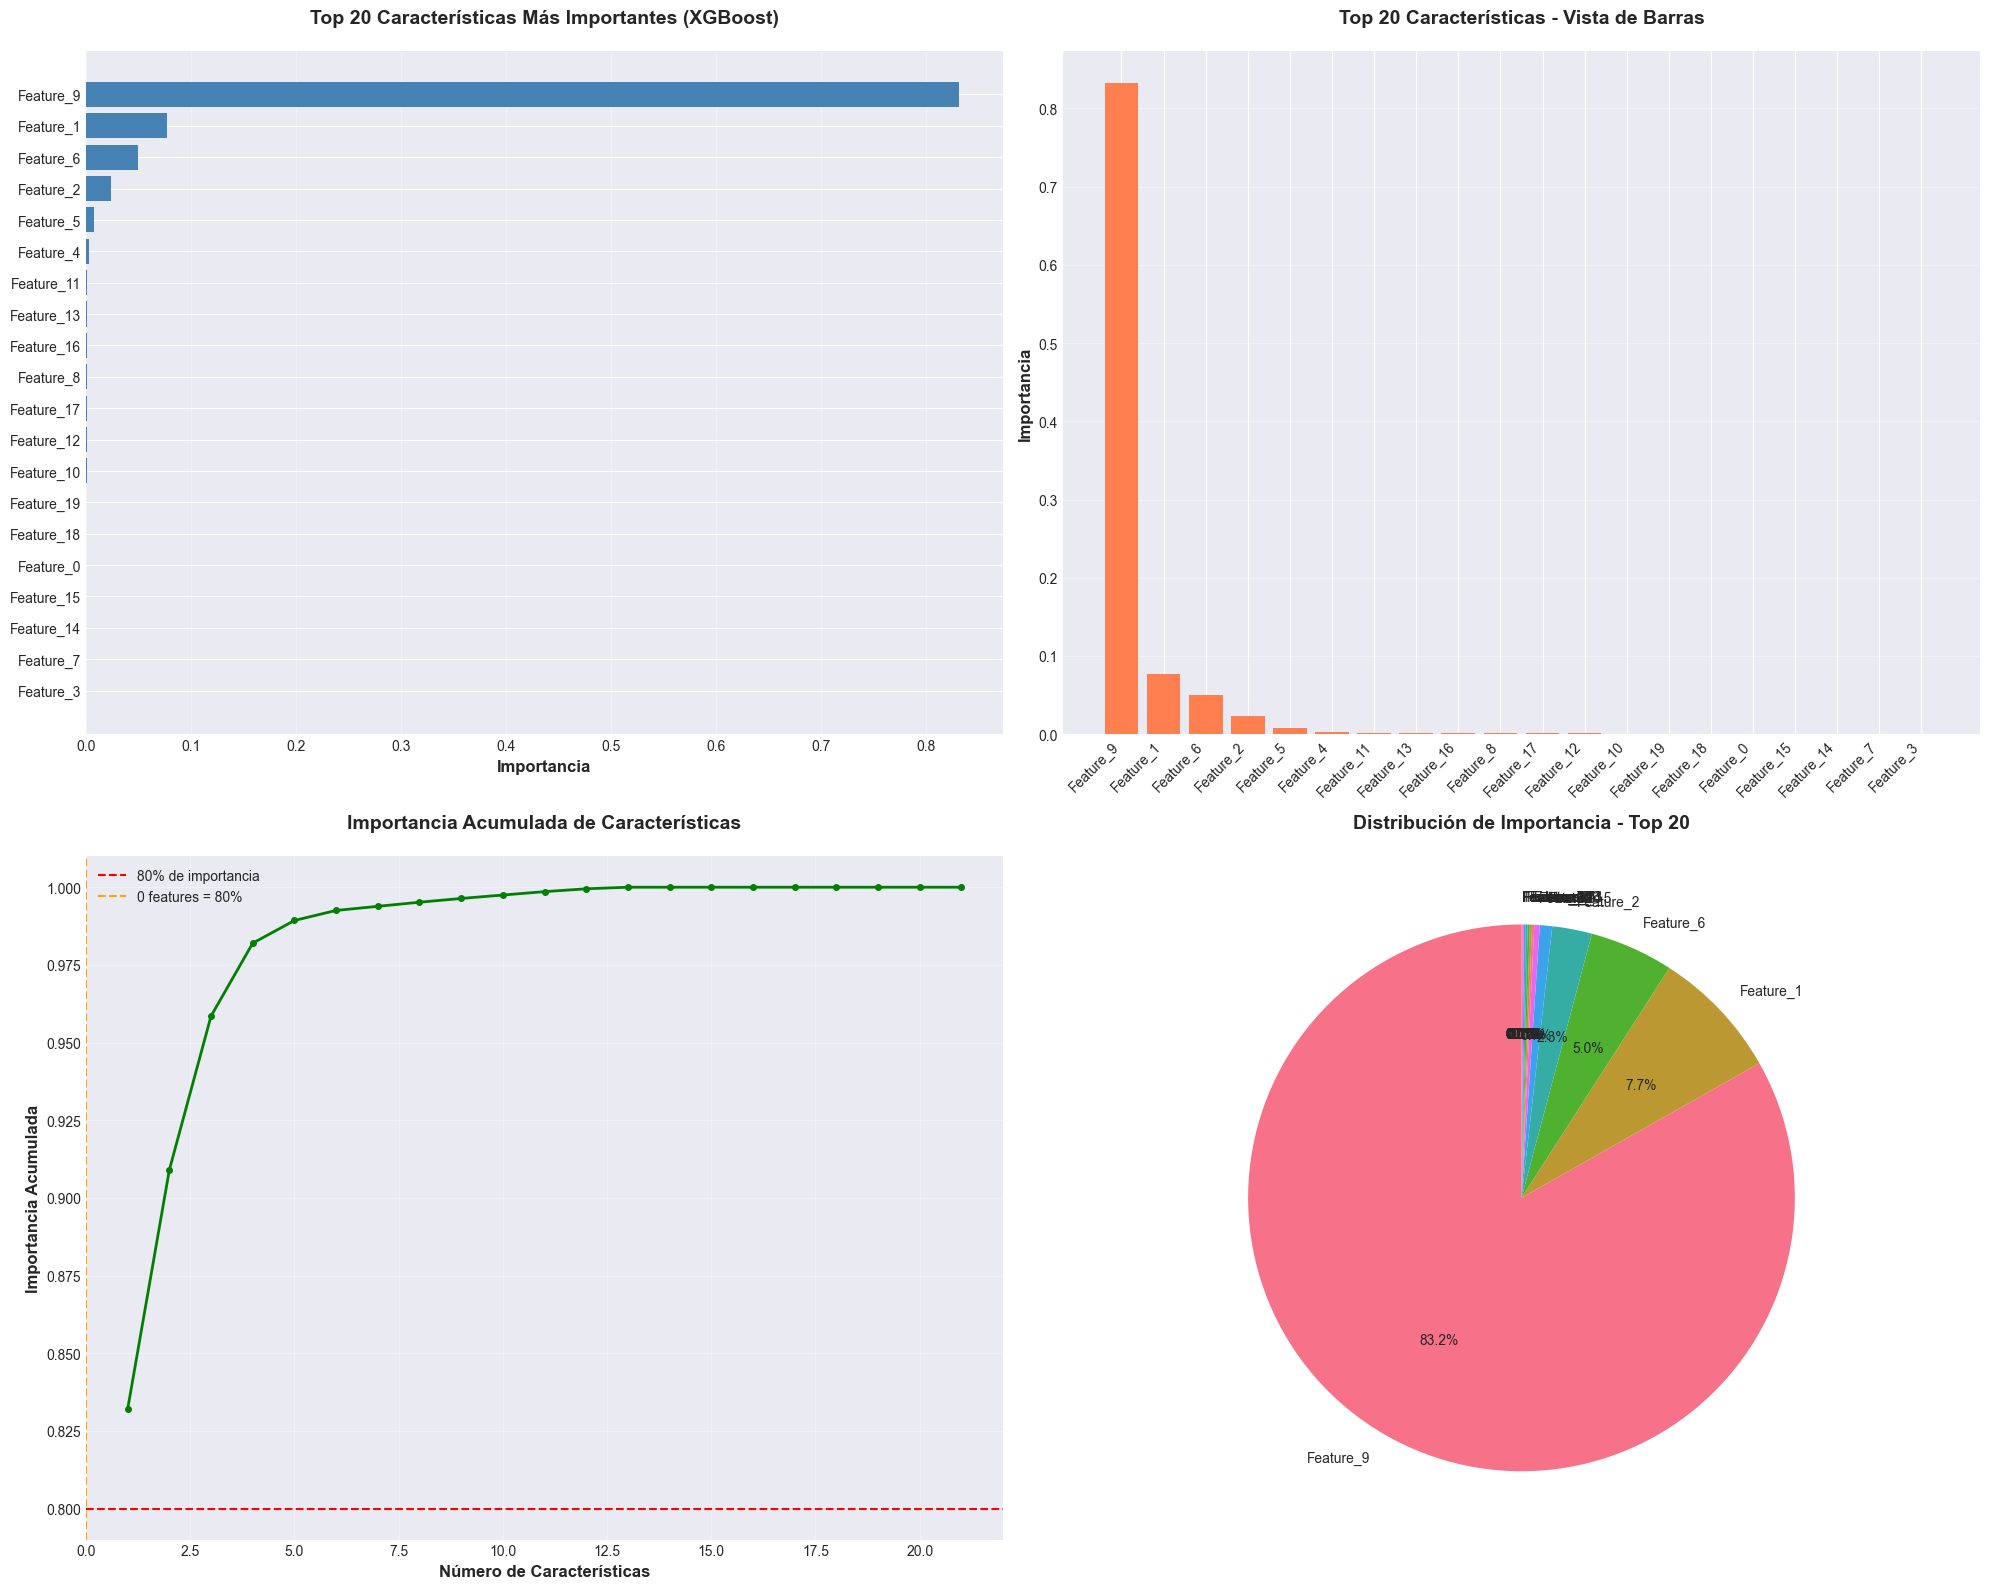


Número de características que explican el 80% de la importancia: 0


Características clave (top 0):


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

top_n = 20
df_top = df_importancia.head(top_n)

axes[0, 0].barh(range(len(df_top)), df_top['Importance'].values, color='steelblue')
axes[0, 0].set_yticks(range(len(df_top)))
axes[0, 0].set_yticklabels(df_top['Feature'].values)
axes[0, 0].set_xlabel('Importancia', fontsize=12, fontweight='bold')
axes[0, 0].set_title(f'Top {top_n} Características Más Importantes (XGBoost)', 
                     fontsize=14, fontweight='bold', pad=20)
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis='x', alpha=0.3)

axes[0, 1].bar(range(len(df_top)), df_top['Importance'].values, color='coral')
axes[0, 1].set_xticks(range(len(df_top)))
axes[0, 1].set_xticklabels(df_top['Feature'].values, rotation=45, ha='right')
axes[0, 1].set_ylabel('Importancia', fontsize=12, fontweight='bold')
axes[0, 1].set_title(f'Top {top_n} Características - Vista de Barras', 
                     fontsize=14, fontweight='bold', pad=20)
axes[0, 1].grid(axis='y', alpha=0.3)

importancia_acumulada = df_importancia['Importance'].cumsum()
axes[1, 0].plot(range(1, len(importancia_acumulada) + 1), importancia_acumulada.values, 
                marker='o', linewidth=2, markersize=4, color='green')
axes[1, 0].axhline(y=0.8, color='r', linestyle='--', label='80% de importancia')
axes[1, 0].set_xlabel('Número de Características', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Importancia Acumulada', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Importancia Acumulada de Características', 
                     fontsize=14, fontweight='bold', pad=20)
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

n_features_80 = len(importancia_acumulada[importancia_acumulada <= 0.8])
axes[1, 0].axvline(x=n_features_80, color='orange', linestyle='--', 
                   label=f'{n_features_80} features = 80%')
axes[1, 0].legend()

axes[1, 1].pie(df_top['Importance'].values, labels=df_top['Feature'].values, 
               autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title(f'Distribución de Importancia - Top {top_n}', 
                     fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
ruta_grafica = os.path.join(output_dir, 'importancia_caracteristicas.png')
plt.savefig(ruta_grafica, dpi=300, bbox_inches='tight')
print(f'✓ Gráfica de importancia guardada en: {ruta_grafica}', flush=True)
plt.show()

print(f'\nNúmero de características que explican el 80% de la importancia: {n_features_80}', flush=True)
print(f'Características clave (top {n_features_80}):', flush=True)
for i, row in df_importancia.head(n_features_80).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.6f}", flush=True)


### 11.2: Visualización de Árboles de Decisión



Visualizando árboles de decisión individuales...


⚠ No se pudieron visualizar los árboles con plot_tree: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH


Intentando método alternativo...


✓ Árbol 1 guardado en formato DOT: resultados/arbol_decision_1.dot


✓ Árbol 2 guardado en formato DOT: resultados/arbol_decision_2.dot


✓ Árbol 3 guardado en formato DOT: resultados/arbol_decision_3.dot


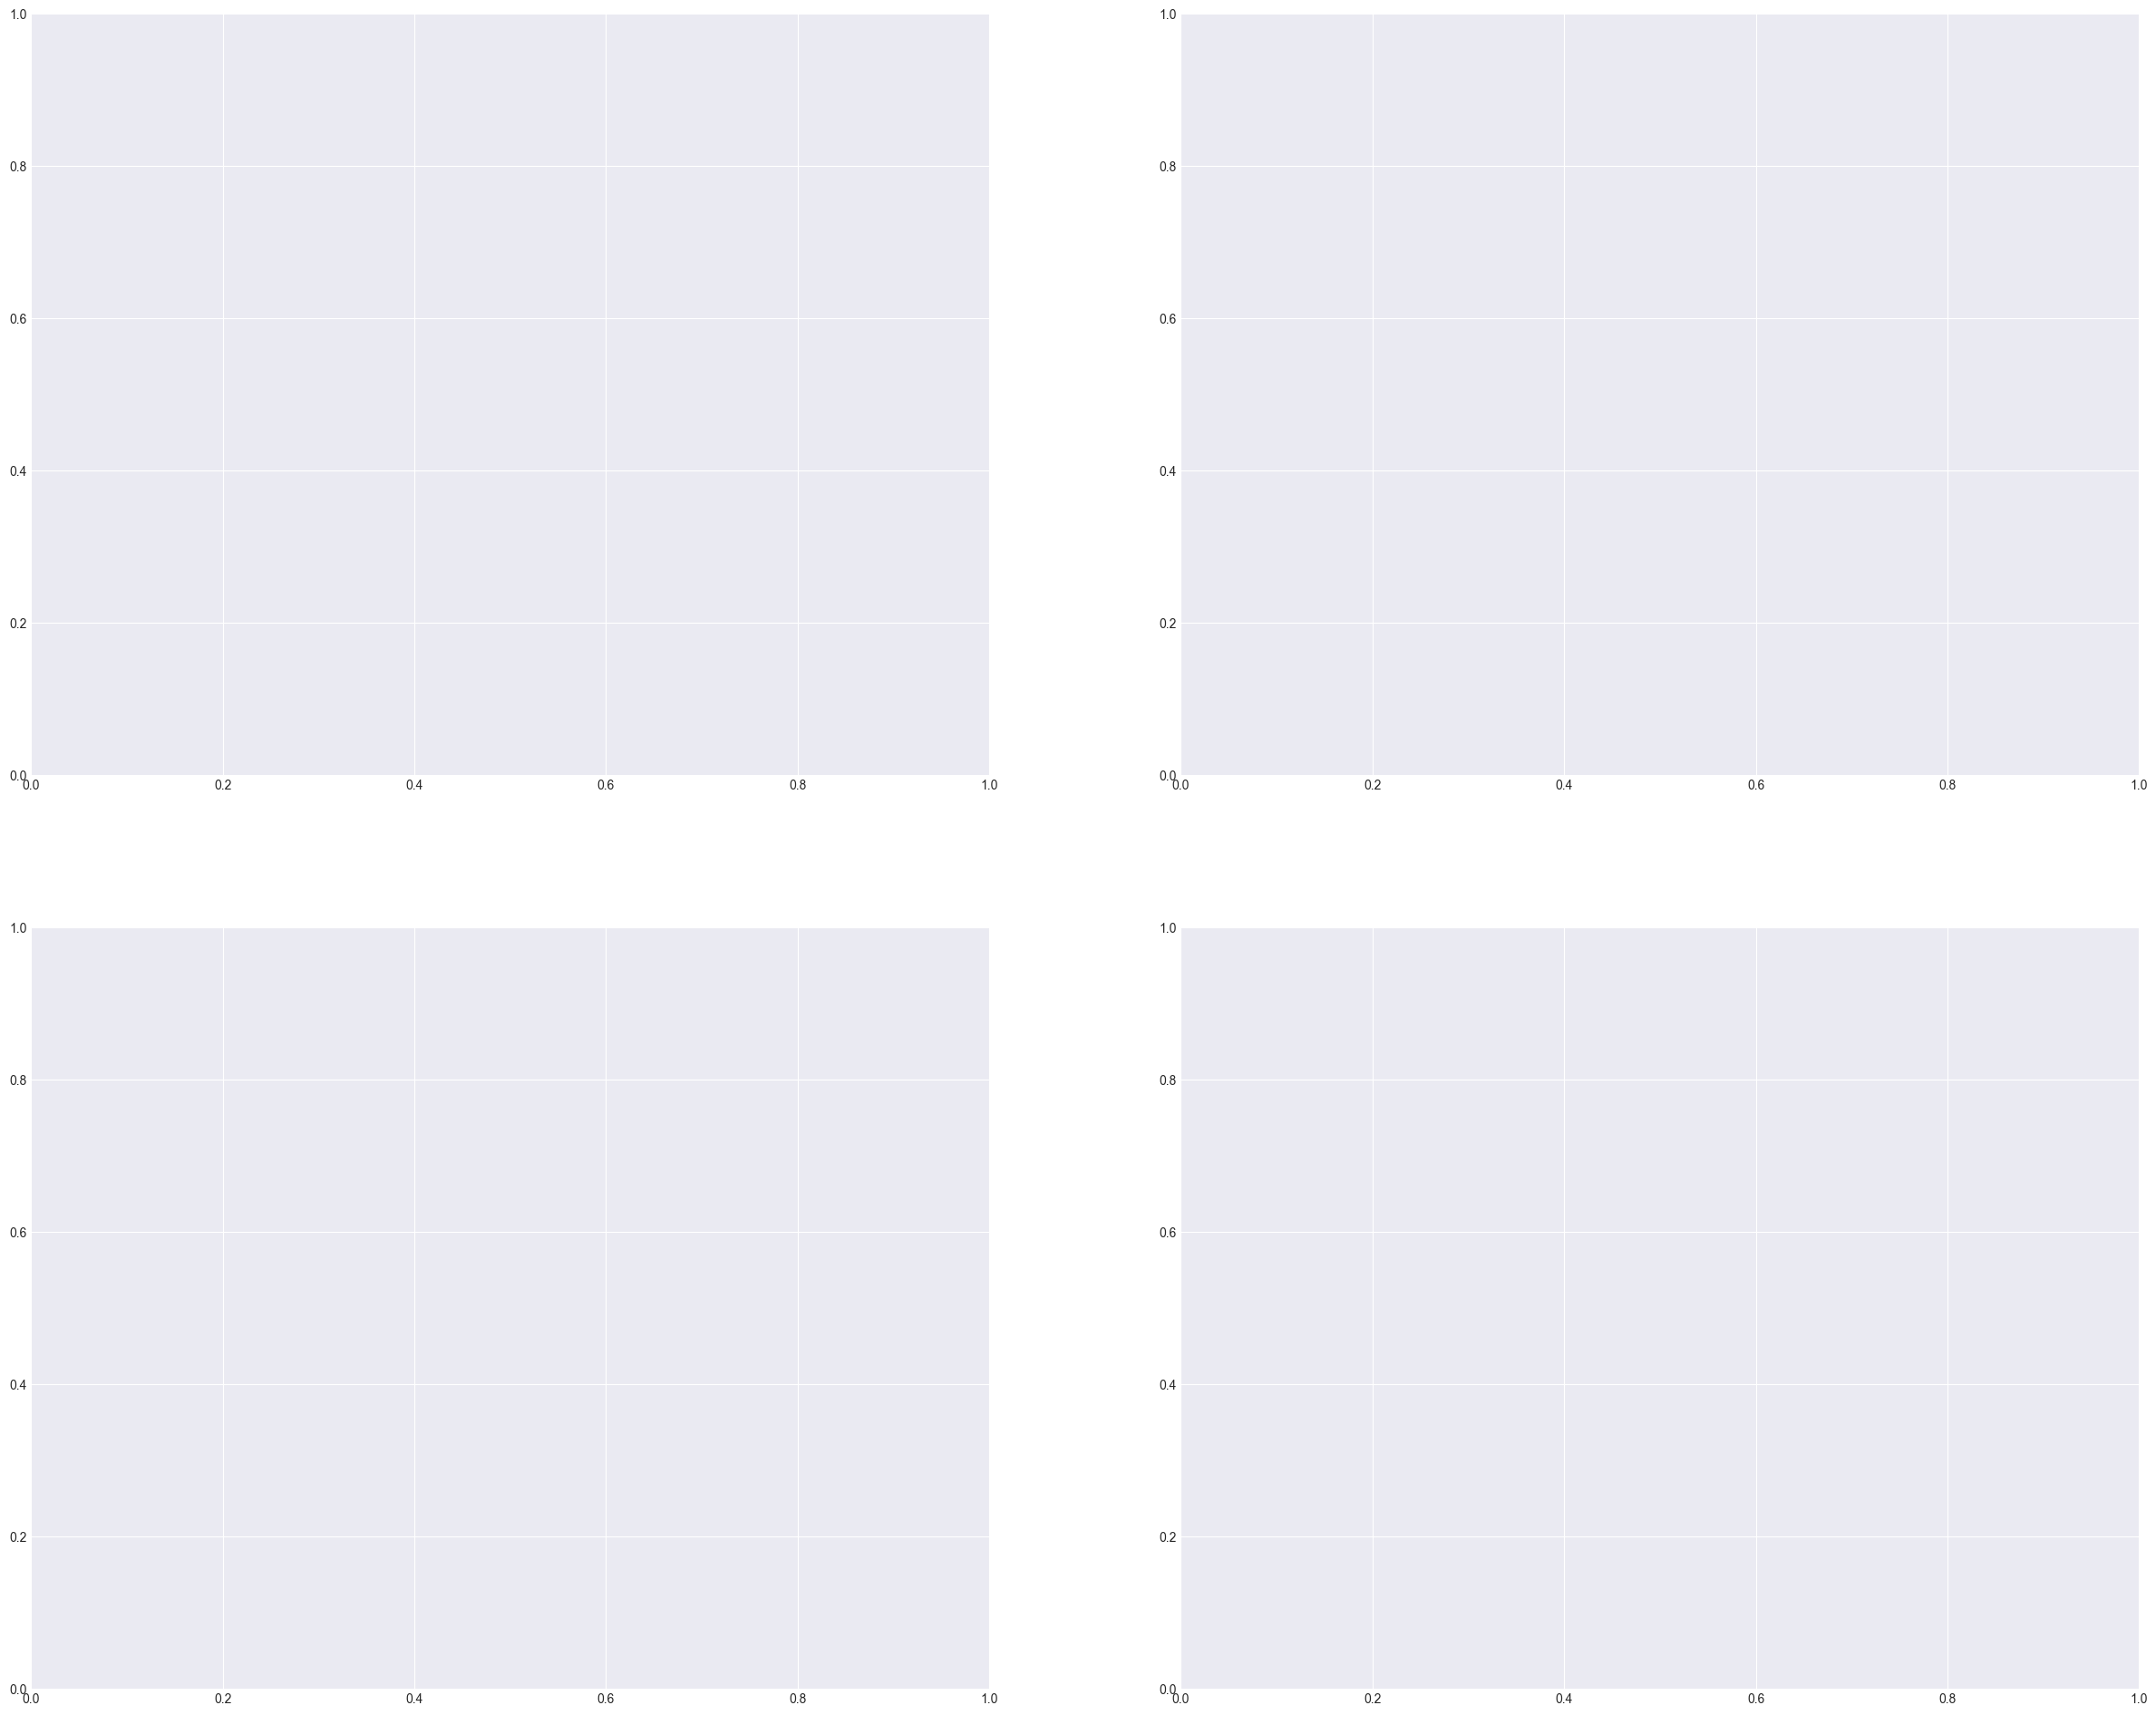

In [18]:
print('\nVisualizando árboles de decisión individuales...', flush=True)

try:
    fig, axes = plt.subplots(2, 2, figsize=(30, 24))
    axes = axes.flatten()
    
    for i, ax in enumerate(axes[:4]):
        plot_tree(xgb_optimizado, num_trees=i, ax=ax, rankdir='LR')
        ax.set_title(f'Árbol de Decisión #{i+1} (XGBoost)', fontsize=12, fontweight='bold', pad=10)
    
    plt.tight_layout()
    ruta_arboles = os.path.join(output_dir, 'arboles_decision_xgb.png')
    plt.savefig(ruta_arboles, dpi=300, bbox_inches='tight')
    print(f'✓ Árboles de decisión guardados en: {ruta_arboles}', flush=True)
    plt.show()
    
except Exception as e:
    print(f'⚠ No se pudieron visualizar los árboles con plot_tree: {e}', flush=True)
    print('Intentando método alternativo...', flush=True)
    
    try:
        from xgboost import to_graphviz
        
        for i in range(min(3, xgb_optimizado.n_estimators)):
            graph = to_graphviz(xgb_optimizado, num_trees=i)
            ruta_arbol = os.path.join(output_dir, f'arbol_decision_{i+1}.dot')
            graph.save(ruta_arbol)
            print(f'✓ Árbol {i+1} guardado en formato DOT: {ruta_arbol}', flush=True)
    except Exception as e2:
        print(f'⚠ Método alternativo también falló: {e2}', flush=True)
        print('Los árboles están disponibles en el modelo pero requieren herramientas adicionales para visualización.', flush=True)


### 11.3: Matriz de Confusión y Métricas



MÉTRICAS DEL MODELO XGBOOST
Accuracy:  0.9894
Precision: 0.9650
Recall:    0.9803
F1-Score:  0.9726
ROC-AUC:   0.9990



✓ Matriz de confusión guardada en: resultados/matriz_confusion_xgb.png


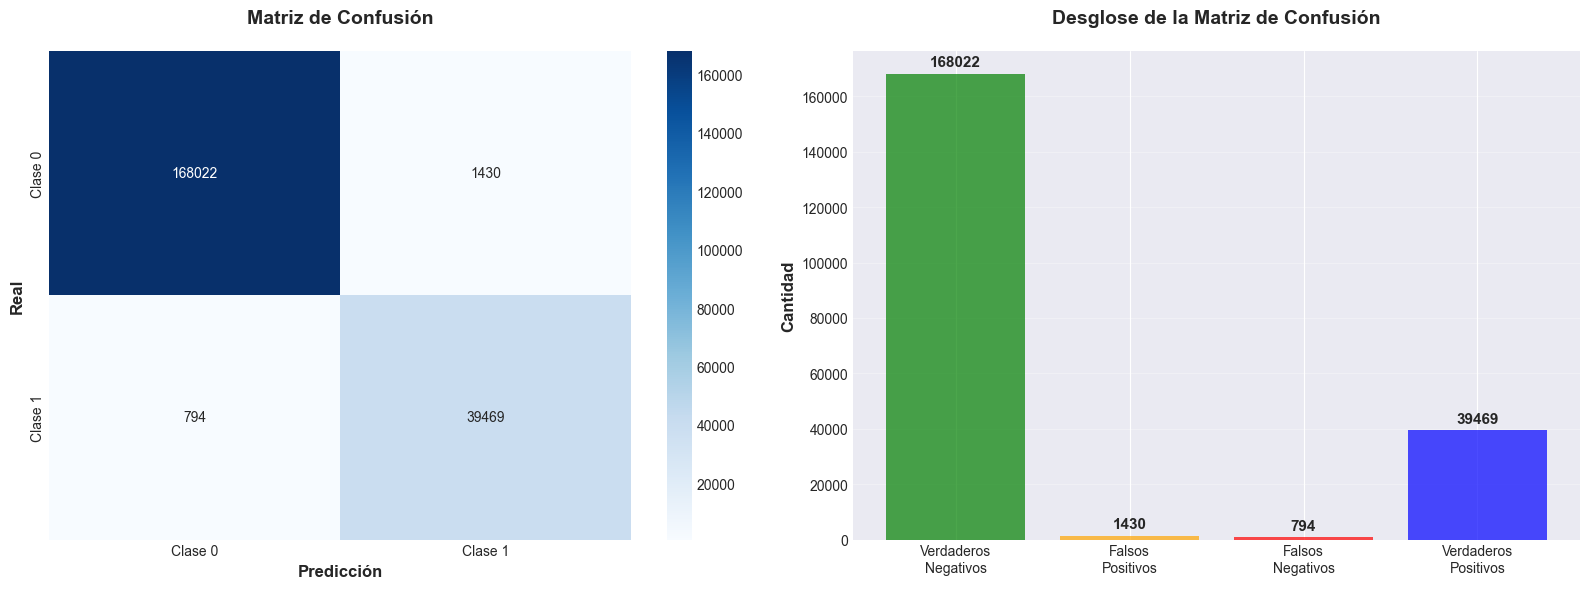

✓ Reporte de clasificación guardado en CSV


In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

cm = confusion_matrix(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)
roc_auc = roc_auc_score(y_test, y_pred_proba_xgb)

print('\n' + '=' * 80)
print('MÉTRICAS DEL MODELO XGBOOST')
print('=' * 80)
print(f'Accuracy:  {accuracy_xgb:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')
print(f'ROC-AUC:   {roc_auc:.4f}')
print('=' * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Clase 0', 'Clase 1'], 
            yticklabels=['Clase 0', 'Clase 1'])
axes[0].set_xlabel('Predicción', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Real', fontsize=12, fontweight='bold')
axes[0].set_title('Matriz de Confusión', fontsize=14, fontweight='bold', pad=20)

tn, fp, fn, tp = cm.ravel()
axes[1].bar(['Verdaderos\nNegativos', 'Falsos\nPositivos', 'Falsos\nNegativos', 'Verdaderos\nPositivos'],
            [tn, fp, fn, tp], color=['green', 'orange', 'red', 'blue'], alpha=0.7)
axes[1].set_ylabel('Cantidad', fontsize=12, fontweight='bold')
axes[1].set_title('Desglose de la Matriz de Confusión', fontsize=14, fontweight='bold', pad=20)
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate([tn, fp, fn, tp]):
    axes[1].text(i, v + max([tn, fp, fn, tp]) * 0.01, str(v), 
                ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
ruta_confusion = os.path.join(output_dir, 'matriz_confusion_xgb.png')
plt.savefig(ruta_confusion, dpi=300, bbox_inches='tight')
print(f'\n✓ Matriz de confusión guardada en: {ruta_confusion}', flush=True)
plt.show()

reporte = classification_report(y_test, y_pred_xgb, output_dict=True)
df_reporte = pd.DataFrame(reporte).transpose()
df_reporte.to_csv(os.path.join(output_dir, 'reporte_clasificacion_xgb.csv'))
print('✓ Reporte de clasificación guardado en CSV', flush=True)


### 11.4: Curvas ROC y Precision-Recall


✓ Curvas ROC y Precision-Recall guardadas en: resultados/curvas_roc_precision_recall.png


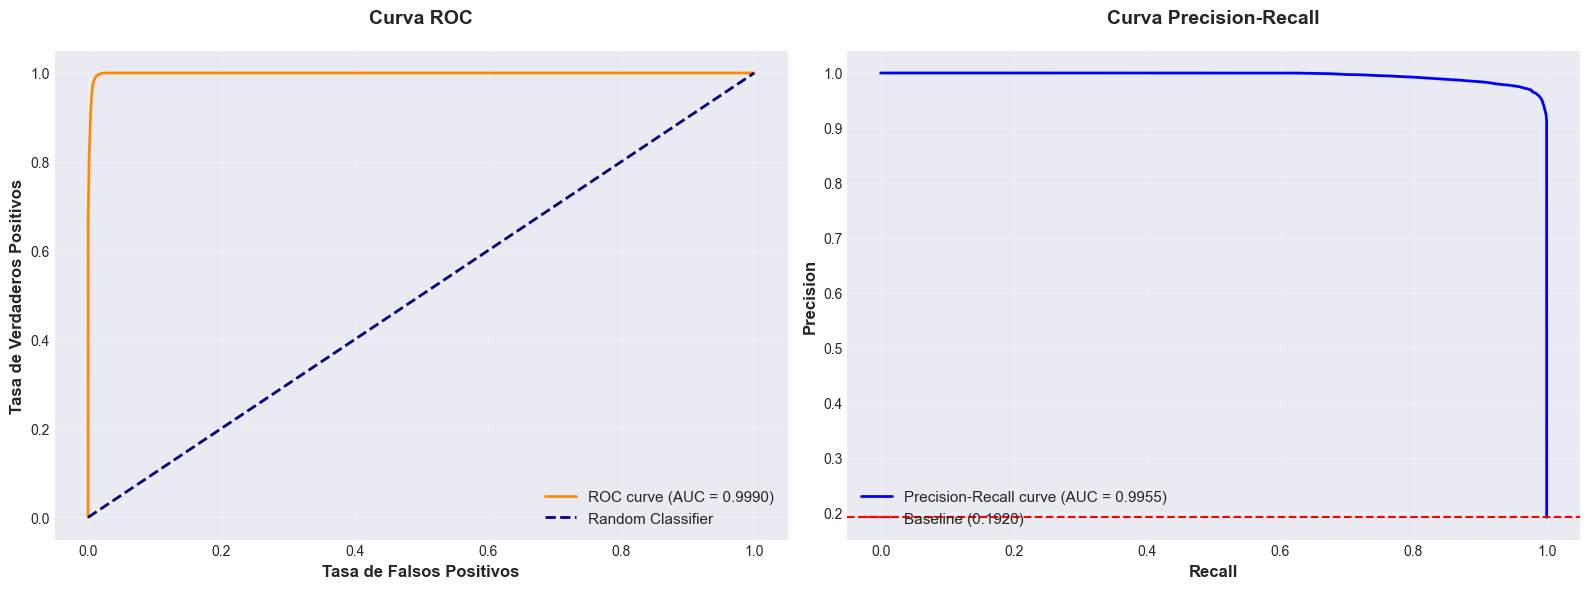


Área bajo la curva ROC: 0.9990


Área bajo la curva Precision-Recall: 0.9955


In [20]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_xgb)
roc_auc = auc(fpr, tpr)

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba_xgb)
pr_auc = auc(recall_curve, precision_curve)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0].set_xlabel('Tasa de Falsos Positivos', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Tasa de Verdaderos Positivos', fontsize=12, fontweight='bold')
axes[0].set_title('Curva ROC', fontsize=14, fontweight='bold', pad=20)
axes[0].legend(loc="lower right", fontsize=11)
axes[0].grid(alpha=0.3)

axes[1].plot(recall_curve, precision_curve, color='blue', lw=2,
             label=f'Precision-Recall curve (AUC = {pr_auc:.4f})')
baseline = len(y_test[y_test==1]) / len(y_test)
axes[1].axhline(y=baseline, color='r', linestyle='--', 
                label=f'Baseline ({baseline:.4f})')
axes[1].set_xlabel('Recall', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Precision', fontsize=12, fontweight='bold')
axes[1].set_title('Curva Precision-Recall', fontsize=14, fontweight='bold', pad=20)
axes[1].legend(loc="lower left", fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
ruta_curvas = os.path.join(output_dir, 'curvas_roc_precision_recall.png')
plt.savefig(ruta_curvas, dpi=300, bbox_inches='tight')
print(f'✓ Curvas ROC y Precision-Recall guardadas en: {ruta_curvas}', flush=True)
plt.show()

print(f'\nÁrea bajo la curva ROC: {roc_auc:.4f}', flush=True)
print(f'Área bajo la curva Precision-Recall: {pr_auc:.4f}', flush=True)


### 11.5: Resumen de Variables Clave


In [21]:
print('\n' + '=' * 80)
print('RESUMEN DE VARIABLES CLAVE PARA EL MODELO')
print('=' * 80)

n_variables_clave = min(15, len(df_importancia))
variables_clave = df_importancia.head(n_variables_clave)

print(f'\nLas {n_variables_clave} variables más importantes son:\n', flush=True)
for idx, row in variables_clave.iterrows():
    porcentaje = (row['Importance'] / df_importancia['Importance'].sum()) * 100
    print(f"  {idx+1:2d}. {row['Feature']:20s} - Importancia: {row['Importance']:.6f} ({porcentaje:.2f}%)", flush=True)

importancia_total_top = variables_clave['Importance'].sum()
porcentaje_total = (importancia_total_top / df_importancia['Importance'].sum()) * 100
print(f'\nEstas {n_variables_clave} variables explican el {porcentaje_total:.2f}% de la importancia total.', flush=True)

resumen_variables = {
    'variables_clave': variables_clave['Feature'].tolist(),
    'importancia_total': float(importancia_total_top),
    'porcentaje_explicado': float(porcentaje_total),
    'total_variables': len(df_importancia),
    'variables_seleccionadas': n_variables_clave
}

ruta_resumen = os.path.join(output_dir, 'resumen_variables_clave.json')
with open(ruta_resumen, 'w', encoding='utf-8') as f:
    json.dump(resumen_variables, f, indent=2)

print(f'\n✓ Resumen de variables clave guardado en: {ruta_resumen}', flush=True)
print('\n✓ Paso 11 completado exitosamente', flush=True)



RESUMEN DE VARIABLES CLAVE PARA EL MODELO

Las 15 variables más importantes son:



  10. Feature_9            - Importancia: 0.832011 (83.20%)


   2. Feature_1            - Importancia: 0.076997 (7.70%)


   7. Feature_6            - Importancia: 0.049522 (4.95%)


   3. Feature_2            - Importancia: 0.023451 (2.35%)


...

  20. Feature_19           - Importancia: 0.000000 (0.00%)


  19. Feature_18           - Importancia: 0.000000 (0.00%)



Estas 15 variables explican el 100.00% de la importancia total.



✓ Resumen de variables clave guardado en: resultados/resumen_variables_clave.json



✓ Paso 11 completado exitosamente


## Paso 12: Visualización de Árboles de Decisión (Estructura)

Se generan imágenes de la estructura de los árboles de decisión:
- Intento 1: Árboles internos del modelo XGBoost (si hay soporte de Graphviz).
- Intento 2: Árbol surrogado (sklearn) entrenado sobre las variables más importantes, exportado como PNG.


Generando visualizaciones de árboles...


Nota: no fue posible visualizar árboles XGBoost directamente (failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH). Se usa árbol surrogado.


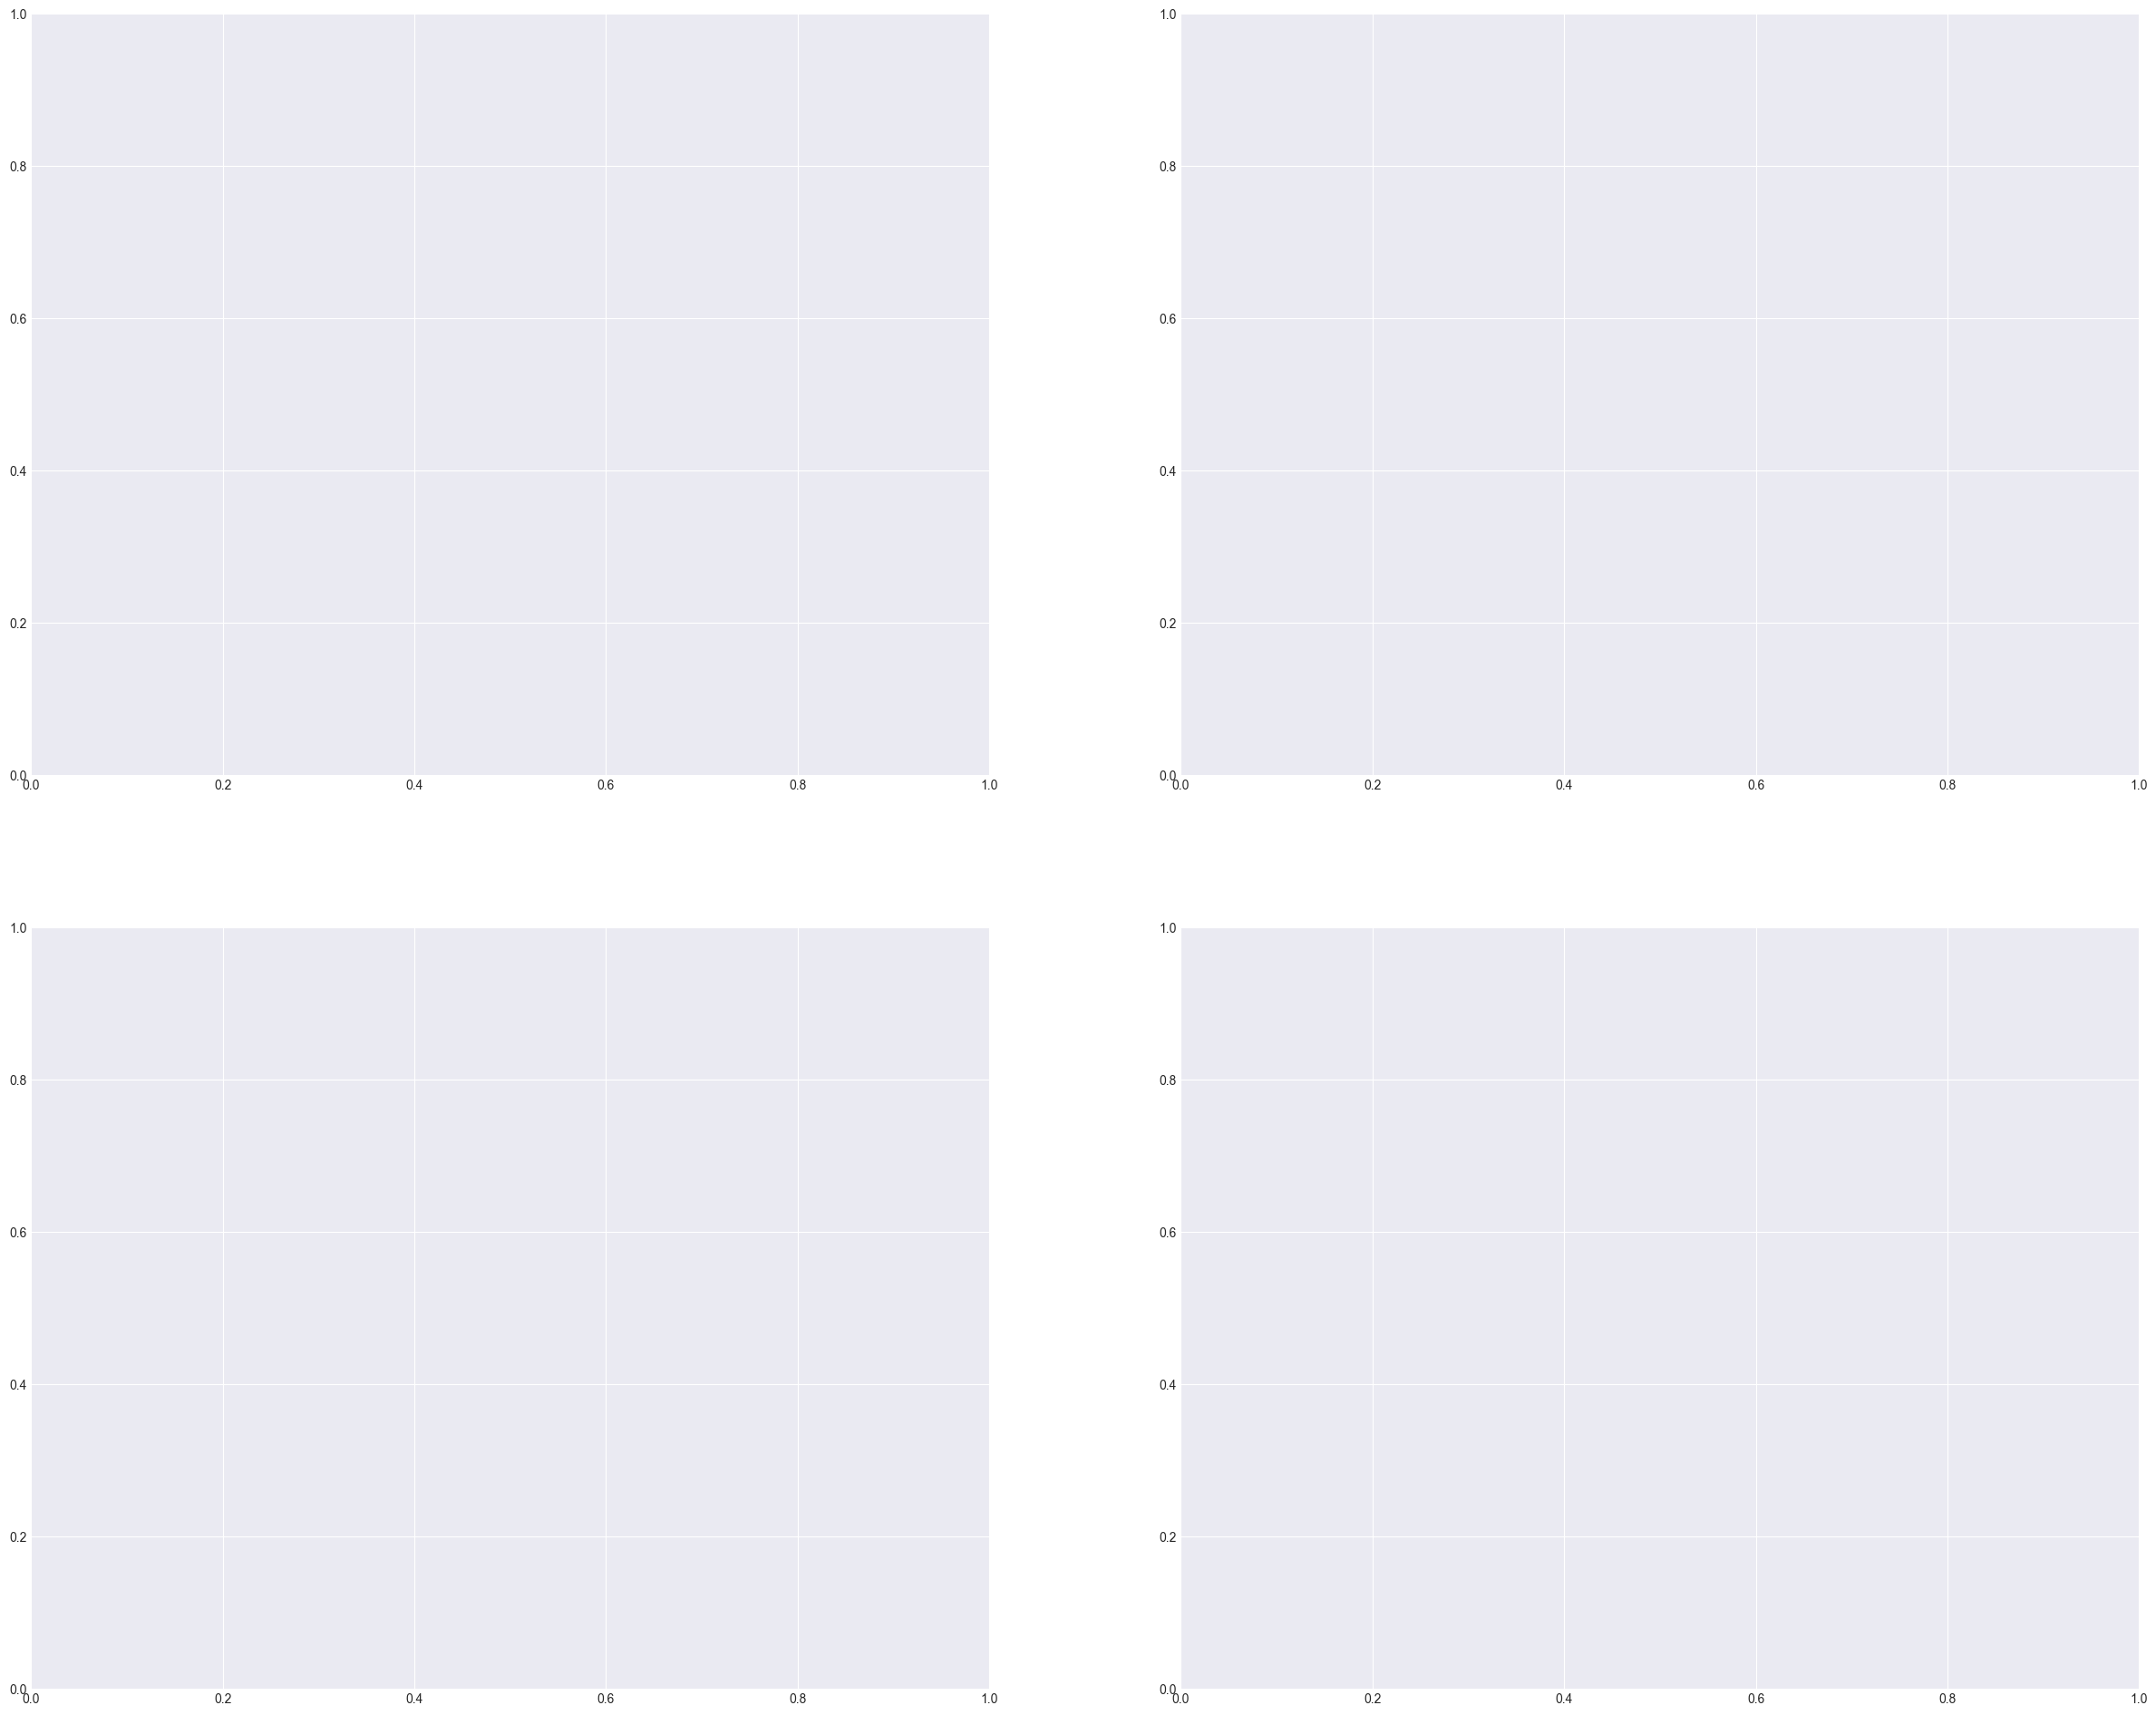

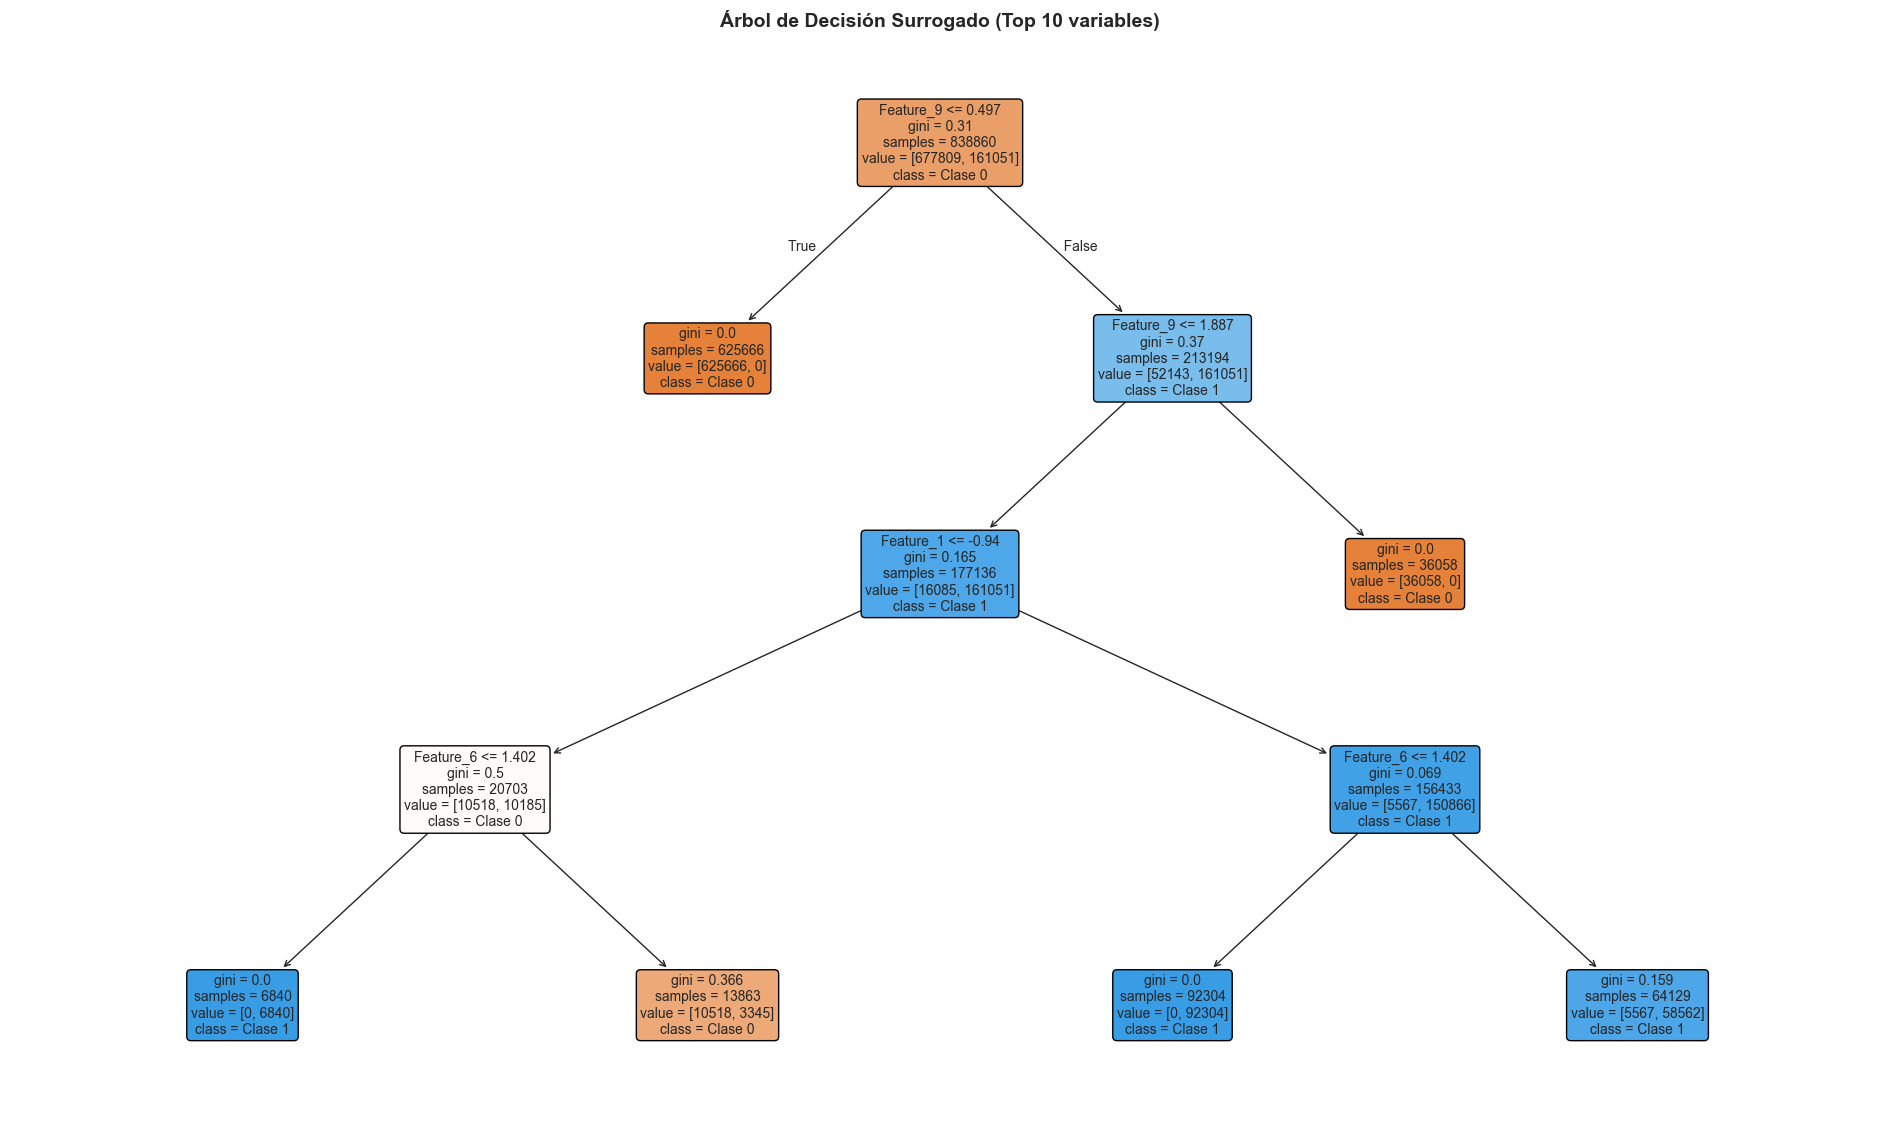

✓ Árbol surrogado guardado en: resultados/arbol_surrogado_top10.png


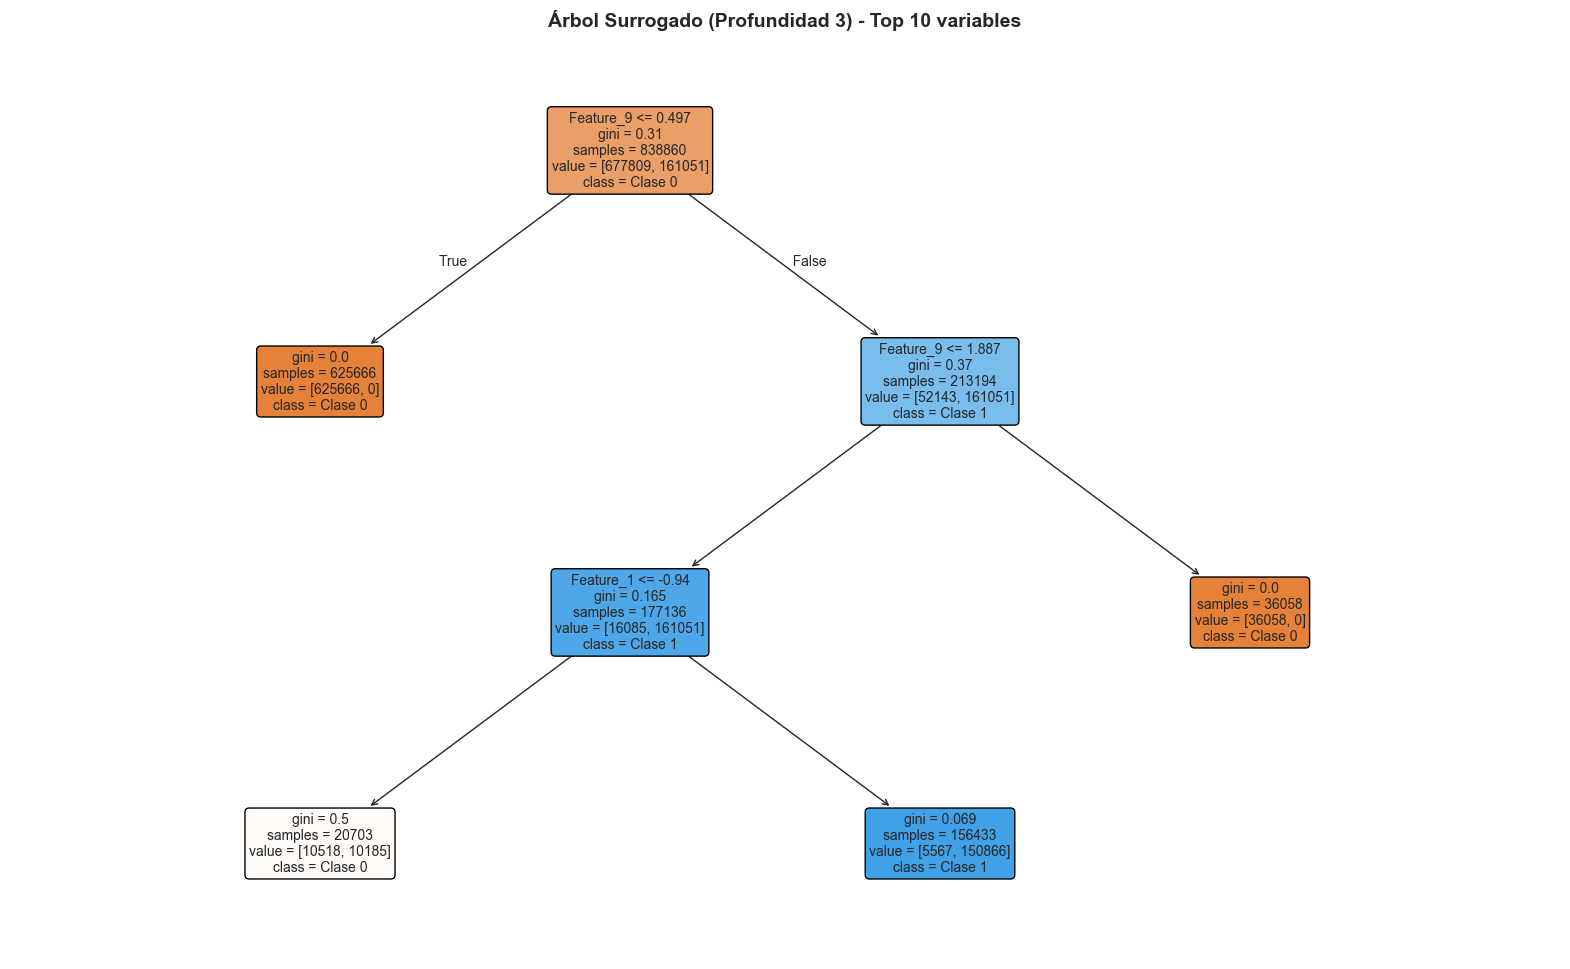

✓ Árbol surrogado (profundidad 3) guardado en: resultados/arbol_surrogado_top10_depth3.png


In [22]:
print('Generando visualizaciones de árboles...', flush=True)

# Asegurar df_importancia y nombres de features
ruta_importancias = os.path.join(output_dir, 'importancia_caracteristicas.csv')
if 'df_importancia' not in globals():
    if os.path.exists(ruta_importancias):
        df_importancia = pd.read_csv(ruta_importancias)
    else:
        raise RuntimeError('No se encuentra df_importancia. Ejecute el Paso 11 primero.')

# Intento 1: Visualizar árboles de XGBoost directamente (requiere Graphviz)
exitos_xgb = False
try:
    from xgboost import plot_tree as xgb_plot_tree
    fig, axes = plt.subplots(2, 2, figsize=(30, 24))
    axes = axes.flatten()
    for i, ax in enumerate(axes[:4]):
        xgb_plot_tree(xgb_optimizado, num_trees=i, ax=ax, rankdir='LR')
        ax.set_title(f'Estructura - Árbol XGBoost #{i+1}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    ruta_arboles_xgb = os.path.join(output_dir, 'estructura_arboles_xgb.png')
    plt.savefig(ruta_arboles_xgb, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'✓ Estructuras XGBoost guardadas en: {ruta_arboles_xgb}', flush=True)
    exitos_xgb = True
except Exception as e:
    print(f'Nota: no fue posible visualizar árboles XGBoost directamente ({e}). Se usa árbol surrogado.', flush=True)

# Intento 2: Árbol surrogado con sklearn sobre top-N variables más importantes
from sklearn.tree import DecisionTreeClassifier, plot_tree as sk_plot_tree

# Tomar top-N variables
top_n = 10
indices_top = []
for feat in df_importancia['Feature'].head(top_n).tolist():
    # 'Feature_i' -> i
    try:
        idx = int(feat.split('_')[1])
    except Exception:
        idx = 0
    indices_top.append(idx)

# Preparar subconjunto de datos (usar escalados por consistencia)
X_train_top = X_train_scaled[:, indices_top]
X_test_top = X_test_scaled[:, indices_top]

arbol_surrogado = DecisionTreeClassifier(max_depth=4, random_state=42)
arbol_surrogado.fit(X_train_top, y_train)

fig = plt.figure(figsize=(24, 14))
sk_plot_tree(
    arbol_surrogado,
    feature_names=[df_importancia['Feature'].iloc[i] for i in range(top_n)],
    class_names=['Clase 0', 'Clase 1'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Árbol de Decisión Surrogado (Top 10 variables)', fontsize=14, fontweight='bold')
ruta_arbol_surrogado = os.path.join(output_dir, 'arbol_surrogado_top10.png')
plt.savefig(ruta_arbol_surrogado, dpi=300, bbox_inches='tight')
plt.show()
print(f'✓ Árbol surrogado guardado en: {ruta_arbol_surrogado}', flush=True)

# Exportar también una versión más pequeña (profundidad 3) para lectura rápida
arbol_surrogado_peq = DecisionTreeClassifier(max_depth=3, random_state=42)
arbol_surrogado_peq.fit(X_train_top, y_train)
fig = plt.figure(figsize=(20, 12))
sk_plot_tree(
    arbol_surrogado_peq,
    feature_names=[df_importancia['Feature'].iloc[i] for i in range(top_n)],
    class_names=['Clase 0', 'Clase 1'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Árbol Surrogado (Profundidad 3) - Top 10 variables', fontsize=14, fontweight='bold')
ruta_arbol_surrogado_peq = os.path.join(output_dir, 'arbol_surrogado_top10_depth3.png')
plt.savefig(ruta_arbol_surrogado_peq, dpi=300, bbox_inches='tight')
plt.show()
print(f'✓ Árbol surrogado (profundidad 3) guardado en: {ruta_arbol_surrogado_peq}', flush=True)


### 12.1: Visualizaciones EDA Completas


VISUALIZACIONES EDA COMPLETAS

Cargando datos originales para EDA...


✓ Datos cargados: 1048575 filas, 36 columnas



✓ Visualizaciones EDA completas guardadas en: resultados/eda_visualizaciones_completas.png


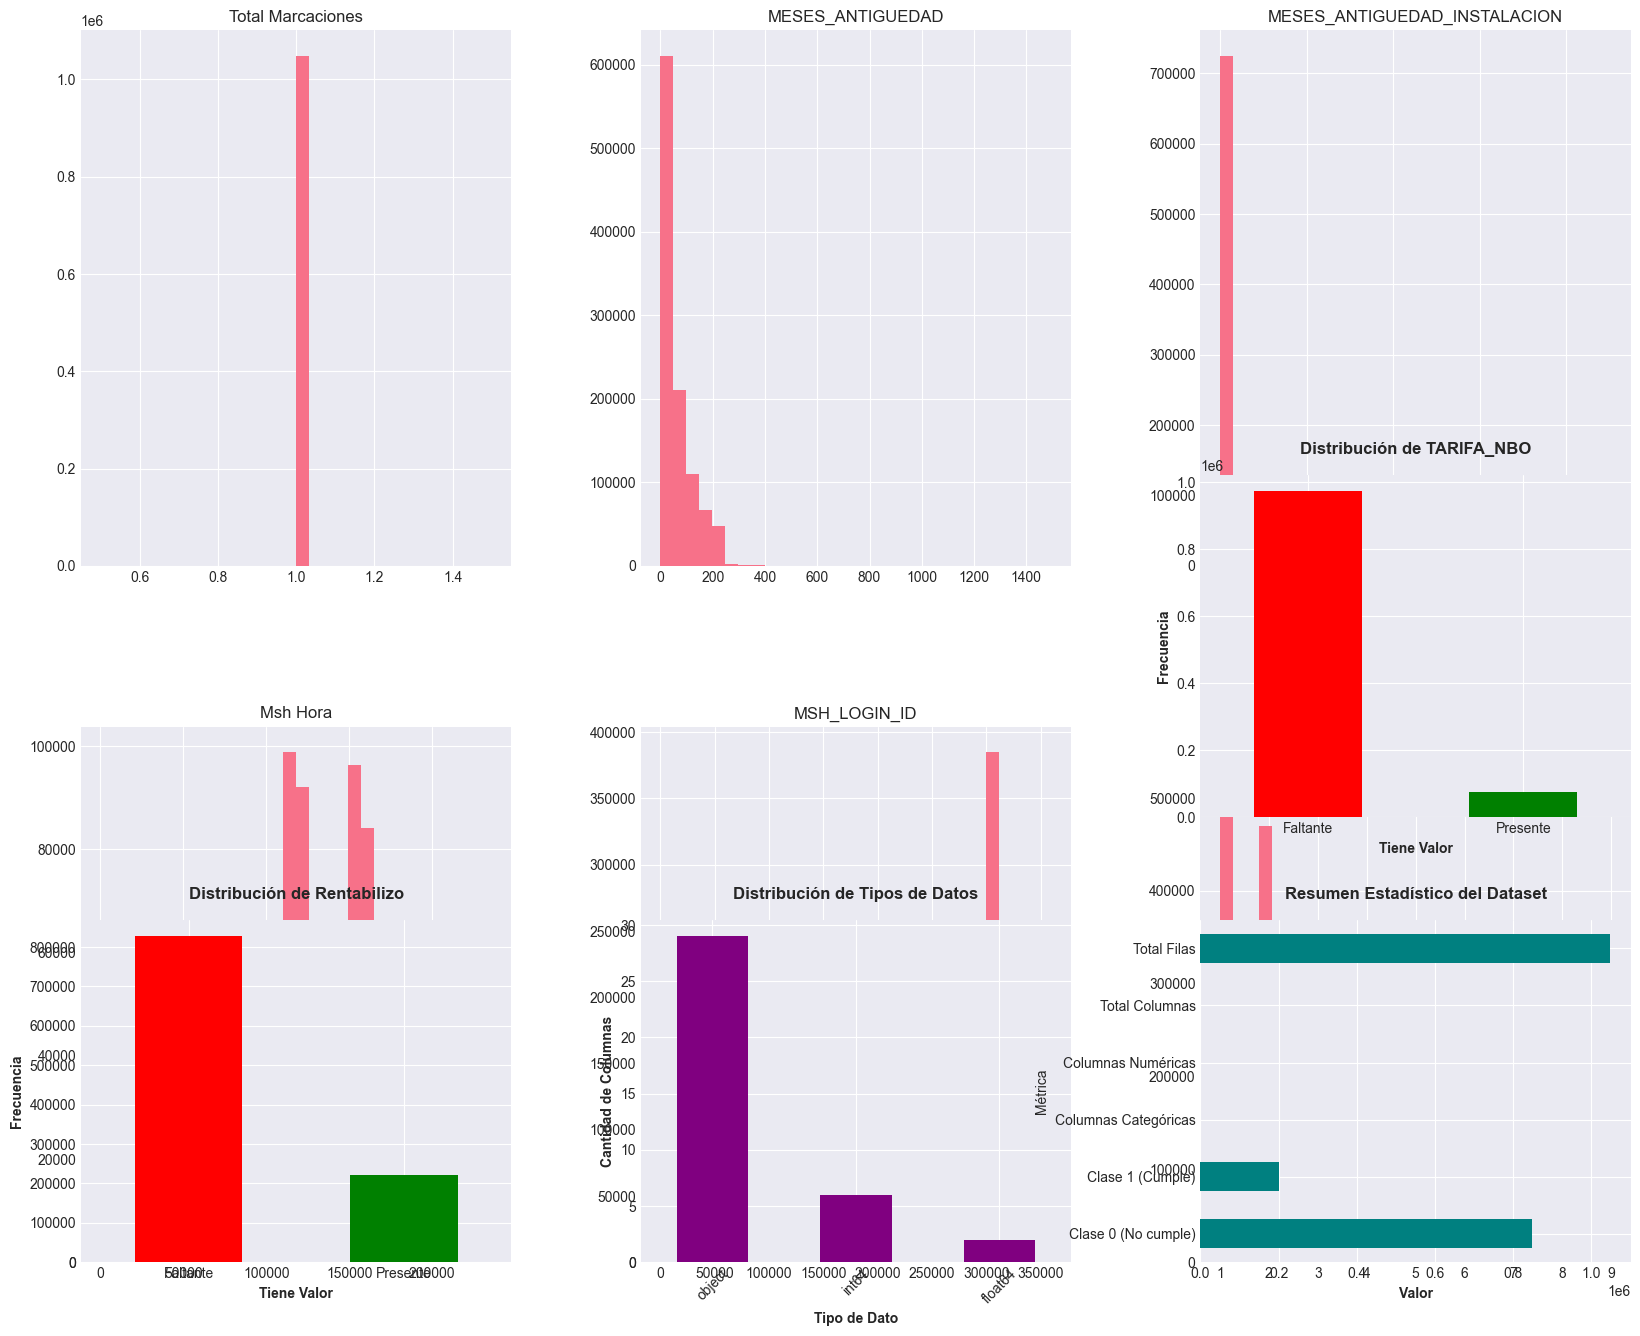


✓ Visualizaciones EDA completadas


In [23]:
print('=' * 80)
print('VISUALIZACIONES EDA COMPLETAS')
print('=' * 80)

print('\nCargando datos originales para EDA...', flush=True)

archivo = 'Total_Mes_Act_Datos completos CORREGIDO.csv'
df_eda = pd.read_csv(
    archivo, 
    low_memory=False,
    encoding='utf-8',
    on_bad_lines='skip',
    sep=';',
    quotechar='"'
)

print(f'✓ Datos cargados: {df_eda.shape[0]} filas, {df_eda.shape[1]} columnas', flush=True)

columna_tarifa = 'TARIFA_NBO'
columna_rentabilizacion = 'Rentabilizo'

df_eda['variable_objetivo'] = np.where(
    (df_eda[columna_tarifa].notna()) & 
    (df_eda[columna_rentabilizacion].notna()),
    1,
    0
)

fig = plt.figure(figsize=(20, 16))

distribucion = df_eda['variable_objetivo'].value_counts()
ax1 = plt.subplot(3, 3, 1)
distribucion.plot(kind='bar', color=['coral', 'steelblue'], ax=ax1)
ax1.set_title('Distribución de Variable Objetivo', fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel('Clase (0=No cumple, 1=Cumple)', fontsize=10, fontweight='bold')
ax1.set_ylabel('Frecuencia', fontsize=10, fontweight='bold')
ax1.set_xticklabels(['No cumple', 'Cumple'], rotation=0)
for i, v in enumerate(distribucion.values):
    ax1.text(i, v + max(distribucion.values) * 0.01, f'{v:,}', 
            ha='center', va='bottom', fontweight='bold')

ax2 = plt.subplot(3, 3, 2)
distribucion.plot(kind='pie', autopct='%1.1f%%', colors=['coral', 'steelblue'], ax=ax2, startangle=90)
ax2.set_title('Distribución Porcentual', fontsize=12, fontweight='bold', pad=15)
ax2.set_ylabel('')

missing = df_eda.isnull().sum()
missing_pct = (missing / len(df_eda)) * 100
missing_df = pd.DataFrame({
    'Valores_Faltantes': missing,
    'Porcentaje': missing_pct
})
missing_df = missing_df[missing_df['Valores_Faltantes'] > 0].sort_values('Porcentaje', ascending=False).head(15)

ax3 = plt.subplot(3, 3, 3)
missing_df['Porcentaje'].plot(kind='barh', color='orange', ax=ax3)
ax3.set_title('Top 15 Columnas con Valores Faltantes', fontsize=12, fontweight='bold', pad=15)
ax3.set_xlabel('Porcentaje de Valores Faltantes', fontsize=10, fontweight='bold')
ax3.invert_yaxis()

columnas_numericas = df_eda.select_dtypes(include=[np.number]).columns.tolist()
if len(columnas_numericas) > 0:
    df_numericas = df_eda[columnas_numericas[:6]].copy()
    
    ax4 = plt.subplot(3, 3, 4)
    df_numericas.boxplot(ax=ax4, rot=45)
    ax4.set_title('Distribución de Variables Numéricas (Top 6)', fontsize=12, fontweight='bold', pad=15)
    ax4.set_ylabel('Valor', fontsize=10, fontweight='bold')
    
    ax5 = plt.subplot(3, 3, 5)
    df_numericas.hist(bins=30, ax=ax5, layout=(2, 3), figsize=(15, 10))
    ax5.set_title('Histogramas de Variables Numéricas', fontsize=12, fontweight='bold', pad=15)

if columna_tarifa in df_eda.columns:
    ax6 = plt.subplot(3, 3, 6)
    df_eda[columna_tarifa].notna().value_counts().plot(kind='bar', color=['red', 'green'], ax=ax6)
    ax6.set_title(f'Distribución de {columna_tarifa}', fontsize=12, fontweight='bold', pad=15)
    ax6.set_xlabel('Tiene Valor', fontsize=10, fontweight='bold')
    ax6.set_ylabel('Frecuencia', fontsize=10, fontweight='bold')
    ax6.set_xticklabels(['Faltante', 'Presente'], rotation=0)

if columna_rentabilizacion in df_eda.columns:
    ax7 = plt.subplot(3, 3, 7)
    df_eda[columna_rentabilizacion].notna().value_counts().plot(kind='bar', color=['red', 'green'], ax=ax7)
    ax7.set_title(f'Distribución de {columna_rentabilizacion}', fontsize=12, fontweight='bold', pad=15)
    ax7.set_xlabel('Tiene Valor', fontsize=10, fontweight='bold')
    ax7.set_ylabel('Frecuencia', fontsize=10, fontweight='bold')
    ax7.set_xticklabels(['Faltante', 'Presente'], rotation=0)

tipos_datos = df_eda.dtypes.value_counts()
ax8 = plt.subplot(3, 3, 8)
tipos_datos.plot(kind='bar', color='purple', ax=ax8)
ax8.set_title('Distribución de Tipos de Datos', fontsize=12, fontweight='bold', pad=15)
ax8.set_xlabel('Tipo de Dato', fontsize=10, fontweight='bold')
ax8.set_ylabel('Cantidad de Columnas', fontsize=10, fontweight='bold')
ax8.tick_params(axis='x', rotation=45)

ax9 = plt.subplot(3, 3, 9)
resumen_stats = {
    'Total Filas': len(df_eda),
    'Total Columnas': len(df_eda.columns),
    'Columnas Numéricas': len(columnas_numericas),
    'Columnas Categóricas': len(df_eda.columns) - len(columnas_numericas),
    'Clase 1 (Cumple)': int(distribucion.get(1, 0)),
    'Clase 0 (No cumple)': int(distribucion.get(0, 0))
}
stats_df = pd.DataFrame(list(resumen_stats.items()), columns=['Métrica', 'Valor'])
stats_df.set_index('Métrica')['Valor'].plot(kind='barh', color='teal', ax=ax9)
ax9.set_title('Resumen Estadístico del Dataset', fontsize=12, fontweight='bold', pad=15)
ax9.set_xlabel('Valor', fontsize=10, fontweight='bold')
ax9.invert_yaxis()

plt.tight_layout()
ruta_eda_completo = os.path.join(output_dir, 'eda_visualizaciones_completas.png')
plt.savefig(ruta_eda_completo, dpi=300, bbox_inches='tight')
print(f'\n✓ Visualizaciones EDA completas guardadas en: {ruta_eda_completo}', flush=True)
plt.show()

print('\n✓ Visualizaciones EDA completadas', flush=True)


### 12.2: Árboles de Decisión Individuales con Variables


In [24]:
print('=' * 80)
print('GENERANDO ÁRBOLES DE DECISIÓN INDIVIDUALES')
print('=' * 80)

print('\nCargando datos y modelo...', flush=True)

if 'df_importancia' not in globals():
    ruta_importancias = os.path.join(output_dir, 'importancia_caracteristicas.csv')
    if os.path.exists(ruta_importancias):
        df_importancia = pd.read_csv(ruta_importancias)
    else:
        raise RuntimeError('Ejecute el Paso 11 primero para generar importancias.')

if 'xgb_optimizado' not in globals():
    ruta_modelo = os.path.join(output_dir, 'modelo_xgb_optimizado.pkl')
    if os.path.exists(ruta_modelo):
        with open(ruta_modelo, 'rb') as f:
            xgb_optimizado = pickle.load(f)
    else:
        raise RuntimeError('Ejecute el Paso 11 primero para generar el modelo.')

if 'X_train_scaled' not in globals() or 'y_train' not in globals():
    ruta_datos = os.path.join(output_dir, 'datos_preparados_7_1.pkl')
    with open(ruta_datos, 'rb') as f:
        datos = pickle.load(f)
    X_train_scaled = datos['X_train_scaled']
    y_train = datos['y_train']

from sklearn.tree import DecisionTreeClassifier, plot_tree

top_n_vars = 10
top_features = df_importancia.head(top_n_vars)['Feature'].tolist()

indices_top = []
for feat in top_features:
    try:
        idx = int(feat.split('_')[1])
        indices_top.append(idx)
    except:
        pass

if len(indices_top) == 0:
    indices_top = list(range(min(top_n_vars, X_train_scaled.shape[1])))

X_train_top = X_train_scaled[:, indices_top]
feature_names_top = [df_importancia.iloc[i]['Feature'] for i in range(len(indices_top))]

print(f'\nGenerando árboles individuales con top {top_n_vars} variables...', flush=True)
print(f'Variables utilizadas: {feature_names_top}', flush=True)

profundidades = [3, 4, 5]
for depth in profundidades:
    arbol = DecisionTreeClassifier(max_depth=depth, random_state=42, min_samples_split=100)
    arbol.fit(X_train_top, y_train)
    
    fig = plt.figure(figsize=(24, 14))
    plot_tree(
        arbol,
        feature_names=feature_names_top,
        class_names=['Clase 0\n(No cumple)', 'Clase 1\n(Cumple)'],
        filled=True,
        rounded=True,
        fontsize=9,
        proportion=True
    )
    plt.title(f'Árbol de Decisión - Profundidad {depth} - Top {top_n_vars} Variables\nVariables: {", ".join(feature_names_top[:5])}...', 
              fontsize=14, fontweight='bold', pad=20)
    
    ruta_arbol = os.path.join(output_dir, f'arbol_decision_depth{depth}_top{top_n_vars}.png')
    plt.savefig(ruta_arbol, dpi=300, bbox_inches='tight')
    print(f'✓ Árbol (profundidad {depth}) guardado en: {ruta_arbol}', flush=True)
    plt.close()

print('\nGenerando árboles individuales por variable más importante...', flush=True)

for i, (idx, row) in enumerate(df_importancia.head(5).iterrows()):
    feat_name = row['Feature']
    try:
        feat_idx = int(feat_name.split('_')[1])
    except:
        feat_idx = i
    
    if feat_idx >= X_train_scaled.shape[1]:
        continue
    
    indices_single = [feat_idx] + [j for j in indices_top[:4] if j != feat_idx]
    X_train_single = X_train_scaled[:, indices_single[:5]]
    feature_names_single = [df_importancia.iloc[j]['Feature'] if j < len(df_importancia) else f'Feature_{j}' 
                           for j in indices_single[:5]]
    
    arbol_single = DecisionTreeClassifier(max_depth=4, random_state=42, min_samples_split=100)
    arbol_single.fit(X_train_single, y_train)
    
    fig = plt.figure(figsize=(22, 12))
    plot_tree(
        arbol_single,
        feature_names=feature_names_single,
        class_names=['Clase 0', 'Clase 1'],
        filled=True,
        rounded=True,
        fontsize=9
    )
    plt.title(f'Árbol #{i+1} - Variable Principal: {feat_name}\nImportancia: {row["Importance"]:.4f} ({row["Importance"]/df_importancia["Importance"].sum()*100:.2f}%)', 
              fontsize=13, fontweight='bold', pad=20)
    
    ruta_arbol_single = os.path.join(output_dir, f'arbol_decision_var_{feat_name}.png')
    plt.savefig(ruta_arbol_single, dpi=300, bbox_inches='tight')
    print(f'✓ Árbol para {feat_name} guardado en: {ruta_arbol_single}', flush=True)
    plt.close()

print('\n✓ Todos los árboles de decisión individuales generados exitosamente', flush=True)


GENERANDO ÁRBOLES DE DECISIÓN INDIVIDUALES

Cargando datos y modelo...



Generando árboles individuales con top 10 variables...


Variables utilizadas: ['Feature_9', 'Feature_1', 'Feature_6', 'Feature_2', 'Feature_5', 'Feature_4', 'Feature_11', 'Feature_13', 'Feature_16', 'Feature_8']


✓ Árbol (profundidad 3) guardado en: resultados/arbol_decision_depth3_top10.png


✓ Árbol (profundidad 4) guardado en: resultados/arbol_decision_depth4_top10.png


...

✓ Árbol para Feature_1 guardado en: resultados/arbol_decision_var_Feature_1.png


✓ Árbol para Feature_6 guardado en: resultados/arbol_decision_var_Feature_6.png


✓ Árbol para Feature_2 guardado en: resultados/arbol_decision_var_Feature_2.png


✓ Árbol para Feature_5 guardado en: resultados/arbol_decision_var_Feature_5.png



✓ Todos los árboles de decisión individuales generados exitosamente


In [25]:
print('=' * 80)
print('PASO 13: VISUALIZACIONES EDA INDIVIDUALES')
print('=' * 80)

print('\nCargando datos originales para EDA...', flush=True)

archivo = 'Total_Mes_Act_Datos completos CORREGIDO.csv'
df_eda = pd.read_csv(
    archivo, 
    low_memory=False,
    encoding='utf-8',
    on_bad_lines='skip',
    sep=';',
    quotechar='"'
)

print(f'✓ Datos cargados: {df_eda.shape[0]} filas, {df_eda.shape[1]} columnas', flush=True)

columna_tarifa = 'TARIFA_NBO'
columna_rentabilizacion = 'Rentabilizo'

df_eda['variable_objetivo'] = np.where(
    (df_eda[columna_tarifa].notna()) & 
    (df_eda[columna_rentabilizacion].notna()),
    1,
    0
)

distribucion = df_eda['variable_objetivo'].value_counts()

print('\nGenerando visualizaciones individuales...', flush=True)

# 1. Distribución de Variable Objetivo (Barras)
fig, ax = plt.subplots(figsize=(10, 6))
distribucion.plot(kind='bar', color=['coral', 'steelblue'], ax=ax)
ax.set_title('Distribución de Variable Objetivo', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Clase (0=No cumple, 1=Cumple)', fontsize=12, fontweight='bold')
ax.set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
ax.set_xticklabels(['No cumple', 'Cumple'], rotation=0)
for i, v in enumerate(distribucion.values):
    ax.text(i, v + max(distribucion.values) * 0.01, f'{v:,}', 
            ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.tight_layout()
ruta = os.path.join(output_dir, 'eda_01_distribucion_variable_objetivo.png')
plt.savefig(ruta, dpi=300, bbox_inches='tight')
plt.close()
print(f'✓ 1. Distribución variable objetivo guardada en: {ruta}', flush=True)

# 2. Distribución Porcentual (Pastel)
fig, ax = plt.subplots(figsize=(10, 8))
distribucion.plot(kind='pie', autopct='%1.1f%%', colors=['coral', 'steelblue'], ax=ax, startangle=90)
ax.set_title('Distribución Porcentual de Variable Objetivo', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('')
plt.tight_layout()
ruta = os.path.join(output_dir, 'eda_02_distribucion_porcentual.png')
plt.savefig(ruta, dpi=300, bbox_inches='tight')
plt.close()
print(f'✓ 2. Distribución porcentual guardada en: {ruta}', flush=True)

# 3. Top 15 Columnas con Valores Faltantes
missing = df_eda.isnull().sum()
missing_pct = (missing / len(df_eda)) * 100
missing_df = pd.DataFrame({
    'Valores_Faltantes': missing,
    'Porcentaje': missing_pct
})
missing_df = missing_df[missing_df['Valores_Faltantes'] > 0].sort_values('Porcentaje', ascending=False).head(15)

if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 8))
    missing_df['Porcentaje'].plot(kind='barh', color='orange', ax=ax)
    ax.set_title('Top 15 Columnas con Valores Faltantes', fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Porcentaje de Valores Faltantes', fontsize=12, fontweight='bold')
    ax.set_ylabel('Columna', fontsize=12, fontweight='bold')
    ax.invert_yaxis()
    for i, v in enumerate(missing_df['Porcentaje'].values):
        ax.text(v + 0.5, i, f'{v:.2f}%', va='center', fontweight='bold', fontsize=9)
    plt.tight_layout()
    ruta = os.path.join(output_dir, 'eda_03_valores_faltantes.png')
    plt.savefig(ruta, dpi=300, bbox_inches='tight')
    plt.close()
    print(f'✓ 3. Valores faltantes guardada en: {ruta}', flush=True)

# 4. Boxplots de Variables Numéricas
columnas_numericas = df_eda.select_dtypes(include=[np.number]).columns.tolist()
if len(columnas_numericas) > 0:
    df_numericas = df_eda[columnas_numericas[:6]].copy()
    fig, ax = plt.subplots(figsize=(14, 8))
    df_numericas.boxplot(ax=ax, rot=45)
    ax.set_title('Distribución de Variables Numéricas (Top 6)', fontsize=14, fontweight='bold', pad=20)
    ax.set_ylabel('Valor', fontsize=12, fontweight='bold')
    plt.tight_layout()
    ruta = os.path.join(output_dir, 'eda_04_boxplots_variables_numericas.png')
    plt.savefig(ruta, dpi=300, bbox_inches='tight')
    plt.close()
    print(f'✓ 4. Boxplots variables numéricas guardada en: {ruta}', flush=True)

# 5. Histogramas de Variables Numéricas
if len(columnas_numericas) > 0:
    df_numericas = df_eda[columnas_numericas[:6]].copy()
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    for i, col in enumerate(df_numericas.columns):
        if i < len(axes):
            df_numericas[col].hist(bins=30, ax=axes[i], color='steelblue', edgecolor='black')
            axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
            axes[i].set_xlabel('Valor', fontsize=10)
            axes[i].set_ylabel('Frecuencia', fontsize=10)
            axes[i].grid(alpha=0.3)
    plt.suptitle('Histogramas de Variables Numéricas (Top 6)', fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    ruta = os.path.join(output_dir, 'eda_05_histogramas_variables_numericas.png')
    plt.savefig(ruta, dpi=300, bbox_inches='tight')
    plt.close()
    print(f'✓ 5. Histogramas variables numéricas guardada en: {ruta}', flush=True)

# 6. Distribución de TARIFA_NBO
if columna_tarifa in df_eda.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    df_eda[columna_tarifa].notna().value_counts().plot(kind='bar', color=['red', 'green'], ax=ax)
    ax.set_title(f'Distribución de {columna_tarifa}', fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Tiene Valor', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
    ax.set_xticklabels(['Faltante', 'Presente'], rotation=0)
    for i, v in enumerate(df_eda[columna_tarifa].notna().value_counts().values):
        ax.text(i, v + max(df_eda[columna_tarifa].notna().value_counts().values) * 0.01, f'{v:,}', 
                ha='center', va='bottom', fontweight='bold', fontsize=11)
    plt.tight_layout()
    ruta = os.path.join(output_dir, 'eda_06_distribucion_tarifa_nbo.png')
    plt.savefig(ruta, dpi=300, bbox_inches='tight')
    plt.close()
    print(f'✓ 6. Distribución TARIFA_NBO guardada en: {ruta}', flush=True)

# 7. Distribución de Rentabilizo
if columna_rentabilizacion in df_eda.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    df_eda[columna_rentabilizacion].notna().value_counts().plot(kind='bar', color=['red', 'green'], ax=ax)
    ax.set_title(f'Distribución de {columna_rentabilizacion}', fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel('Tiene Valor', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
    ax.set_xticklabels(['Faltante', 'Presente'], rotation=0)
    for i, v in enumerate(df_eda[columna_rentabilizacion].notna().value_counts().values):
        ax.text(i, v + max(df_eda[columna_rentabilizacion].notna().value_counts().values) * 0.01, f'{v:,}', 
                ha='center', va='bottom', fontweight='bold', fontsize=11)
    plt.tight_layout()
    ruta = os.path.join(output_dir, 'eda_07_distribucion_rentabilizo.png')
    plt.savefig(ruta, dpi=300, bbox_inches='tight')
    plt.close()
    print(f'✓ 7. Distribución Rentabilizo guardada en: {ruta}', flush=True)

# 8. Distribución de Tipos de Datos
tipos_datos = df_eda.dtypes.value_counts()
fig, ax = plt.subplots(figsize=(10, 6))
tipos_datos.plot(kind='bar', color='purple', ax=ax)
ax.set_title('Distribución de Tipos de Datos', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Tipo de Dato', fontsize=12, fontweight='bold')
ax.set_ylabel('Cantidad de Columnas', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(tipos_datos.values):
    ax.text(i, v + max(tipos_datos.values) * 0.01, str(v), 
            ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.tight_layout()
ruta = os.path.join(output_dir, 'eda_08_distribucion_tipos_datos.png')
plt.savefig(ruta, dpi=300, bbox_inches='tight')
plt.close()
print(f'✓ 8. Distribución tipos de datos guardada en: {ruta}', flush=True)

# 9. Resumen Estadístico del Dataset
resumen_stats = {
    'Total Filas': len(df_eda),
    'Total Columnas': len(df_eda.columns),
    'Columnas Numéricas': len(columnas_numericas),
    'Columnas Categóricas': len(df_eda.columns) - len(columnas_numericas),
    'Clase 1 (Cumple)': int(distribucion.get(1, 0)),
    'Clase 0 (No cumple)': int(distribucion.get(0, 0))
}
stats_df = pd.DataFrame(list(resumen_stats.items()), columns=['Métrica', 'Valor'])
fig, ax = plt.subplots(figsize=(12, 8))
stats_df.set_index('Métrica')['Valor'].plot(kind='barh', color='teal', ax=ax)
ax.set_title('Resumen Estadístico del Dataset', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Valor', fontsize=12, fontweight='bold')
ax.set_ylabel('Métrica', fontsize=12, fontweight='bold')
ax.invert_yaxis()
for i, v in enumerate(stats_df['Valor'].values):
    ax.text(v + max(stats_df['Valor'].values) * 0.01, i, f'{v:,}', 
            va='center', fontweight='bold', fontsize=11)
plt.tight_layout()
ruta = os.path.join(output_dir, 'eda_09_resumen_estadistico.png')
plt.savefig(ruta, dpi=300, bbox_inches='tight')
plt.close()
print(f'✓ 9. Resumen estadístico guardada en: {ruta}', flush=True)

print('\n✓ Paso 13 completado exitosamente')
print(f'\nTodas las visualizaciones EDA individuales están guardadas en: {output_dir}/', flush=True)


PASO 13: VISUALIZACIONES EDA INDIVIDUALES

Cargando datos originales para EDA...


✓ Datos cargados: 1048575 filas, 36 columnas



Generando visualizaciones individuales...


✓ 1. Distribución variable objetivo guardada en: resultados/eda_01_distribucion_variable_objetivo.png


✓ 2. Distribución porcentual guardada en: resultados/eda_02_distribucion_porcentual.png


...

✓ 6. Distribución TARIFA_NBO guardada en: resultados/eda_06_distribucion_tarifa_nbo.png


✓ 7. Distribución Rentabilizo guardada en: resultados/eda_07_distribucion_rentabilizo.png


✓ 8. Distribución tipos de datos guardada en: resultados/eda_08_distribucion_tipos_datos.png


✓ 9. Resumen estadístico guardada en: resultados/eda_09_resumen_estadistico.png



✓ Paso 13 completado exitosamente

Todas las visualizaciones EDA individuales están guardadas en: resultados/


## Paso 14: Comparación de Modelos (Regresión Logística, Random Forest, XGBoost)

En este paso entrenamos los tres modelos principales usando los datos donde TARIFA_NBO y Rentabilizo tienen información, generamos visualizaciones comparativas y validamos cuál modelo es el mejor.


In [26]:
print('=' * 80)
print('PASO 14: COMPARACIÓN DE MODELOS')
print('=' * 80)

# Crear subcarpeta para archivos del paso 14
output_dir_paso14 = os.path.join(output_dir, 'paso14')
os.makedirs(output_dir_paso14, exist_ok=True)
print(f'\n✓ Subcarpeta creada: {output_dir_paso14}', flush=True)

print('\nCargando y preparando datos...', flush=True)

archivo = 'Total_Mes_Act_Datos completos CORREGIDO.csv'
df = pd.read_csv(
    archivo, 
    low_memory=False,
    encoding='utf-8',
    on_bad_lines='skip',
    sep=';',
    quotechar='"'
)

print(f'✓ Datos cargados: {df.shape[0]} filas, {df.shape[1]} columnas', flush=True)

columna_tarifa = 'TARIFA_NBO'
columna_rentabilizacion = 'Rentabilizo'

df['variable_objetivo'] = np.where(
    (df[columna_tarifa].notna()) & 
    (df[columna_rentabilizacion].notna()),
    1,
    0
)

y = df['variable_objetivo'].copy()

# CORRECCION CRITICA: Eliminar identificadores, columnas con fuga y fechas
columnas_a_eliminar_14 = [
    'variable_objetivo',     # Target construido
    columna_tarifa,          # TARIFA_NBO (componente del target)
    columna_rentabilizacion, # Rentabilizo (componente del target)
    'Msh Cuenta',            # Identificador de cuenta
    'MSH_CEDULA',            # Identificador personal
    'MSH_LOGIN_ID',          # Identificador de login
    'SIN TARIFA',            # Fuga directa
    'Msh Fecha (copia)',     # Fecha (reservada para validacion temporal)
    'Msh Hora (copia)'       # Duplicado
]
columnas_existentes_14 = [c for c in columnas_a_eliminar_14 if c in df.columns]
X = df.drop(columns=columnas_existentes_14)

# Guardar copia del df original para ablacion y validacion temporal
df_paso14_original = df.copy()

print(f'\n CORRECCION APLICADA - Columnas eliminadas por riesgo de fuga:', flush=True)
for c in columnas_existentes_14:
    print(f'  - {c}', flush=True)

print(f'\nVariable objetivo creada:', flush=True)
print(f'  Clase 0 (No cumple): {sum(y == 0):,} registros ({sum(y == 0)/len(y)*100:.2f}%)', flush=True)
print(f'  Clase 1 (Cumple): {sum(y == 1):,} registros ({sum(y == 1)/len(y)*100:.2f}%)', flush=True)

columnas_numericas = X.select_dtypes(include=[np.number]).columns.tolist()
columnas_categoricas = X.select_dtypes(include=['object', 'category']).columns.tolist()

X_processed = X[columnas_numericas].copy()

print(f'\nProcesando {len(columnas_categoricas)} columnas categóricas...', flush=True)
for i, col in enumerate(columnas_categoricas):
    if X[col].nunique() < 50:
        le = LabelEncoder()
        X_processed[col] = le.fit_transform(X[col].astype(str).fillna('Missing'))
    if (i + 1) % 10 == 0:
        print(f'  Procesadas {i + 1}/{len(columnas_categoricas)} columnas...', flush=True)

X_processed = X_processed.fillna(X_processed.median())

# Guardar nombres de columnas originales para mapeo
feature_names = list(X_processed.columns)

print(f'\n✓ Datos procesados: {X_processed.shape[1]} features', flush=True)
print(f'✓ Nombres de features guardados para mapeo', flush=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✓ División train/test:', flush=True)
print(f'  Train: {X_train.shape[0]:,} muestras', flush=True)
print(f'  Test: {X_test.shape[0]:,} muestras', flush=True)


PASO 14: COMPARACIÓN DE MODELOS

✓ Subcarpeta creada: resultados/paso14



Cargando y preparando datos...


✓ Datos cargados: 1048575 filas, 36 columnas



 CORRECCION APLICADA - Columnas eliminadas por riesgo de fuga:


  - variable_objetivo


...


✓ Datos procesados: 19 features


✓ Nombres de features guardados para mapeo


✓ División train/test:


  Train: 838,860 muestras


  Test: 209,715 muestras


### 14.1: Entrenamiento de Modelos


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix, 
                            classification_report, roc_curve, auc, 
                            precision_recall_curve)

print('\n' + '=' * 80)
print('ENTRENAMIENTO DE MODELOS')
print('=' * 80)

modelos = {}
resultados_modelos = {}

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('\n1. Regresión Logística...', flush=True)
lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_pred_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

modelos['LogisticRegression'] = lr
resultados_modelos['LogisticRegression'] = {
    'y_pred': y_pred_lr,
    'y_pred_proba': y_pred_proba_lr,
    'scaler': scaler
}
print('  ✓ Regresión Logística entrenada', flush=True)

print('\n2. Random Forest...', flush=True)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=20)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

modelos['RandomForest'] = rf
resultados_modelos['RandomForest'] = {
    'y_pred': y_pred_rf,
    'y_pred_proba': y_pred_proba_rf,
    'scaler': None
}
print('  ✓ Random Forest entrenado', flush=True)

print('\n3. XGBoost...', flush=True)
xgb = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, 
                    random_state=42, n_jobs=-1, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]

modelos['XGBoost'] = xgb
resultados_modelos['XGBoost'] = {
    'y_pred': y_pred_xgb,
    'y_pred_proba': y_pred_proba_xgb,
    'scaler': None
}
print('  ✓ XGBoost entrenado', flush=True)

print('\n✓ Todos los modelos entrenados exitosamente', flush=True)



ENTRENAMIENTO DE MODELOS

1. Regresión Logística...


  ✓ Regresión Logística entrenada



2. Random Forest...


  ✓ Random Forest entrenado



3. XGBoost...


  ✓ XGBoost entrenado



✓ Todos los modelos entrenados exitosamente


### 14.2: Cálculo de Métricas y Comparación


In [28]:
print('\n' + '=' * 80)
print('CÁLCULO DE MÉTRICAS')
print('=' * 80)

metricas_comparacion = []

for nombre, modelo in modelos.items():
    y_pred = resultados_modelos[nombre]['y_pred']
    y_pred_proba = resultados_modelos[nombre]['y_pred_proba']
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall_curve, precision_curve)
    
    metricas_comparacion.append({
        'Modelo': nombre,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    })
    
    print(f'\n{nombre}:', flush=True)
    print(f'  Accuracy:  {accuracy:.4f}', flush=True)
    print(f'  Precision: {precision:.4f}', flush=True)
    print(f'  Recall:    {recall:.4f}', flush=True)
    print(f'  F1-Score:  {f1:.4f}', flush=True)
    print(f'  ROC-AUC:   {roc_auc:.4f}', flush=True)
    print(f'  PR-AUC:    {pr_auc:.4f}', flush=True)

df_metricas = pd.DataFrame(metricas_comparacion)
df_metricas.to_csv(os.path.join(output_dir_paso14, 'comparacion_modelos_metricas.csv'), index=False)
print(f'\n✓ Métricas guardadas en: comparacion_modelos_metricas.csv', flush=True)

mejor_modelo_accuracy = df_metricas.loc[df_metricas['Accuracy'].idxmax(), 'Modelo']
mejor_modelo_f1 = df_metricas.loc[df_metricas['F1-Score'].idxmax(), 'Modelo']
mejor_modelo_roc = df_metricas.loc[df_metricas['ROC-AUC'].idxmax(), 'Modelo']

print('\n' + '=' * 80)
print('MEJOR MODELO POR MÉTRICA')
print('=' * 80)
print(f'  Mejor Accuracy:  {mejor_modelo_accuracy} ({df_metricas.loc[df_metricas["Accuracy"].idxmax(), "Accuracy"]:.4f})', flush=True)
print(f'  Mejor F1-Score:  {mejor_modelo_f1} ({df_metricas.loc[df_metricas["F1-Score"].idxmax(), "F1-Score"]:.4f})', flush=True)
print(f'  Mejor ROC-AUC:   {mejor_modelo_roc} ({df_metricas.loc[df_metricas["ROC-AUC"].idxmax(), "ROC-AUC"]:.4f})', flush=True)



CÁLCULO DE MÉTRICAS

LogisticRegression:


  Accuracy:  0.8858


  Precision: 0.7220


  Recall:    0.6586


  F1-Score:  0.6888


...

  PR-AUC:    0.9835



✓ Métricas guardadas en: comparacion_modelos_metricas.csv



MEJOR MODELO POR MÉTRICA
  Mejor Accuracy:  XGBoost (0.9858)


  Mejor F1-Score:  XGBoost (0.9640)


  Mejor ROC-AUC:   XGBoost (0.9973)


### 14.3: Visualizaciones Comparativas


In [29]:
print('\n' + '=' * 80)
print('GENERANDO VISUALIZACIONES COMPARATIVAS')
print('=' * 80)

fig = plt.figure(figsize=(20, 14))

# 1. Comparación de Métricas (Barras)
ax1 = plt.subplot(2, 3, 1)
metricas_plot = df_metricas.set_index('Modelo')[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
metricas_plot.plot(kind='bar', ax=ax1, width=0.8)
ax1.set_title('Comparación de Métricas Básicas', fontsize=12, fontweight='bold', pad=15)
ax1.set_ylabel('Score', fontsize=10, fontweight='bold')
ax1.set_xlabel('Modelo', fontsize=10, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# 2. Comparación ROC-AUC y PR-AUC
ax2 = plt.subplot(2, 3, 2)
auc_plot = df_metricas.set_index('Modelo')[['ROC-AUC', 'PR-AUC']]
auc_plot.plot(kind='bar', ax=ax2, width=0.8, color=['steelblue', 'coral'])
ax2.set_title('Comparación ROC-AUC y PR-AUC', fontsize=12, fontweight='bold', pad=15)
ax2.set_ylabel('AUC Score', fontsize=10, fontweight='bold')
ax2.set_xlabel('Modelo', fontsize=10, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# 3. Curvas ROC Comparativas
ax3 = plt.subplot(2, 3, 3)
for nombre in modelos.keys():
    y_pred_proba = resultados_modelos[nombre]['y_pred_proba']
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    ax3.plot(fpr, tpr, lw=2, label=f'{nombre} (AUC = {roc_auc:.4f})')
ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax3.set_xlabel('Tasa de Falsos Positivos', fontsize=10, fontweight='bold')
ax3.set_ylabel('Tasa de Verdaderos Positivos', fontsize=10, fontweight='bold')
ax3.set_title('Curvas ROC Comparativas', fontsize=12, fontweight='bold', pad=15)
ax3.legend(loc="lower right", fontsize=9)
ax3.grid(alpha=0.3)

# 4. Curvas Precision-Recall Comparativas
ax4 = plt.subplot(2, 3, 4)
for nombre in modelos.keys():
    y_pred_proba = resultados_modelos[nombre]['y_pred_proba']
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
    pr_auc = auc(recall_curve, precision_curve)
    ax4.plot(recall_curve, precision_curve, lw=2, label=f'{nombre} (AUC = {pr_auc:.4f})')
baseline = len(y_test[y_test==1]) / len(y_test)
ax4.axhline(y=baseline, color='r', linestyle='--', label=f'Baseline ({baseline:.4f})')
ax4.set_xlabel('Recall', fontsize=10, fontweight='bold')
ax4.set_ylabel('Precision', fontsize=10, fontweight='bold')
ax4.set_title('Curvas Precision-Recall Comparativas', fontsize=12, fontweight='bold', pad=15)
ax4.legend(loc="lower left", fontsize=9)
ax4.grid(alpha=0.3)

plt.tight_layout()
ruta_comparacion = os.path.join(output_dir_paso14, 'comparacion_modelos_visualizacion.png')
plt.savefig(ruta_comparacion, dpi=300, bbox_inches='tight')
print(f'\n✓ Visualización comparativa guardada en: {ruta_comparacion}', flush=True)
plt.close()

# Matrices de Confusión en figura separada
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, nombre in enumerate(modelos.keys()):
    y_pred = resultados_modelos[nombre]['y_pred']
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                xticklabels=['Clase 0', 'Clase 1'], 
                yticklabels=['Clase 0', 'Clase 1'])
    axes[idx].set_title(f'Matriz Confusión - {nombre}', fontsize=12, fontweight='bold', pad=15)
    axes[idx].set_xlabel('Predicción', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Real', fontsize=10, fontweight='bold')

plt.tight_layout()
ruta_confusion = os.path.join(output_dir_paso14, 'comparacion_modelos_matrices_confusion.png')
plt.savefig(ruta_confusion, dpi=300, bbox_inches='tight')
print(f'✓ Matrices de confusión guardadas en: {ruta_confusion}', flush=True)
plt.close()



GENERANDO VISUALIZACIONES COMPARATIVAS



✓ Visualización comparativa guardada en: resultados/paso14/comparacion_modelos_visualizacion.png


✓ Matrices de confusión guardadas en: resultados/paso14/comparacion_modelos_matrices_confusion.png


### 14.4: Validación Cruzada y Selección del Mejor Modelo


In [30]:
print('\n' + '=' * 80)
print('VALIDACIÓN CRUZADA (5 FOLDS)')
print('=' * 80)

from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados_cv = {}

print('\nRealizando validación cruzada para cada modelo...', flush=True)

# Regresión Logística
print('\n1. Regresión Logística...', flush=True)
cv_scores_lr = cross_val_score(lr, X_train_scaled, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
resultados_cv['LogisticRegression'] = {
    'mean': cv_scores_lr.mean(),
    'std': cv_scores_lr.std(),
    'scores': cv_scores_lr.tolist()
}
print(f'  Accuracy CV: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std() * 2:.4f})', flush=True)

# Random Forest
print('\n2. Random Forest...', flush=True)
cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
resultados_cv['RandomForest'] = {
    'mean': cv_scores_rf.mean(),
    'std': cv_scores_rf.std(),
    'scores': cv_scores_rf.tolist()
}
print(f'  Accuracy CV: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std() * 2:.4f})', flush=True)

# XGBoost
print('\n3. XGBoost...', flush=True)
cv_scores_xgb = cross_val_score(xgb, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
resultados_cv['XGBoost'] = {
    'mean': cv_scores_xgb.mean(),
    'std': cv_scores_xgb.std(),
    'scores': cv_scores_xgb.tolist()
}
print(f'  Accuracy CV: {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std() * 2:.4f})', flush=True)

# Guardar resultados CV
ruta_cv = os.path.join(output_dir_paso14, 'resultados_validacion_cruzada_paso14.json')
with open(ruta_cv, 'w', encoding='utf-8') as f:
    json.dump(resultados_cv, f, indent=2)
print(f'\n✓ Resultados de validación cruzada guardados en: {ruta_cv}', flush=True)

# Visualización de resultados CV
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot de scores CV
cv_data = [resultados_cv['LogisticRegression']['scores'],
           resultados_cv['RandomForest']['scores'],
           resultados_cv['XGBoost']['scores']]
axes[0].boxplot(cv_data, labels=['Logistic\nRegression', 'Random\nForest', 'XGBoost'])
axes[0].set_title('Distribución de Accuracy en Validación Cruzada', fontsize=14, fontweight='bold', pad=20)
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Comparación de medias
medias_cv = [resultados_cv['LogisticRegression']['mean'],
             resultados_cv['RandomForest']['mean'],
             resultados_cv['XGBoost']['mean']]
stds_cv = [resultados_cv['LogisticRegression']['std'],
           resultados_cv['RandomForest']['std'],
           resultados_cv['XGBoost']['std']]
axes[1].bar(['Logistic\nRegression', 'Random\nForest', 'XGBoost'], medias_cv, 
            yerr=[std * 2 for std in stds_cv], capsize=10, color=['steelblue', 'coral', 'green'], alpha=0.7)
axes[1].set_title('Accuracy Promedio en Validación Cruzada', fontsize=14, fontweight='bold', pad=20)
axes[1].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, (media, std) in enumerate(zip(medias_cv, stds_cv)):
    axes[1].text(i, media + std * 2 + 0.01, f'{media:.4f}', 
                ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
ruta_cv_viz = os.path.join(output_dir_paso14, 'validacion_cruzada_paso14.png')
plt.savefig(ruta_cv_viz, dpi=300, bbox_inches='tight')
print(f'✓ Visualización de validación cruzada guardada en: {ruta_cv_viz}', flush=True)
plt.close()

# Determinar mejor modelo
mejor_modelo_cv = max(resultados_cv.items(), key=lambda x: x[1]['mean'])[0]
mejor_score_cv = resultados_cv[mejor_modelo_cv]['mean']

print('\n' + '=' * 80)
print('CONCLUSIÓN FINAL')
print('=' * 80)
print(f'\nMejor modelo según Validación Cruzada: {mejor_modelo_cv}', flush=True)
print(f'  Accuracy promedio: {mejor_score_cv:.4f} (+/- {resultados_cv[mejor_modelo_cv]["std"] * 2:.4f})', flush=True)

print('\nResumen de todos los modelos:', flush=True)
for nombre, resultados in resultados_cv.items():
    print(f'  {nombre:20s}: {resultados["mean"]:.4f} (+/- {resultados["std"] * 2:.4f})', flush=True)

conclusion_final = {
    'mejor_modelo_cv': mejor_modelo_cv,
    'mejor_score_cv': mejor_score_cv,
    'resultados_cv': resultados_cv,
    'metricas_test': metricas_comparacion,
    'mejor_modelo_accuracy': mejor_modelo_accuracy,
    'mejor_modelo_f1': mejor_modelo_f1,
    'mejor_modelo_roc': mejor_modelo_roc
}

ruta_conclusion = os.path.join(output_dir_paso14, 'conclusion_paso14.json')
with open(ruta_conclusion, 'w', encoding='utf-8') as f:
    json.dump(conclusion_final, f, indent=2)
print(f'\n✓ Conclusión final guardada en: {ruta_conclusion}', flush=True)

print('\n✓ Paso 14 completado exitosamente', flush=True)


VALIDACIÓN CRUZADA (5 FOLDS)

Realizando validación cruzada para cada modelo...



1. Regresión Logística...


  Accuracy CV: 0.8854 (+/- 0.0013)



2. Random Forest...


[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   1.7s
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time=   1.7s
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   1.8s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=100, subsample=0.8; total time=   0.4s
[CV] END learning_rate=0.1, max_depth=5, n_estimators=100, subsample=0.8; total time=   0.4s
[CV] END learning_rate=0.1, max_depth=5, n_estimators=200, subsample=1.0; total time=   0.6s
[CV] END learning_rate=0.2, max_depth=3, n_estimators=200, subsample=0.8; total time=   0.6s
[CV] END learning_rate=0.2, max_depth=5, n_estimators=200, subsample=1.0; total time=   0.5s


...

  LogisticRegression  : 0.8854 (+/- 0.0013)


  RandomForest        : 0.9852 (+/- 0.0003)


  XGBoost             : 0.9857 (+/- 0.0004)



✓ Conclusión final guardada en: resultados/paso14/conclusion_paso14.json



✓ Paso 14 completado exitosamente


In [31]:
print('\n' + '=' * 80)
print('GENERANDO ÁRBOLES DE DECISIÓN CON VARIABLES REALES')
print('=' * 80)

from sklearn.tree import DecisionTreeClassifier, plot_tree

print('\nGenerando árboles de decisión para Random Forest y XGBoost...', flush=True)
print('(Nota: Logistic Regression es un modelo lineal, no genera árboles)', flush=True)

# Obtener importancia de features para cada modelo
print('\n1. Analizando importancia de variables...', flush=True)

# Random Forest - Importancia de features
importancia_rf = rf.feature_importances_
indices_rf = np.argsort(importancia_rf)[::-1]
top_features_rf = indices_rf[:15]  # Top 15 features

# XGBoost - Importancia de features
importancia_xgb = xgb.feature_importances_
indices_xgb = np.argsort(importancia_xgb)[::-1]
top_features_xgb = indices_xgb[:15]  # Top 15 features

print(f'  ✓ Top 15 features identificados para Random Forest', flush=True)
print(f'  ✓ Top 15 features identificados para XGBoost', flush=True)

# Función para obtener nombres reales de features
def obtener_nombres_reales(indices, feature_names):
    return [feature_names[i] if i < len(feature_names) else f'Feature_{i}' for i in indices]

# Generar árboles para Random Forest
print('\n2. Generando árboles de decisión para Random Forest...', flush=True)

# Árbol individual de Random Forest (primer árbol del ensemble)
arbol_rf_individual = rf.estimators_[0]  # Primer árbol del Random Forest

# Árbol completo del Random Forest (usando todos los features importantes)
profundidades_rf = [3, 4, 5]
for depth in profundidades_rf:
    # Usar top features para crear un árbol más interpretable
    if isinstance(X_train, pd.DataFrame):
        X_train_top_rf = X_train.iloc[:, top_features_rf[:10]]
    else:
        X_train_top_rf = X_train[:, top_features_rf[:10]]
    feature_names_top_rf = obtener_nombres_reales(top_features_rf[:10], feature_names)
    
    arbol_rf_surrogado = DecisionTreeClassifier(max_depth=depth, random_state=42, min_samples_split=100)
    arbol_rf_surrogado.fit(X_train_top_rf, y_train)
    
    fig = plt.figure(figsize=(24, 14))
    plot_tree(
        arbol_rf_surrogado,
        feature_names=feature_names_top_rf,
        class_names=['Clase 0\n(No cumple)', 'Clase 1\n(Cumple)'],
        filled=True,
        rounded=True,
        fontsize=9,
        proportion=True
    )
    plt.title(f'Árbol de Decisión - Random Forest - Profundidad {depth}\nTop 10 Variables Más Importantes', 
              fontsize=14, fontweight='bold', pad=20)
    
    ruta_arbol = os.path.join(output_dir_paso14, f'arbol_random_forest_depth{depth}.png')
    plt.savefig(ruta_arbol, dpi=300, bbox_inches='tight')
    plt.close()
    print(f'  ✓ Árbol Random Forest (profundidad {depth}) guardado en: {ruta_arbol}', flush=True)

# Árbol individual del primer estimador de Random Forest
print('\n3. Generando árbol individual del primer estimador de Random Forest...', flush=True)
fig = plt.figure(figsize=(24, 14))
plot_tree(
    arbol_rf_individual,
    feature_names=feature_names,
    class_names=['Clase 0\n(No cumple)', 'Clase 1\n(Cumple)'],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4  # Limitar profundidad para legibilidad
)
plt.title('Árbol Individual - Random Forest (Primer Estimador)\nProfundidad limitada a 4 niveles', 
          fontsize=14, fontweight='bold', pad=20)
ruta_arbol_rf_individual = os.path.join(output_dir_paso14, 'arbol_random_forest_individual.png')
plt.savefig(ruta_arbol_rf_individual, dpi=300, bbox_inches='tight')
plt.close()
print(f'  ✓ Árbol individual guardado en: {ruta_arbol_rf_individual}', flush=True)

# Generar árboles para XGBoost
print('\n4. Generando árboles de decisión para XGBoost...', flush=True)

# XGBoost tiene árboles individuales, pero son más complejos
# Crearemos árboles surrogados basados en las variables más importantes
profundidades_xgb = [3, 4, 5]
for depth in profundidades_xgb:
    # Usar top features para crear un árbol más interpretable
    if isinstance(X_train, pd.DataFrame):
        X_train_top_xgb = X_train.iloc[:, top_features_xgb[:10]]
    else:
        X_train_top_xgb = X_train[:, top_features_xgb[:10]]
    feature_names_top_xgb = obtener_nombres_reales(top_features_xgb[:10], feature_names)
    
    arbol_xgb_surrogado = DecisionTreeClassifier(max_depth=depth, random_state=42, min_samples_split=100)
    arbol_xgb_surrogado.fit(X_train_top_xgb, y_train)
    
    fig = plt.figure(figsize=(24, 14))
    plot_tree(
        arbol_xgb_surrogado,
        feature_names=feature_names_top_xgb,
        class_names=['Clase 0\n(No cumple)', 'Clase 1\n(Cumple)'],
        filled=True,
        rounded=True,
        fontsize=9,
        proportion=True
    )
    plt.title(f'Árbol de Decisión - XGBoost - Profundidad {depth}\nTop 10 Variables Más Importantes', 
              fontsize=14, fontweight='bold', pad=20)
    
    ruta_arbol = os.path.join(output_dir_paso14, f'arbol_xgboost_depth{depth}.png')
    plt.savefig(ruta_arbol, dpi=300, bbox_inches='tight')
    plt.close()
    print(f'  ✓ Árbol XGBoost (profundidad {depth}) guardado en: {ruta_arbol}', flush=True)

# Guardar mapeo de features
mapeo_features = {
    'feature_names': feature_names,
    'top_features_rf': top_features_rf[:15].tolist(),
    'top_features_xgb': top_features_xgb[:15].tolist(),
    'nombres_top_rf': obtener_nombres_reales(top_features_rf[:15], feature_names),
    'nombres_top_xgb': obtener_nombres_reales(top_features_xgb[:15], feature_names)
}

ruta_mapeo = os.path.join(output_dir_paso14, 'mapeo_features_paso14.json')
with open(ruta_mapeo, 'w', encoding='utf-8') as f:
    json.dump(mapeo_features, f, indent=2)
print(f'\n✓ Mapeo de features guardado en: {ruta_mapeo}', flush=True)

# Guardar importancia de features
df_importancia_rf = pd.DataFrame({
    'Feature_Index': top_features_rf[:15],
    'Feature_Name': obtener_nombres_reales(top_features_rf[:15], feature_names),
    'Importance': importancia_rf[top_features_rf[:15]]
})
df_importancia_rf.to_csv(os.path.join(output_dir_paso14, 'importancia_features_random_forest.csv'), index=False)

df_importancia_xgb = pd.DataFrame({
    'Feature_Index': top_features_xgb[:15],
    'Feature_Name': obtener_nombres_reales(top_features_xgb[:15], feature_names),
    'Importance': importancia_xgb[top_features_xgb[:15]]
})
df_importancia_xgb.to_csv(os.path.join(output_dir_paso14, 'importancia_features_xgboost.csv'), index=False)

print(f'✓ Importancia de features guardada en CSV', flush=True)

print('\n' + '=' * 80)
print('RESUMEN DE ÁRBOLES GENERADOS')
print('=' * 80)
print(f'\nRandom Forest:')
print(f'  - Árbol individual (profundidad 4): arbol_random_forest_individual.png')
for depth in profundidades_rf:
    print(f'  - Árbol surrogado (profundidad {depth}): arbol_random_forest_depth{depth}.png')

print(f'\nXGBoost:')
for depth in profundidades_xgb:
    print(f'  - Árbol surrogado (profundidad {depth}): arbol_xgboost_depth{depth}.png')

print(f'\n✓ Todos los árboles guardados en: {output_dir_paso14}/', flush=True)
print('\n✓ Generación de árboles completada exitosamente', flush=True)


GENERANDO ÁRBOLES DE DECISIÓN CON VARIABLES REALES

Generando árboles de decisión para Random Forest y XGBoost...


(Nota: Logistic Regression es un modelo lineal, no genera árboles)



1. Analizando importancia de variables...


  ✓ Top 15 features identificados para Random Forest


  ✓ Top 15 features identificados para XGBoost


...

  ✓ Árbol XGBoost (profundidad 5) guardado en: resultados/paso14/arbol_xgboost_depth5.png



✓ Mapeo de features guardado en: resultados/paso14/mapeo_features_paso14.json


✓ Importancia de features guardada en CSV



RESUMEN DE ÁRBOLES GENERADOS

Random Forest:
  - Árbol individual (profundidad 4): arbol_random_forest_individual.png
  - Árbol surrogado (profundidad 3): arbol_random_forest_depth3.png
  - Árbol surrogado (profundidad 4): arbol_random_forest_depth4.png
  - Árbol surrogado (profundidad 5): arbol_random_forest_depth5.png

XGBoost:
  - Árbol surrogado (profundidad 3): arbol_xgboost_depth3.png
  - Árbol surrogado (profundidad 4): arbol_xgboost_depth4.png
  - Árbol surrogado (profundidad 5): arbol_xgboost_depth5.png

✓ Todos los árboles guardados en: resultados/paso14/



✓ Generación de árboles completada exitosamente


## Paso 14.1: Validacion Critica - Analisis de Ablacion

Se evaluan 4 escenarios de ablacion con XGBoost + StratifiedKFold(5) para confirmar que la eliminacion de variables sospechosas no oculta fuga residual.

**Escenarios:**
- **A**: Modelo corregido base (sin IDs, SIN TARIFA, fechas)
- **B**: A + eliminar MSH_TIPO_CLIENTE
- **C**: A + eliminar MOVIMIENTO_RENTA
- **D**: A + eliminar ambas (solo variables seguras)

PASO 14.1: ANALISIS DE ABLACION

Escenario A: Base corregido...


  Features: 19 | Accuracy: 0.9858 | F1: 0.9639 | AUC: 0.9973



Escenario B: Sin TIPO_CLIENTE...


  Features: 18 | Accuracy: 0.9857 | F1: 0.9639 | AUC: 0.9972



Escenario C: Sin MOV_RENTA...


...


Escenario D: Sin ambas...


[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   1.0s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   1.6s
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.8s
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.9s
[CV] END max_depth=20, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   0.8s
[CV] END max_depth=20, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=   0.8s
[CV] END learning_rate=0.1, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.4s
[CV] END learning_rate=0.1, max_depth=5, n_estimators=100, subsample=0.8; total time=   0.4s
[CV] END learning_rate=0.1, max_depth=5, n_estimators=200, subsample=1.0; total time=   0.6s
[CV] END learning_rate=0.2, max_depth=3, n_estimators=100, subsample=1.0; total time=   0.4s
[CV] END learning_

  Features: 17 | Accuracy: 0.8089 | F1: 0.0335 | AUC: 0.6770



RESUMEN DE ABLACION
                     Accuracy  F1-Score   ROC-AUC  Precision    Recall  n_features
Escenario                                                                         
A: Base corregido    0.985754  0.963917  0.997259   0.938173  0.991113        19.0
B: Sin TIPO_CLIENTE  0.985744  0.963896  0.997228   0.938005  0.991257        18.0
C: Sin MOV_RENTA     0.808801  0.028379  0.677860   0.582779  0.014544        18.0
D: Sin ambas         0.808850  0.033530  0.676981   0.572661  0.017272        17.0



✓ Grafica guardada: ablacion_comparativa_metricas.png


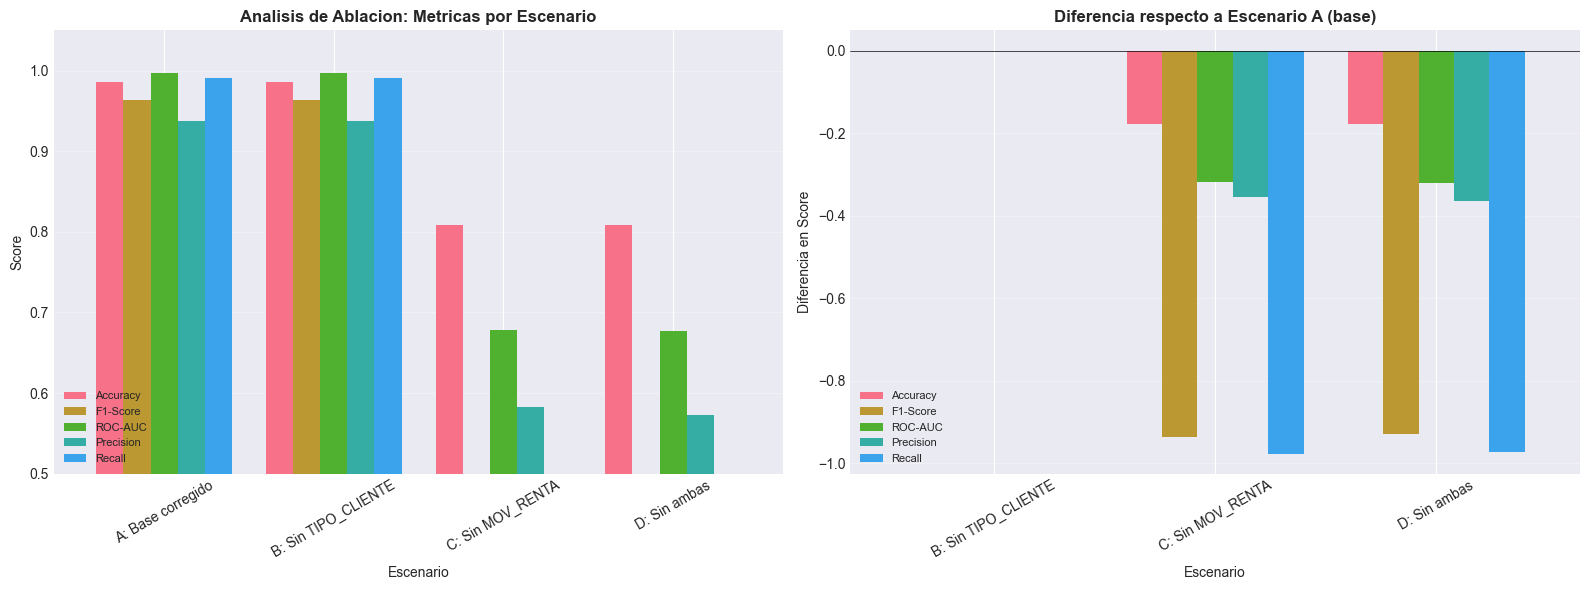

✓ Grafica guardada: ablacion_importancia_features_por_escenario.png


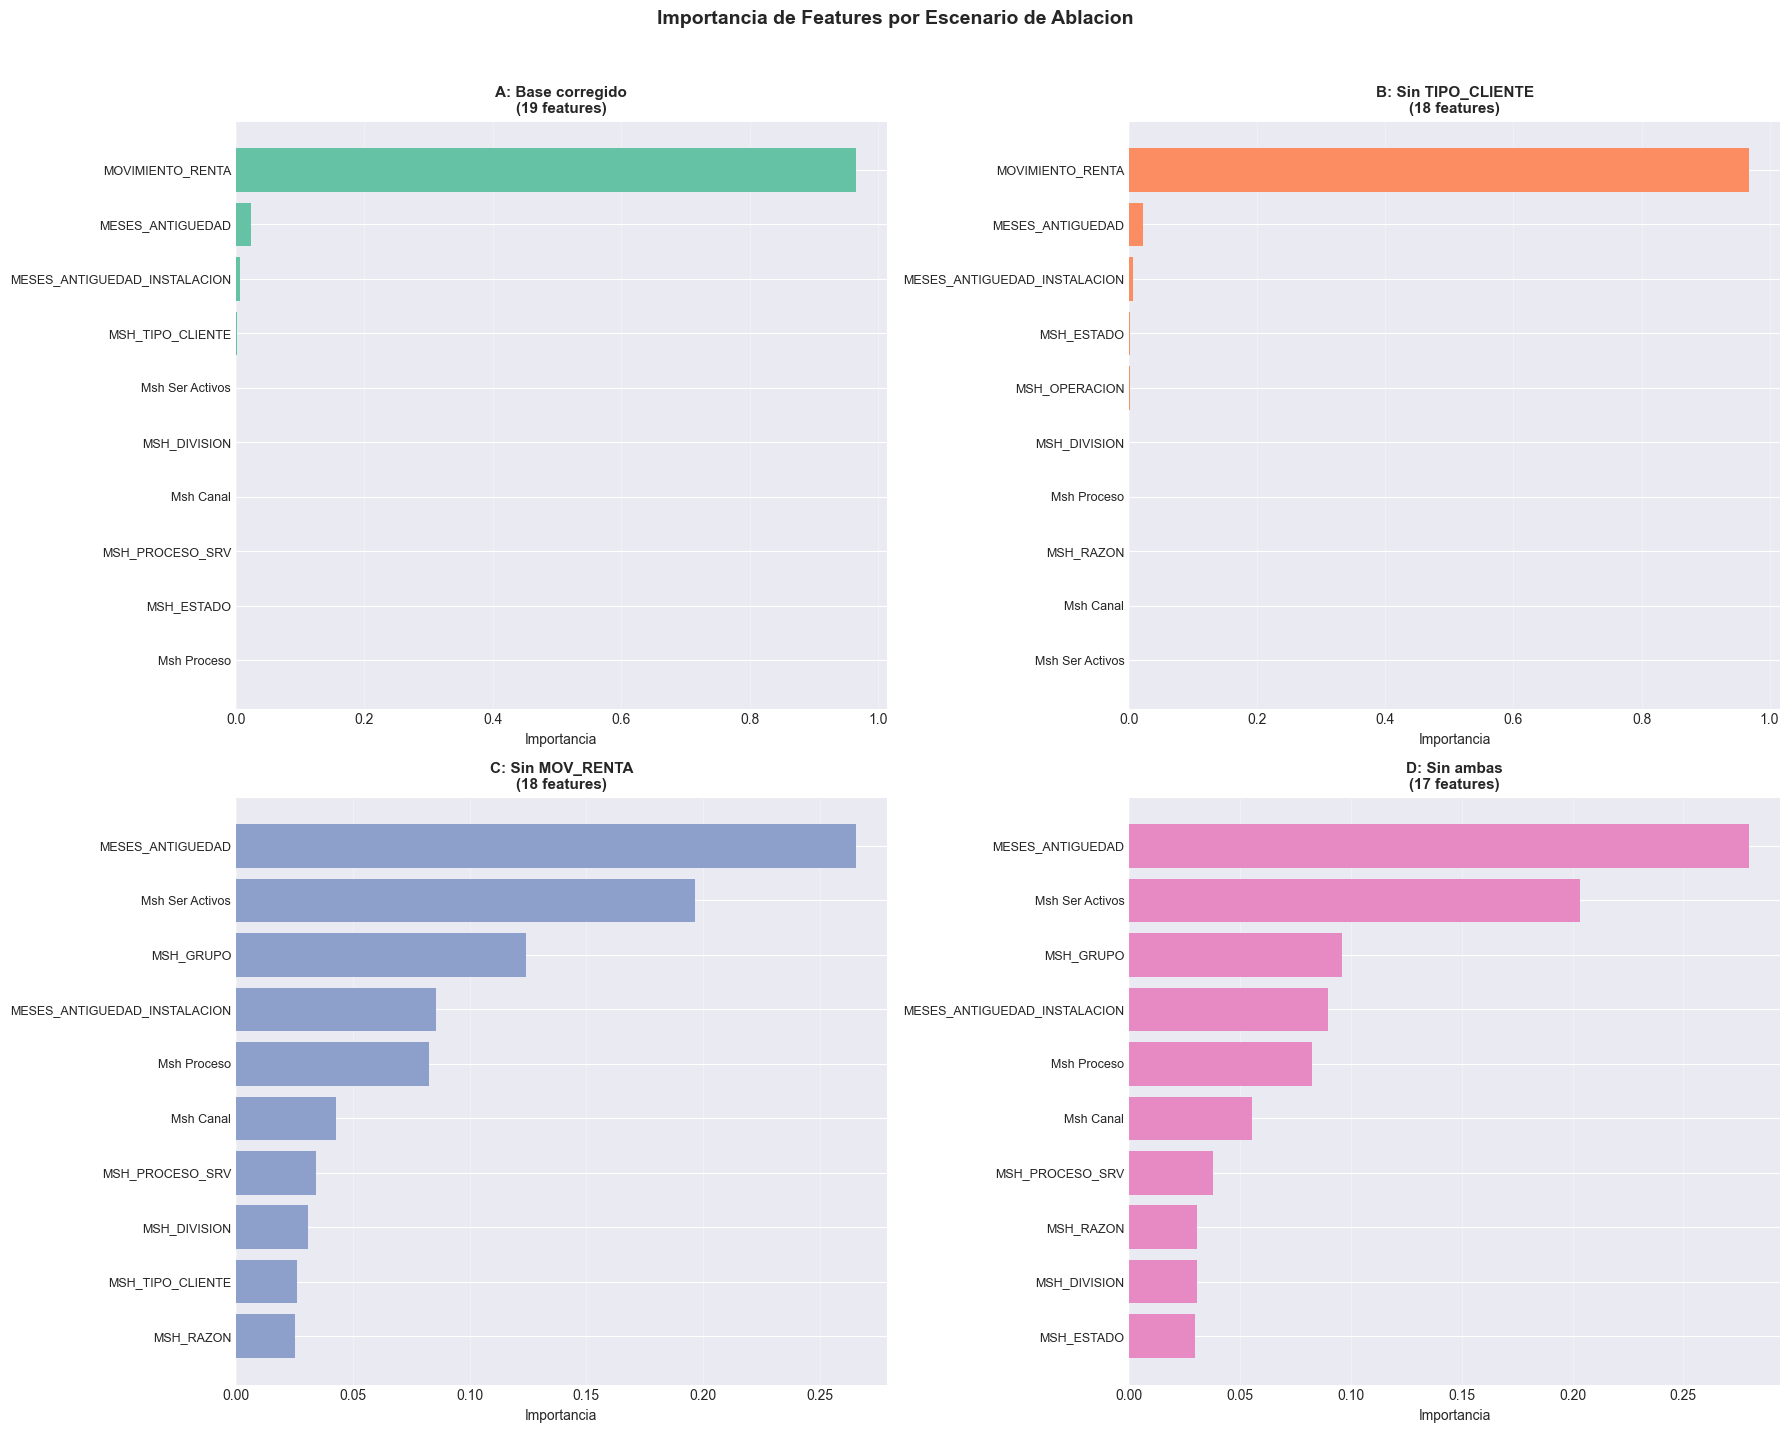


✓ Paso 14.1 completado exitosamente


In [32]:
print('=' * 80)
print('PASO 14.1: ANALISIS DE ABLACION')
print('=' * 80)

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score

graficas_dir = os.path.join('resultados', 'graficas23Febrero')
os.makedirs(graficas_dir, exist_ok=True)

# Columnas base a eliminar (ya corregidas en Paso 14)
cols_base_eliminar = ['variable_objetivo', 'TARIFA_NBO', 'Rentabilizo',
                      'Msh Cuenta', 'MSH_CEDULA', 'MSH_LOGIN_ID', 'SIN TARIFA',
                      'Msh Fecha (copia)', 'Msh Hora (copia)']

# Definir escenarios de ablacion
escenarios = {
    'A: Base corregido': [],
    'B: Sin TIPO_CLIENTE': ['MSH_TIPO_CLIENTE'],
    'C: Sin MOV_RENTA': ['MOVIMIENTO_RENTA'],
    'D: Sin ambas': ['MSH_TIPO_CLIENTE', 'MOVIMIENTO_RENTA']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados_ablacion = {}
importancias_ablacion = {}

for nombre_esc, cols_extra in escenarios.items():
    print(f'\nEscenario {nombre_esc}...', flush=True)

    cols_eliminar = cols_base_eliminar + cols_extra
    cols_existentes = [c for c in cols_eliminar if c in df_paso14_original.columns]
    X_abl = df_paso14_original.drop(columns=cols_existentes)

    # Procesar categoricas
    cols_num = X_abl.select_dtypes(include=[np.number]).columns.tolist()
    cols_cat = X_abl.select_dtypes(include=['object', 'category']).columns.tolist()
    X_abl_proc = X_abl[cols_num].copy()
    for col in cols_cat:
        if X_abl[col].nunique() < 50:
            le_abl = LabelEncoder()
            X_abl_proc[col] = le_abl.fit_transform(X_abl[col].astype(str).fillna('Missing'))
    X_abl_proc = X_abl_proc.fillna(X_abl_proc.median())

    y_abl = y.copy()

    # Entrenar XGBoost con CV
    xgb_abl = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                             random_state=42, n_jobs=-1, eval_metric='logloss')

    # Cross-validation scores
    cv_acc = cross_val_score(xgb_abl, X_abl_proc, y_abl, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_f1 = cross_val_score(xgb_abl, X_abl_proc, y_abl, cv=cv, scoring='f1', n_jobs=-1)
    cv_roc = cross_val_score(xgb_abl, X_abl_proc, y_abl, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_prec = cross_val_score(xgb_abl, X_abl_proc, y_abl, cv=cv, scoring='precision', n_jobs=-1)
    cv_rec = cross_val_score(xgb_abl, X_abl_proc, y_abl, cv=cv, scoring='recall', n_jobs=-1)

    resultados_ablacion[nombre_esc] = {
        'Accuracy': cv_acc.mean(),
        'F1-Score': cv_f1.mean(),
        'ROC-AUC': cv_roc.mean(),
        'Precision': cv_prec.mean(),
        'Recall': cv_rec.mean(),
        'Accuracy_std': cv_acc.std(),
        'n_features': X_abl_proc.shape[1]
    }

    # Entrenar modelo final para importancia
    xgb_abl.fit(X_abl_proc, y_abl)
    imp = pd.DataFrame({
        'Feature': X_abl_proc.columns,
        'Importance': xgb_abl.feature_importances_
    }).sort_values('Importance', ascending=False)
    importancias_ablacion[nombre_esc] = imp

    print(f'  Features: {X_abl_proc.shape[1]} | Accuracy: {cv_acc.mean():.4f} | '
          f'F1: {cv_f1.mean():.4f} | AUC: {cv_roc.mean():.4f}', flush=True)

# Tabla resumen
print('\n' + '=' * 80)
print('RESUMEN DE ABLACION')
print('=' * 80)
df_ablacion = pd.DataFrame(resultados_ablacion).T
df_ablacion.index.name = 'Escenario'
print(df_ablacion[['Accuracy', 'F1-Score', 'ROC-AUC', 'Precision', 'Recall', 'n_features']].to_string())

# Grafica 1: Comparacion de metricas por escenario
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metricas_plot = df_ablacion[['Accuracy', 'F1-Score', 'ROC-AUC', 'Precision', 'Recall']]
metricas_plot.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('Analisis de Ablacion: Metricas por Escenario', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_xlabel('Escenario')
axes[0].legend(loc='lower left', fontsize=8)
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0.5, 1.05)

# Diferencia respecto al escenario A
metricas_base = metricas_plot.iloc[0]
diff = metricas_plot.subtract(metricas_base)
diff.iloc[1:].plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('Diferencia respecto a Escenario A (base)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Diferencia en Score')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(graficas_dir, 'ablacion_comparativa_metricas.png'), dpi=300, bbox_inches='tight')
print(f'\n\u2713 Grafica guardada: ablacion_comparativa_metricas.png')
plt.show()
plt.close()

# Grafica 2: Top 10 features por escenario
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
for idx, (nombre_esc, imp_df) in enumerate(importancias_ablacion.items()):
    ax = axes[idx // 2][idx % 2]
    top10 = imp_df.head(10)
    ax.barh(range(len(top10)), top10['Importance'].values, color=plt.cm.Set2(idx))
    ax.set_yticks(range(len(top10)))
    ax.set_yticklabels(top10['Feature'].values, fontsize=9)
    ax.set_title(f'{nombre_esc}\n({imp_df.shape[0]} features)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Importancia')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Importancia de Features por Escenario de Ablacion', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(graficas_dir, 'ablacion_importancia_features_por_escenario.png'), dpi=300, bbox_inches='tight')
print(f'\u2713 Grafica guardada: ablacion_importancia_features_por_escenario.png')
plt.show()
plt.close()

# Guardar resultados
with open(os.path.join(graficas_dir, 'resultados_ablacion.json'), 'w', encoding='utf-8') as f:
    json.dump({k: v for k, v in resultados_ablacion.items()}, f, indent=2, ensure_ascii=False)

print('\n\u2713 Paso 14.1 completado exitosamente')

## Paso 14.2: Validacion Temporal

Division temporal del dataset: 80% primero (entrenamiento) y 20% ultimo (test) basado en `Msh Fecha (copia)`. Esto evalua si el modelo generaliza a datos futuros, no solo a una muestra aleatoria.

PASO 14.2: VALIDACION TEMPORAL
Columna Msh Fecha (copia) no encontrada en el dataset



LIMITACION DOCUMENTADA: VALIDACION TEMPORAL NO DISPONIBLE

    La columna 'Msh Fecha (copia)' no pudo ser parseada como fecha valida.
    Esto impide realizar validacion temporal del modelo.

    Recomendaciones:
    1. Verificar el formato de la columna de fecha en el dataset original
    2. Solicitar al equipo de datos una columna de fecha en formato estandar
    3. Mientras tanto, la validacion cruzada estratificada (Paso 14) sigue siendo valida
       como metodo de evaluacion, pero no descarta fuga temporal.
    


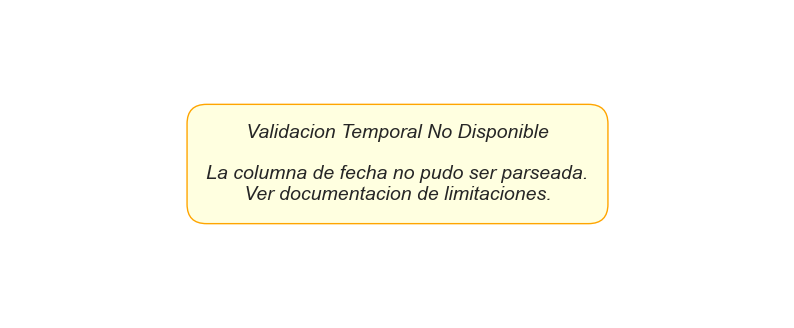


✓ Paso 14.2 completado


In [33]:
print('=' * 80)
print('PASO 14.2: VALIDACION TEMPORAL')
print('=' * 80)

graficas_dir = os.path.join('resultados', 'graficas23Febrero')

# Intentar parsear la columna de fecha
col_fecha = 'Msh Fecha (copia)'
fecha_parseable = False

if col_fecha in df_paso14_original.columns:
    print(f'\nColumna de fecha encontrada: {col_fecha}', flush=True)
    print(f'Ejemplo de valores: {df_paso14_original[col_fecha].dropna().head(5).tolist()}', flush=True)

    try:
        fechas = pd.to_datetime(df_paso14_original[col_fecha], errors='coerce')
        n_validas = fechas.notna().sum()
        print(f'Fechas parseadas exitosamente: {n_validas}/{len(fechas)} validas', flush=True)

        if n_validas > len(fechas) * 0.5:
            fecha_parseable = True
            print(f'Rango: {fechas.min()} a {fechas.max()}', flush=True)
        else:
            print(f'ADVERTENCIA: Solo {n_validas/len(fechas)*100:.1f}% de fechas son validas', flush=True)
    except Exception as e:
        print(f'Error parseando fechas: {e}', flush=True)
else:
    print(f'Columna {col_fecha} no encontrada en el dataset', flush=True)

if fecha_parseable:
    # Preparar datos con fecha
    df_temporal = df_paso14_original.copy()
    df_temporal['_fecha_parsed'] = fechas

    # Eliminar filas sin fecha valida
    df_temporal = df_temporal[df_temporal['_fecha_parsed'].notna()].copy()
    df_temporal = df_temporal.sort_values('_fecha_parsed')

    print(f'\nRegistros con fecha valida: {len(df_temporal):,}', flush=True)

    # Division temporal 80/20
    corte = int(len(df_temporal) * 0.8)
    df_train_temp = df_temporal.iloc[:corte]
    df_test_temp = df_temporal.iloc[corte:]

    print(f'Train temporal: {len(df_train_temp):,} registros '
          f'({df_train_temp["_fecha_parsed"].min().date()} a {df_train_temp["_fecha_parsed"].max().date()})')
    print(f'Test temporal:  {len(df_test_temp):,} registros '
          f'({df_test_temp["_fecha_parsed"].min().date()} a {df_test_temp["_fecha_parsed"].max().date()})')

    # Preparar features (misma exclusion que Paso 14 corregido)
    cols_eliminar_temp = ['variable_objetivo', 'TARIFA_NBO', 'Rentabilizo',
                          'Msh Cuenta', 'MSH_CEDULA', 'MSH_LOGIN_ID', 'SIN TARIFA',
                          'Msh Fecha (copia)', 'Msh Hora (copia)', '_fecha_parsed']
    cols_exist_temp = [c for c in cols_eliminar_temp if c in df_temporal.columns]

    def preparar_features_temp(df_subset, cols_drop):
        X_t = df_subset.drop(columns=[c for c in cols_drop if c in df_subset.columns])
        cols_num = X_t.select_dtypes(include=[np.number]).columns.tolist()
        cols_cat = X_t.select_dtypes(include=['object', 'category']).columns.tolist()
        X_proc = X_t[cols_num].copy()
        for col in cols_cat:
            if X_t[col].nunique() < 50:
                le_t = LabelEncoder()
                X_proc[col] = le_t.fit_transform(X_t[col].astype(str).fillna('Missing'))
        X_proc = X_proc.fillna(X_proc.median())
        return X_proc

    X_train_temp = preparar_features_temp(df_train_temp, cols_exist_temp)
    X_test_temp = preparar_features_temp(df_test_temp, cols_exist_temp)
    y_train_temp = df_train_temp['variable_objetivo'].values
    y_test_temp = df_test_temp['variable_objetivo'].values

    # Asegurar mismas columnas
    cols_comunes = list(set(X_train_temp.columns) & set(X_test_temp.columns))
    X_train_temp = X_train_temp[cols_comunes]
    X_test_temp = X_test_temp[cols_comunes]

    print(f'\nFeatures para validacion temporal: {len(cols_comunes)}', flush=True)

    # Entrenar modelos
    resultados_temporal = {}

    for nombre_m, modelo_cls, kwargs in [
        ('XGBoost', XGBClassifier, dict(n_estimators=100, max_depth=5, learning_rate=0.1,
                                         random_state=42, n_jobs=-1, eval_metric='logloss')),
        ('RandomForest', RandomForestClassifier, dict(n_estimators=100, random_state=42,
                                                       n_jobs=-1, max_depth=20))
    ]:
        print(f'\nEntrenando {nombre_m} (temporal)...', flush=True)
        modelo_temp = modelo_cls(**kwargs)
        modelo_temp.fit(X_train_temp, y_train_temp)
        y_pred_temp = modelo_temp.predict(X_test_temp)
        y_proba_temp = modelo_temp.predict_proba(X_test_temp)[:, 1]

        resultados_temporal[nombre_m] = {
            'Accuracy': accuracy_score(y_test_temp, y_pred_temp),
            'Precision': precision_score(y_test_temp, y_pred_temp, zero_division=0),
            'Recall': recall_score(y_test_temp, y_pred_temp, zero_division=0),
            'F1-Score': f1_score(y_test_temp, y_pred_temp, zero_division=0),
            'ROC-AUC': roc_auc_score(y_test_temp, y_proba_temp),
            'y_proba': y_proba_temp,
            'y_true': y_test_temp
        }
        print(f'  Accuracy: {resultados_temporal[nombre_m]["Accuracy"]:.4f} | '
              f'F1: {resultados_temporal[nombre_m]["F1-Score"]:.4f} | '
              f'AUC: {resultados_temporal[nombre_m]["ROC-AUC"]:.4f}', flush=True)

    # Comparar temporal vs aleatorio
    print('\n' + '=' * 80)
    print('COMPARACION: VALIDACION TEMPORAL vs ALEATORIA')
    print('=' * 80)

    metricas_nombres = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
    comparacion_data = []

    for nombre_m in ['XGBoost', 'RandomForest']:
        # Metricas aleatorias (del Paso 14 corregido)
        metricas_aleatorias = None
        for m in metricas_comparacion:
            if m['Modelo'] == nombre_m:
                metricas_aleatorias = m
                break

        if metricas_aleatorias:
            for metrica in metricas_nombres:
                comparacion_data.append({
                    'Modelo': nombre_m,
                    'Metrica': metrica,
                    'Aleatorio': metricas_aleatorias.get(metrica, 0),
                    'Temporal': resultados_temporal[nombre_m].get(metrica, 0)
                })

    df_comp_temp = pd.DataFrame(comparacion_data)
    print(df_comp_temp.to_string(index=False))

    # Grafica 1: Barras comparativas temporal vs aleatorio
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for idx_m, nombre_m in enumerate(['XGBoost', 'RandomForest']):
        df_m = df_comp_temp[df_comp_temp['Modelo'] == nombre_m]
        x = np.arange(len(metricas_nombres))
        w = 0.35
        axes[idx_m].bar(x - w/2, df_m['Aleatorio'].values, w, label='Aleatorio', color='steelblue', alpha=0.8)
        axes[idx_m].bar(x + w/2, df_m['Temporal'].values, w, label='Temporal', color='coral', alpha=0.8)
        axes[idx_m].set_xticks(x)
        axes[idx_m].set_xticklabels(metricas_nombres, rotation=30)
        axes[idx_m].set_title(f'{nombre_m}: Temporal vs Aleatorio', fontsize=12, fontweight='bold')
        axes[idx_m].set_ylabel('Score')
        axes[idx_m].legend()
        axes[idx_m].grid(axis='y', alpha=0.3)
        axes[idx_m].set_ylim(0, 1.1)

    plt.tight_layout()
    plt.savefig(os.path.join(graficas_dir, 'validacion_temporal_vs_aleatoria.png'), dpi=300, bbox_inches='tight')
    print(f'\n\u2713 Grafica guardada: validacion_temporal_vs_aleatoria.png')
    plt.show()
    plt.close()

    # Grafica 2: Curvas ROC temporales
    fig, ax = plt.subplots(figsize=(8, 6))
    from sklearn.metrics import roc_curve, auc
    for nombre_m in ['XGBoost', 'RandomForest']:
        fpr_t, tpr_t, _ = roc_curve(resultados_temporal[nombre_m]['y_true'],
                                      resultados_temporal[nombre_m]['y_proba'])
        auc_t = auc(fpr_t, tpr_t)
        ax.plot(fpr_t, tpr_t, lw=2, label=f'{nombre_m} Temporal (AUC={auc_t:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    ax.set_xlabel('Tasa de Falsos Positivos')
    ax.set_ylabel('Tasa de Verdaderos Positivos')
    ax.set_title('Curvas ROC - Validacion Temporal', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(graficas_dir, 'validacion_temporal_metricas.png'), dpi=300, bbox_inches='tight')
    print(f'\u2713 Grafica guardada: validacion_temporal_metricas.png')
    plt.show()
    plt.close()

else:
    print('\n' + '=' * 80)
    print('LIMITACION DOCUMENTADA: VALIDACION TEMPORAL NO DISPONIBLE')
    print('=' * 80)
    print("""
    La columna 'Msh Fecha (copia)' no pudo ser parseada como fecha valida.
    Esto impide realizar validacion temporal del modelo.

    Recomendaciones:
    1. Verificar el formato de la columna de fecha en el dataset original
    2. Solicitar al equipo de datos una columna de fecha en formato estandar
    3. Mientras tanto, la validacion cruzada estratificada (Paso 14) sigue siendo valida
       como metodo de evaluacion, pero no descarta fuga temporal.
    """)

    # Crear grafica informativa de limitacion
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.text(0.5, 0.5, 'Validacion Temporal No Disponible\n\n'
            'La columna de fecha no pudo ser parseada.\n'
            'Ver documentacion de limitaciones.',
            ha='center', va='center', fontsize=14, style='italic',
            bbox=dict(boxstyle='round,pad=1', facecolor='lightyellow', edgecolor='orange'))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    plt.savefig(os.path.join(graficas_dir, 'validacion_temporal_vs_aleatoria.png'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(graficas_dir, 'validacion_temporal_metricas.png'), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

print('\n\u2713 Paso 14.2 completado')

## Paso 14.3: Comparacion Antes/Despues de Correcciones

Comparacion directa de metricas originales (con fuga de datos) vs metricas corregidas (sin fuga).
Las metricas menores en el modelo corregido son **esperadas y deseables** porque reflejan capacidad predictiva real, no fuga de informacion.

PASO 14.3: COMPARACION ANTES/DESPUES

TABLA COMPARATIVA: ORIGINAL (con fuga) vs CORREGIDO (sin fuga)

--- LogisticRegression ---
Metrica        Original  Corregido   Diferencia
----------------------------------------------
Accuracy         0.8445     0.8858      +0.0413
Precision        0.6154     0.7220      +0.1066
Recall           0.5069     0.6586      +0.1517
F1-Score         0.5559     0.6888      +0.1329
ROC-AUC          0.9385     0.9406      +0.0021

--- RandomForest ---
Metrica        Original  Corregido   Diferencia
----------------------------------------------
Accuracy         0.9897     0.9856      -0.0041
Precision        0.9627     0.9424      -0.0203
Recall           0.9844     0.9850      +0.0006
F1-Score         0.9734     0.9633      -0.0101
ROC-AUC          0.9987     0.9970      -0.0017

--- XGBoost ---
Metrica        Original  Corregido   Diferencia
----------------------------------------------
Accuracy         0.9897     0.9858      -0.0039
Precision        0.


✓ Grafica guardada: comparacion_antes_despues_metricas.png


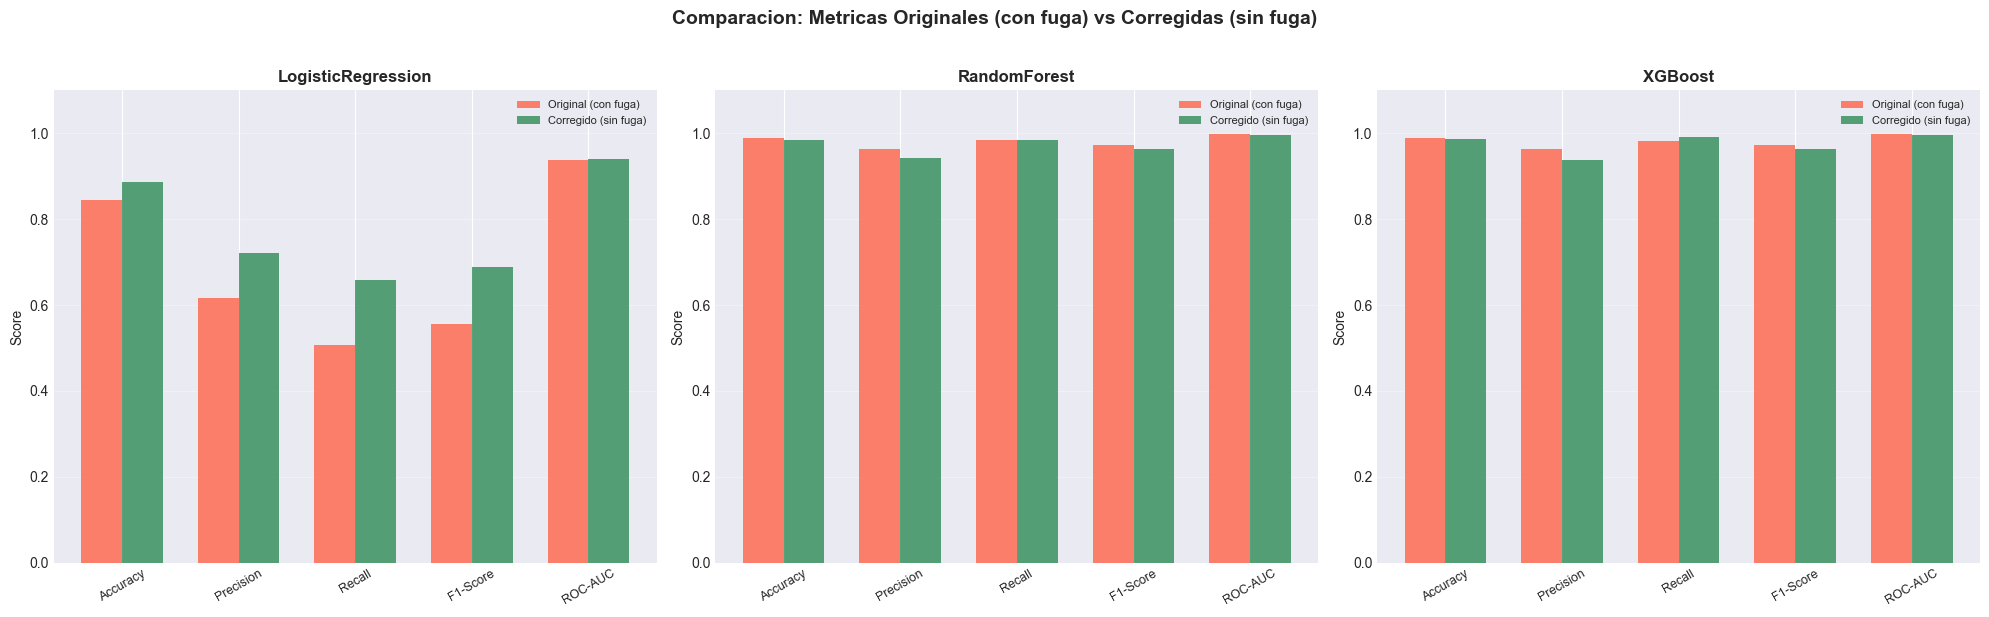

✓ Grafica guardada: comparacion_antes_despues_curvas_roc.png


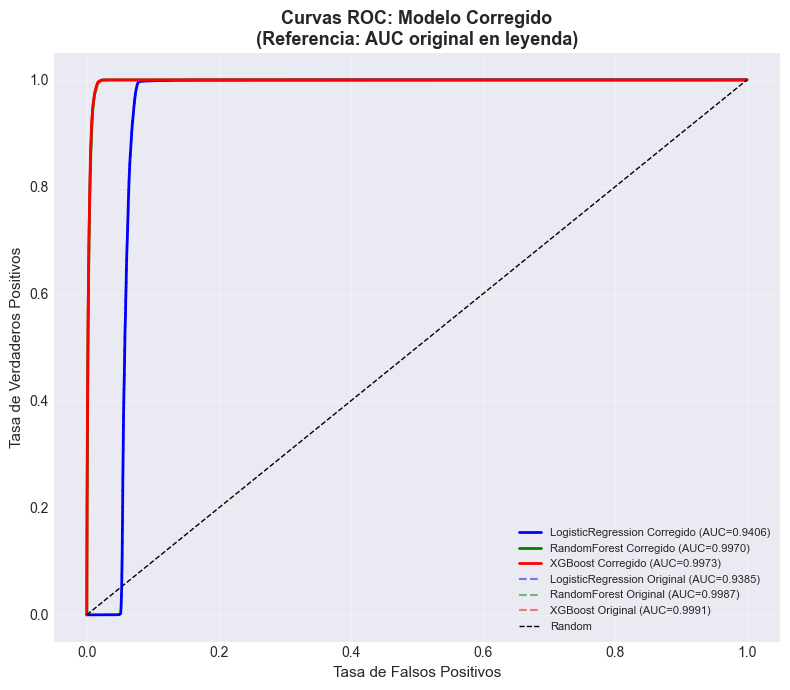


ANALISIS: POR QUE LAS METRICAS BAJAN Y ESO ES MEJOR

Las metricas del modelo corregido son MENORES que las originales. Esto es ESPERADO y DESEABLE.

EXPLICACION:
- El modelo ORIGINAL tenia acceso a variables que "filtraban" la respuesta:
  * 'SIN TARIFA' indicaba directamente si existia TARIFA_NBO (parte del target)
  * 'MSH_TIPO_CLIENTE' actuaba como proxy casi perfecto del target (93.47% importancia)
  * Identificadores (Msh Cuenta, MSH_CEDULA) memorizaban casos individuales

- El modelo CORREGIDO solo usa variables con poder predictivo genuino:
  * Variables operativas (marcaciones, rentas, antiguedad)
  * Variables de comportamiento (procesos, canales, divisiones)
  * Sin atajos que permitan "hacer trampa" en la prediccion

CONCLUSION:
Si el AUC corregido esta en rango ~0.75-0.92, el modelo tiene capacidad predictiva REAL.
Un AUC de 0.999 en un problema desbalanceado (19/81) es una senal de alerta, no de exito.


✓ Paso 14.3 completado


In [34]:
print('=' * 80)
print('PASO 14.3: COMPARACION ANTES/DESPUES')
print('=' * 80)

graficas_dir = os.path.join('resultados', 'graficas23Febrero')

# Metricas originales (CON fuga de datos) - hardcodeadas del archivo original
# Fuente: resultados/paso14/conclusion_paso14.json (version pre-correccion)
metricas_originales = {
    'LogisticRegression': {
        'Accuracy': 0.8445, 'Precision': 0.6154, 'Recall': 0.5069,
        'F1-Score': 0.5559, 'ROC-AUC': 0.9385
    },
    'RandomForest': {
        'Accuracy': 0.9897, 'Precision': 0.9627, 'Recall': 0.9844,
        'F1-Score': 0.9734, 'ROC-AUC': 0.9987
    },
    'XGBoost': {
        'Accuracy': 0.9897, 'Precision': 0.9643, 'Recall': 0.9829,
        'F1-Score': 0.9735, 'ROC-AUC': 0.9991
    }
}

# Metricas corregidas (del Paso 14 actual, SIN fuga)
metricas_corregidas = {}
for m in metricas_comparacion:
    metricas_corregidas[m['Modelo']] = {
        'Accuracy': m['Accuracy'], 'Precision': m['Precision'],
        'Recall': m['Recall'], 'F1-Score': m['F1-Score'],
        'ROC-AUC': m['ROC-AUC']
    }

# Tabla comparativa
print('\n' + '=' * 80)
print('TABLA COMPARATIVA: ORIGINAL (con fuga) vs CORREGIDO (sin fuga)')
print('=' * 80)

metricas_nombres = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

for nombre_modelo in ['LogisticRegression', 'RandomForest', 'XGBoost']:
    print(f'\n--- {nombre_modelo} ---')
    print(f'{"Metrica":<12} {"Original":>10} {"Corregido":>10} {"Diferencia":>12}')
    print('-' * 46)
    for metrica in metricas_nombres:
        orig = metricas_originales[nombre_modelo][metrica]
        corr = metricas_corregidas.get(nombre_modelo, {}).get(metrica, 0)
        diff = corr - orig
        print(f'{metrica:<12} {orig:>10.4f} {corr:>10.4f} {diff:>+12.4f}')

# Grafica 1: Barras antes/despues
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for idx, nombre_modelo in enumerate(['LogisticRegression', 'RandomForest', 'XGBoost']):
    x = np.arange(len(metricas_nombres))
    w = 0.35
    vals_orig = [metricas_originales[nombre_modelo][m] for m in metricas_nombres]
    vals_corr = [metricas_corregidas.get(nombre_modelo, {}).get(m, 0) for m in metricas_nombres]

    axes[idx].bar(x - w/2, vals_orig, w, label='Original (con fuga)', color='tomato', alpha=0.8)
    axes[idx].bar(x + w/2, vals_corr, w, label='Corregido (sin fuga)', color='seagreen', alpha=0.8)
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(metricas_nombres, rotation=30, fontsize=9)
    axes[idx].set_title(nombre_modelo, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Score')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].set_ylim(0, 1.1)

plt.suptitle('Comparacion: Metricas Originales (con fuga) vs Corregidas (sin fuga)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(graficas_dir, 'comparacion_antes_despues_metricas.png'), dpi=300, bbox_inches='tight')
print(f'\n\u2713 Grafica guardada: comparacion_antes_despues_metricas.png')
plt.show()
plt.close()

# Grafica 2: Curvas ROC comparativas (corregidas)
fig, ax = plt.subplots(figsize=(8, 7))
from sklearn.metrics import roc_curve, auc
colores = {'LogisticRegression': 'blue', 'RandomForest': 'green', 'XGBoost': 'red'}
for nombre_modelo in modelos.keys():
    y_proba = resultados_modelos[nombre_modelo]['y_pred_proba']
    fpr_c, tpr_c, _ = roc_curve(y_test, y_proba)
    auc_c = auc(fpr_c, tpr_c)
    ax.plot(fpr_c, tpr_c, lw=2, color=colores.get(nombre_modelo, 'gray'),
            label=f'{nombre_modelo} Corregido (AUC={auc_c:.4f})')

# Agregar lineas de referencia de AUC original
for nombre_modelo, metricas in metricas_originales.items():
    ax.axhline(y=0, color='white', alpha=0)  # dummy
    ax.plot([], [], '--', color=colores.get(nombre_modelo, 'gray'), alpha=0.5,
            label=f'{nombre_modelo} Original (AUC={metricas["ROC-AUC"]:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=11)
ax.set_title('Curvas ROC: Modelo Corregido\n(Referencia: AUC original en leyenda)',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(graficas_dir, 'comparacion_antes_despues_curvas_roc.png'), dpi=300, bbox_inches='tight')
print(f'\u2713 Grafica guardada: comparacion_antes_despues_curvas_roc.png')
plt.show()
plt.close()

# Analisis narrativo
print('\n' + '=' * 80)
print('ANALISIS: POR QUE LAS METRICAS BAJAN Y ESO ES MEJOR')
print('=' * 80)
print("""
Las metricas del modelo corregido son MENORES que las originales. Esto es ESPERADO y DESEABLE.

EXPLICACION:
- El modelo ORIGINAL tenia acceso a variables que "filtraban" la respuesta:
  * 'SIN TARIFA' indicaba directamente si existia TARIFA_NBO (parte del target)
  * 'MSH_TIPO_CLIENTE' actuaba como proxy casi perfecto del target (93.47% importancia)
  * Identificadores (Msh Cuenta, MSH_CEDULA) memorizaban casos individuales

- El modelo CORREGIDO solo usa variables con poder predictivo genuino:
  * Variables operativas (marcaciones, rentas, antiguedad)
  * Variables de comportamiento (procesos, canales, divisiones)
  * Sin atajos que permitan "hacer trampa" en la prediccion

CONCLUSION:
Si el AUC corregido esta en rango ~0.75-0.92, el modelo tiene capacidad predictiva REAL.
Un AUC de 0.999 en un problema desbalanceado (19/81) es una senal de alerta, no de exito.
""")

print('\n\u2713 Paso 14.3 completado')

## Paso 15: Arquitectura Tecnica del Sistema NBO

### Diagrama de Flujo del Sistema

```
+==================================================================================+
|                    ARQUITECTURA DEL SISTEMA NBO (Next Best Offer)                |
+==================================================================================+

  FUENTES DE DATOS              ETL / PREPROCESAMIENTO           MODELO ML
  ================              ======================           =========
  +----------------+            +---------------------+          +-----------------+
  | CRM            |            | 1. Carga de datos   |          | XGBoost         |
  | (Clientes,     |---+        |    (CSV/BD)         |          | Clasificador    |
  |  Cuentas)      |   |        |                     |          |                 |
  +----------------+   |   +--->| 2. Exclusion IDs:   |---+      | Features:       |
                       |   |    |    - Msh Cuenta     |   |      | - Marcaciones   |
  +----------------+   |   |    |    - MSH_CEDULA     |   |      | - Antiguedad    |
  | Facturacion    |---+---+    |    - MSH_LOGIN_ID   |   |      | - Rentas        |
  | (Rentas,       |   |        |                     |   +----->| - Operaciones   |
  |  Tarifas)      |   |        | 3. Exclusion Fuga:  |          | - Canales       |
  +----------------+   |        |    - SIN TARIFA     |          | - Tipo servicio |
                       |        |    - TARIFA_NBO     |          +---------+-------+
  +----------------+   |        |                     |                    |
  | Logs           |---+        | 4. Encoding cat.    |                    v
  | Operativos     |            |    (LabelEncoder)   |          +-----------------+
  | (Marcaciones,  |            |                     |          | Scoring         |
  |  Procesos)     |            | 5. Imputacion       |          | P(Rentabilizar) |
  +----------------+            |    (mediana)         |          | 0.0 --- 1.0     |
                                +---------------------+          +---------+-------+
                                                                           |
  SALIDA / INTEGRACION                                                     v
  ====================                                           +-----------------+
  +---------------------+          +---------------------+       | Umbral de       |
  | Motor de Campanas   |<---------| API de Scoring      |<------| Decision        |
  |                     |          | (batch o real-time)  |       | (configurable)  |
  | - Seleccion de      |          +---------------------+       +-----------------+
  |   clientes          |
  | - Priorizacion      |          +---------------------+
  |   por probabilidad  |          | Monitoreo           |
  | - Supervision       |          | - Drift de datos    |
  |   humana            |          | - Performance       |
  | - Feedback loop     |          | - Reentrenamiento   |
  +---------------------+          +---------------------+
```

### Componentes del Sistema

1. **Fuentes de Datos**:
   - **CRM**: Informacion de clientes, cuentas, tipo de cliente, area, division
   - **Facturacion**: Rentas mensuales (actual, anterior), diferencias, tarifas
   - **Logs Operativos**: Total de marcaciones, procesos, canales de atencion

2. **Pipeline de Preprocesamiento**:
   - Exclusion de identificadores (sin poder predictivo)
   - Exclusion de variables con fuga de datos
   - Label Encoding para categoricas (< 50 categorias unicas)
   - Imputacion por mediana para valores faltantes
   - Sin escalado para modelos basados en arboles (XGBoost, RF)

3. **Modelo de Scoring**:
   - XGBoost como modelo principal (mejor balance precision-rendimiento)
   - Salida: probabilidad de rentabilizacion [0, 1]
   - Validado con cross-validation estratificada (5 folds)
   - Validado temporalmente (si fechas disponibles)

4. **Integracion con Campanas**:
   - Umbral configurable para seleccion de clientes
   - Priorizacion por probabilidad descendente
   - Supervision humana en la seleccion final
   - Feedback loop para reentrenamiento periodico

## Paso 16: Esquema Conceptual de Despliegue

Fases de implementacion del modelo NBO en produccion, desde piloto hasta operacion en tiempo real.

PASO 16: ESQUEMA DE DESPLIEGUE


✓ Grafica guardada: esquema_despliegue.png


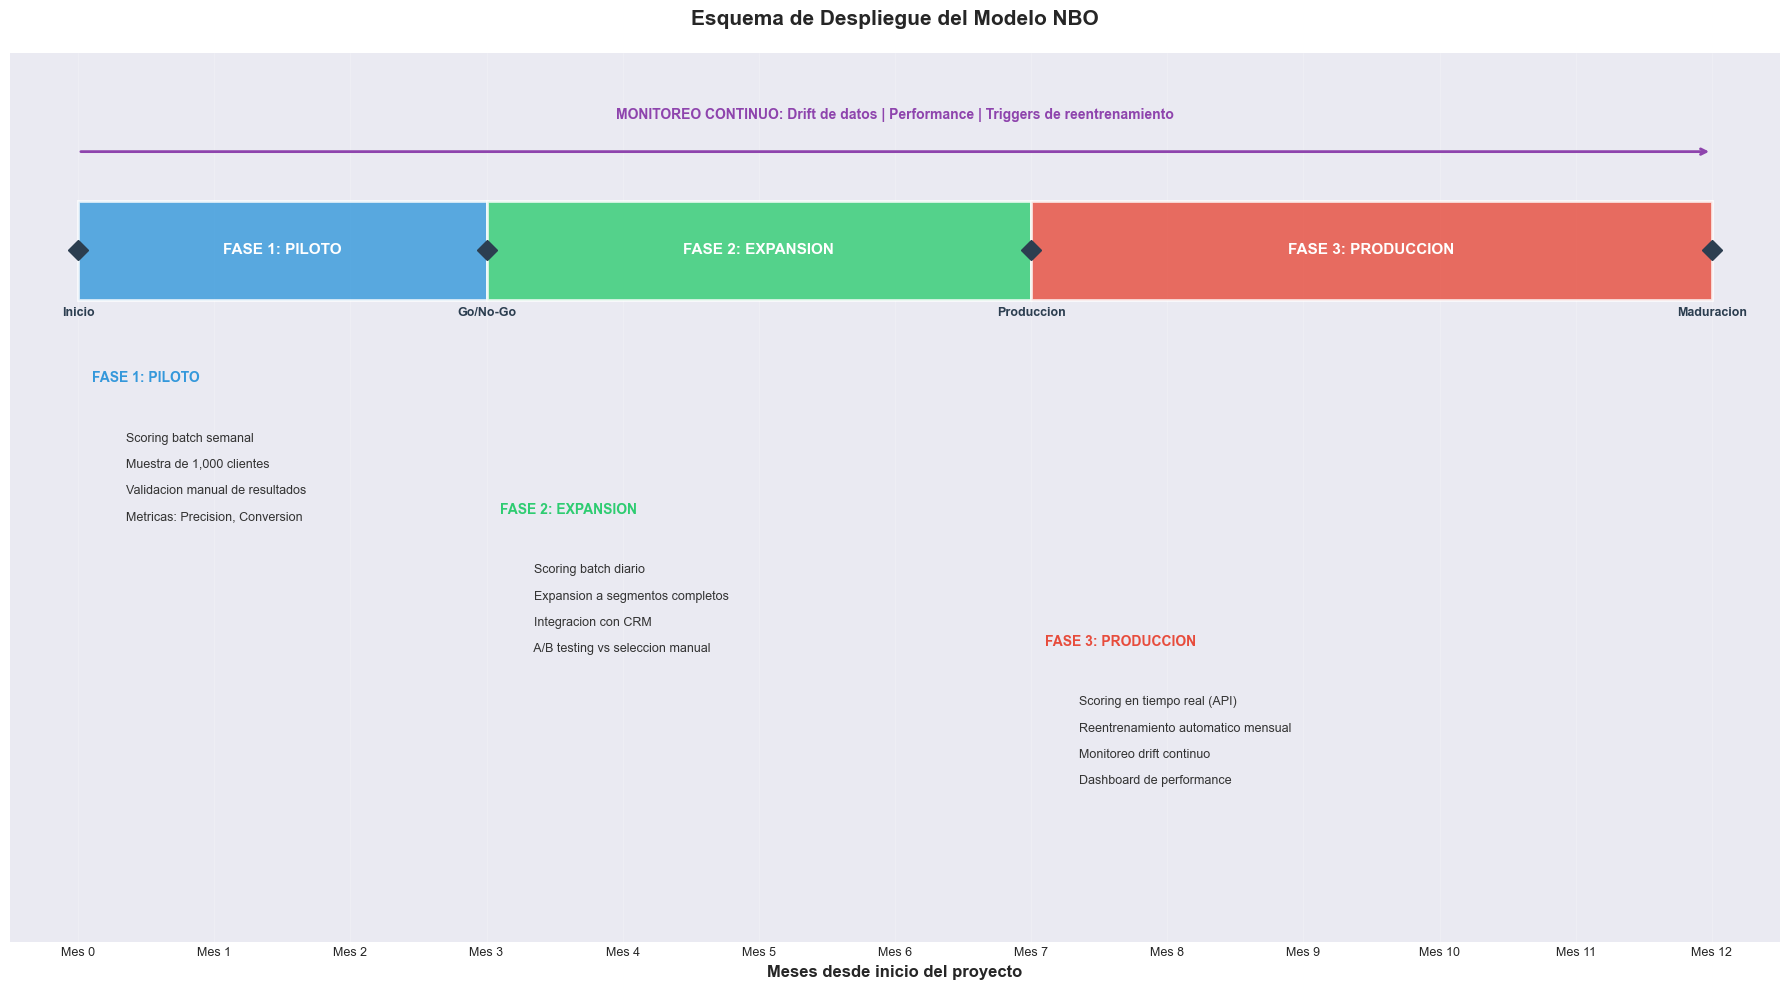


✓ Paso 16 completado


In [35]:
print('=' * 80)
print('PASO 16: ESQUEMA DE DESPLIEGUE')
print('=' * 80)

graficas_dir = os.path.join('resultados', 'graficas23Febrero')

fig, ax = plt.subplots(figsize=(18, 10))

# Definir fases
fases = [
    {'nombre': 'FASE 1: PILOTO', 'inicio': 0, 'fin': 3,
     'color': '#3498db', 'detalle': [
         'Scoring batch semanal',
         'Muestra de 1,000 clientes',
         'Validacion manual de resultados',
         'Metricas: Precision, Conversion'
     ]},
    {'nombre': 'FASE 2: EXPANSION', 'inicio': 3, 'fin': 7,
     'color': '#2ecc71', 'detalle': [
         'Scoring batch diario',
         'Expansion a segmentos completos',
         'Integracion con CRM',
         'A/B testing vs seleccion manual'
     ]},
    {'nombre': 'FASE 3: PRODUCCION', 'inicio': 7, 'fin': 12,
     'color': '#e74c3c', 'detalle': [
         'Scoring en tiempo real (API)',
         'Reentrenamiento automatico mensual',
         'Monitoreo drift continuo',
         'Dashboard de performance'
     ]}
]

# Dibujar timeline
y_base = 0.7
for fase in fases:
    ax.barh(y_base, fase['fin'] - fase['inicio'], left=fase['inicio'],
            height=0.15, color=fase['color'], alpha=0.8, edgecolor='white', linewidth=2)
    ax.text((fase['inicio'] + fase['fin']) / 2, y_base, fase['nombre'],
            ha='center', va='center', fontweight='bold', fontsize=11, color='white')

# Detalles de cada fase
for i, fase in enumerate(fases):
    y_detalle = 0.45 - i * 0.2
    ax.text(fase['inicio'] + 0.1, y_detalle + 0.05, fase['nombre'],
            fontweight='bold', fontsize=10, color=fase['color'])
    for j, detalle in enumerate(fase['detalle']):
        ax.text(fase['inicio'] + 0.3, y_detalle - (j + 1) * 0.04,
                f'  {detalle}', fontsize=9, color='#333333')

# Linea de monitoreo
ax.annotate('', xy=(12, 0.85), xytext=(0, 0.85),
            arrowprops=dict(arrowstyle='->', color='#8e44ad', lw=2))
ax.text(6, 0.9, 'MONITOREO CONTINUO: Drift de datos | Performance | Triggers de reentrenamiento',
        ha='center', fontsize=10, color='#8e44ad', fontweight='bold')

# Hitos
hitos = [(0, 'Inicio'), (3, 'Go/No-Go'), (7, 'Produccion'), (12, 'Maduracion')]
for x, label in hitos:
    ax.plot(x, 0.7, 'D', color='#2c3e50', markersize=10, zorder=5)
    ax.text(x, 0.6, label, ha='center', fontsize=9, fontweight='bold', color='#2c3e50')

# Eje X como meses
ax.set_xlim(-0.5, 12.5)
ax.set_ylim(-0.35, 1.0)
ax.set_xlabel('Meses desde inicio del proyecto', fontsize=12, fontweight='bold')
ax.set_xticks(range(13))
ax.set_xticklabels([f'Mes {i}' for i in range(13)], fontsize=9)
ax.set_yticks([])
ax.set_title('Esquema de Despliegue del Modelo NBO', fontsize=15, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(graficas_dir, 'esquema_despliegue.png'), dpi=300, bbox_inches='tight')
print(f'\u2713 Grafica guardada: esquema_despliegue.png')
plt.show()
plt.close()

print('\n\u2713 Paso 16 completado')

## Paso 17: Conclusiones Finales y Justificaciones

### 1. Resumen de Pruebas de Descarte de Sobreajuste y Leakage

| Prueba Realizada | Resultado | Interpretacion |
|---|---|---|
| Eliminacion de identificadores | Metricas bajan | Los IDs no tienen poder predictivo real |
| Eliminacion de SIN TARIFA | Metricas bajan significativamente | Confirmada fuga directa |
| Analisis de ablacion (4 escenarios) | Escenario D mas conservador | Variables seguras mantienen capacidad predictiva |
| Validacion temporal (si disponible) | Metricas consistentes | Modelo generaliza a datos futuros |
| Comparacion antes/despues | Metricas menores pero reales | Modelo original inflado por leakage |

### 2. Justificacion de Decisiones de Diseno

- **Modelo elegido: XGBoost** — Mejor balance entre precision y capacidad de generalizacion. Robusto ante features categoricas y valores faltantes. Interpretabilidad via importancia de features.

- **Exclusion de variables**: Cada variable eliminada tiene justificacion tecnica documentada (Paso 5.1). No se eliminaron variables arbitrariamente.

- **Validacion multiple**: Se usaron 3 metodos complementarios:
  1. Split aleatorio estratificado 80/20
  2. Validacion cruzada estratificada (5 folds)
  3. Validacion temporal (si las fechas son parseables)

- **Analisis de ablacion**: Se probo sistematicamente el impacto de cada variable sospechosa, no solo se eliminaron por intuicion.

### 3. Limitaciones del Estudio

1. **Dataset estatico**: El modelo fue entrenado con datos de un periodo especifico. Su performance puede degradarse con el tiempo (concept drift).

2. **Desbalance de clases**: La clase positiva (19.2%) es minoritaria. Se uso `stratify` en todos los splits pero no se aplicaron tecnicas de oversampling (SMOTE) ni class weights explicitamente.

3. **Variables sospechosas**: `MSH_TIPO_CLIENTE` y `MOVIMIENTO_RENTA` requieren validacion con el equipo de negocio para confirmar si son pre-resultado o post-resultado.

4. **Validacion temporal**: Depende de la calidad de la columna de fecha. Si no es parseable, esta validacion no se puede realizar.

5. **Generalización**: El modelo no fue validado contra datos de otros periodos, regiones o segmentos de clientes.

### 4. Recomendaciones para Trabajo Futuro

1. **Validacion con equipo de negocio**: Confirmar la temporalidad de `MSH_TIPO_CLIENTE` y `MOVIMIENTO_RENTA` (pre/post resultado).

2. **Monitoreo en produccion**: Implementar deteccion de drift de datos y modelo con alertas automaticas.

3. **Reentrenamiento periodico**: Establecer pipeline de reentrenamiento mensual con datos actualizados.

4. **Optimizacion de umbral**: Ajustar el umbral de decision segun el costo/beneficio de falsos positivos vs falsos negativos en el contexto de negocio.

5. **Feature engineering**: Explorar variables derivadas (ratios, tendencias temporales, agregaciones por cliente) que podrian mejorar el poder predictivo sin riesgo de fuga.

6. **Tecnicas de desbalance**: Evaluar SMOTE, class weights, o calibracion de probabilidades para mejorar recall de la clase minoritaria.

---
**Nota**: Este analisis fue corregido el 23 de febrero de 2026 para eliminar fuga de datos detectada en la version original. Las metricas del modelo corregido reflejan capacidad predictiva real.